Notes for me: find charge in total detector per event. Then find number of photons per event.
Curve fit it (hopefully Gaussian)
Try to find angle of muon. Enters through top

# Event display for WbLS data
The Water-based Liquid Scintillator (WbLS) 1-ton detector is a R&D demonstrator for future neutrino or dark matter detectors currently operating at BNL. The WbLS recently developed enables separation between Cherenkov and scintillation signals, thus providing both directional reconstruction and enhanced low-energy efficiency.

![](https://drive.google.com/uc?export=view&id=11Ihqq1x2I5Yk2FFArB6ocmp9_9QyeDni)

This notebook will allow you to access the cosmics data you collected with the WbLS detector and display your events. Since the starting point are raw DAQ files, you will need to import some pre-existing Python modules to unpack them.



## Step 1: Setting up the environment
As always, we start by loading some Python packages that will be useful along the way.
Google Colab provides several pre-installed libraries that can be directly imported. Additional packages can be installed using `!pip install`.

In [2]:
# these packages are already available in Colab
# so we can import them directly
import os
import sys
import re
import glob
import statistics
import pandas as pd
import types
import numpy as np
from numpy import array, isscalar, uint16, uint32
from numpy import sqrt
from datetime import datetime
from scipy.stats import norm
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
import setuptools

# these packages require to be installed
!pip install iminuit
from iminuit import Minuit
!pip install uproot
import uproot
!pip install numba
!pip install lmfit
from lmfit import Model

print("uproot version:", uproot.__version__)


[notice] A new release of pip is available: 23.1.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.1.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.1.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.1.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
uproot version: 5.6.2


In [3]:

MODULES_PATH = ".."
print(os.listdir('..'))
# fill out the path to your collected data file in your Google Drive
# e.g.: /content/drive/MyDrive/RENEW_DATA-Week_1/sample_data_WbLS/phase2_wbls_1pct_muon_mid_x64_19mV_alpha_2023_0625_0.root
FILE_PATH = "EDIT_Event_Display/phase2_wbls_2pct_muon_mid_x64_19mV_alpha_230701T1014_0.root"

['.config', 'Music', '.zprofile.pysave', '.docker', '.openshot_qt', 'TeX_Notes', '.anyconnect', 'tools', '.dart', '.DS_Store', '.CFUserTextEncoding', '.xonshrc', '.zprofile.bak', 'adv_basics', '.zshrc', '.local', 'iQuHACK2025', 'Pictures', '.qutip', '.zprofile', 'Foxit', '.dartServer', '.pub-cache', '.zsh_history', '.ipython', 'Desktop', 'Library', '.vpn', '.matplotlib', '.lesshst', '.emulator_console_auth_token', 'Software', 'myloveydoveys', '.android', '.cocoapods', '.cups', 'PycharmProjects', 'Public', 'FavWords', '.idlerc', '.tcshrc', '.flutter', '.cisco', 'www.cern.ch', '.git-credentials', '.anaconda', 'AllRoot', '.dart-tool', '.ssh', 'Movies', 'Applications', '.gradle', '.rubies', '.Trash', '.ipynb_checkpoints', '.jupyter', 'Documents', '.vscode', '.root_hist', 'HACKTX2024', '.bash_profile', '.gem', '.swiftpm', 'WebScraping', 'electron', '.Xauthority', 'Downloads', '.python_history', '.cache', '.gitconfig', '.viminfo', '.zsh_sessions', 'git', '.conda', 'home.cern', 'src']


The following cell uses the paths you provided to setup the pre-written Python modules, so that they can be referenced inside the notebook.
These pre-existing modules come from the [DROP](https://github.com/BNLIF/drop) reconstruction software, developed by those directly working on this R&D system at BNL.

In [7]:
# setting environment variables
SRC_DIR = MODULES_PATH+"/src"
YAML_DIR = MODULES_PATH+"/yaml"
LIB_DIR = MODULES_PATH+"/lib"
TOOL_DIR = MODULES_PATH+"/tools"
os.environ['LIB_DIR'] = LIB_DIR
os.environ['YAML_DIR'] = YAML_DIR
os.environ['SRC_DIR'] = SRC_DIR
os.environ['TOOL_DIR'] = TOOL_DIR
sys.path.append(SRC_DIR)

# setting up some additional path to calibration and configuration files
CALIB_FILE = MODULES_PATH+"/calib/bnl1t_spe_fit_results_230420T1832.csv"
CONFIG_PATH = MODULES_PATH+"/config_guang.yaml"

# building a libraries of utilities
os.system(MODULES_PATH+"/src/make_numba_lib.py")
# os.system("/Users/bigd/PycharmProjects/EDIT_Event_Display/modules/src/utilities.py")
# os.chdir("/Users/bigd/PycharmProjects/EDIT_Event_Display/modules/src")

# import functions from these python modules
print(os.listdir())
#os.chdir('modules/src')
from utilities import generate_colormap
# print(os.listdir(LIB_DIR))
# "/Users/bigd/PycharmProjects/EDIT_Event_Display/modules/lib"
from run_drop import RunDROP
from waveform import Waveform
from yaml_reader import YamlReader
from pulse_finder import PulseFinder
from yaml_reader import SAMPLE_TO_NS

['classExamples', '.DS_Store', 'Gradient Descent', 'roothw1', 'suli2025_venv_2', 'CS326E', 'CS303E', 'LocalPyRoot', 'NucNet', 'QC_python_notebooks', 'E2_Project', 'CS313E', 'mywebsite', 'NucNet_data', 'roothw2', 'Electrodynamics_and_Relativity', 'EDIT_Event_Display', 'poop.txt', 'EDIT_Event_Display.ipynb']


sh: ../src/make_numba_lib.py: No such file or directory


ModuleNotFoundError: No module named 'utilities'

## Step 2: Extracting data
The following cells contain functions to read-out data from the file. These function are organized in a *class*, called `WaveformExtractor`, which extracts both metadata and channel by channel information.

In particular, for every PMT readout channel, two quantities are extracted by analyzing the waveform:
*   The total collected charge in photoelectrons (`pe`), via `get_wfm_data()`.
*   The amplitude of the pulse in `mV`, via `get_wfm_data_mV()`.
Both are measures of the total amount of light collected by a PMT.





In [ ]:
# extract datatime from a str. The datetime must follow the fixed format: YYmmddTHHMM
# this is necessary to read the metadata included in the file
def extract_datetime_from_str(s):

    match = re.search('\d{6}T\d{4}', s)
    if match:
        try:
            dt = datetime.strptime(match.group(), '%y%m%dT%H%M')
            return dt
        except ValueError:
            print('Fail finding the datetime string from path: %s' % s)

Let's now define the class that allows to quickly read out a file:

In [ ]:
# this is the class that allows to read a file.
# it stores several parameters related to the detector configuration
# as well as running the function that extracts the data.

# Inputs:
#      raw_data_path (str): path to the raw root file
#      yaml_path (str): path to the configuration yaml file

class WaveformExtractor():
    def __init__(self, raw_data_path, yaml_path='yaml/config.yaml'):

        self.cfg = YamlReader(yaml_path) # load yaml config
        self.if_path = raw_data_path # get the file path

        # load metadata and calibration file
        # --> the are interal class functions (see below)
        self.load_run_info()
        self.load_pmt_info()

        # get daq tree via uproot
        f = uproot.open(raw_data_path)

        # get data from daq tree
        self.n_entries = f['daq'].num_entries
        print(self.n_entries)

        # set configurations for waveform analysis
        self.wfm = Waveform(self.cfg)
        self.wfm.ch_names=self.ch_names # channel names
        self.wfm.ch_id = self.ch_id # channel ids
        self.wfm.n_boards = self.n_boards # number of boards
        self.wfm.spe_mean = self.spe_mean # single photoelectron response

        self.daq = f['daq'].arrays()
        self.entry_id = 0

    # ---------------
    # this function reads run info metadata
    # finds out datetime and which channels were on.
    def load_run_info(self):

        f = uproot.open(self.if_path)
        dt = extract_datetime_from_str(self.if_path)
        a = f['run_info'].arrays(['n_boards', 'active_ch_id', 'n_event_proc'], library='np')
        self.n_boards = uint16(a['n_boards'][0])
        self.n_event_proc = uint32(a['n_event_proc'][0])
        tmp = a['active_ch_id'][0]
        if isscalar(tmp): # if only 1 active channels, tmp is a scalar and sort will fail
            tmp = [tmp]
        self.ch_id = sorted(uint16(tmp))
        self.ch_names = ["adc_b%d_ch%d" % (i // 100, i % 100) for i in self.ch_id]
        self.ch_name_to_id_dict = dict(zip(self.ch_names, self.ch_id))

    # ---------------
    # the next two functions load up the correct calibration parameters
    # calibration is needed to be able to determine the number of photoelectrons
    # we calibrate the single photoelectron (spe) response of each PMT
    def load_pmt_info(self):

        self.spe_mean = {}
        fpath = CALIB_FILE # read the calibration file
        self._set_spe_result(fpath)

    def _set_spe_result(self, fpath):
        try:
            df = pd.read_csv(fpath)
            df.set_index('ch_name', inplace=True)
            self.spe_fit_results  = df # to be saved in root
            ch_names = df.index
            for ch in ch_names:
                self.spe_mean[ch] = float(df['spe_mean'][ch]) # gain
        except:
            sys.exit("your spe_fit_results_file cannot be loaded properly!")

    # ---------------
    # This function actually process one entry (event) of the file, given its index
    # it is called in a loop over the entire entries bt the following function
    def process_one(self, i):

        self.event_id = self.daq[i].event_id
        self.event_ttt = self.daq[i].event_ttt
        self.wfm.reset()
        self.wfm.set_raw_data(self.daq[i])
        self.wfm.find_saturation()
        self.wfm.subtract_flat_baseline()
        self.wfm.do_spe_normalization()
        self.wfm.define_trigger_position()
        self.wfm.correct_daisy_chain_trg_delay()
        self.wfm.sum_channels()
        self.wfm.define_time_axis()
        self.wfm.integrate_waveform()
        self.wfm.calc_roi_info()
        self.wfm.calc_aux_ch_info()

    def process_next(self):

        if self.entry_id<self.n_entries:
            i = self.entry_id
            self.process_one(i)
            self.entry_id+=1
            return True
        else:
            return False

    # ---------------
    # These last few functions are actually extracting data that we will be using
    # for the event display, in particular the total charge of the pulse (in pe)
    # this can be done for a specific input time interval and channel

    # ch_name: channel names identical to how it's defined in DROP.
    #    Options: sum_bot, sum_side, sum_row1,..., sum_row4, ..., sum_col1,..., sum_col4.
    #    Individual channels are accessible too. For example, adc_b1_ch3 is board 1 channel 3.
    def get_wfm_data(self, t_min=370, t_max=470, ch_name='sum_bot'):

        t = self.wfm.time_axis_ns
        mask = (t>=t_min) & (t<t_max)
        x_data=t[mask]
        y_data=self.wfm.amp_pe[ch_name][mask]
        return x_data, y_data

    def get_wfm_data_mv(self, t_min=370, t_max=470, ch_name='sum_bot'):

        t = self.wfm.time_axis_ns
        x_data=t
        y_data=self.wfm.amp_mV[ch_name]

        return x_data, y_data

    def get_aux_ch_mV(self, ch_name='adc_b1_ch0'):
        return self.wfm.aux_ch_area_mV[ch_name]

## Step 3: Preparing the display
Let's the prepare a function that displays data.

First, we define the `(x,y,z)` position of all PMTs in the detector. There are PMTs on the bottom and PMTs on the side (barrell) of the detector.

In [ ]:
# bottom PMTs
locx_bot = [381, 381, 381, 381,
            190.5, 190.5, 190.5, 190.5, 190.5, 190.5, 190.5,
            0, 0, 0, 0, 0, 0, 0, 0,
           -190.5, -190.5, -190.5, -190.5, -190.5, -190.5, -190.5,
           -381, -381, -381, -381]
locy_bot = [-171.45, -57.15, 57.15, 171.45,
           -342.9, -228.6, -114.3, 0, 114.3, 228.6, 342.9,
           -400.05, -285.75, -171.45, -57.15,57.15, 171.45, 285.75, 400.05,
           -342.9, -228.6, -114.3, 0, 114.3, 228.6, 342.9,
           -171.45, -57.15, 57.15, 171.45]

# barrell PMTs
locx_side= [-532.955, -532.955,-532.955,-532.955,
               532.955,532.955,532.955,532.955,
               0,0,0,0,0,0,0,0,]
locy_side= [0,0,0,0,0,0,0,0,
               -532.955, -532.955,-532.955,-532.955,
               532.955,532.955,532.955,532.955]
locz_side= [-495.3, -336.55, 222.25, 393.7,
               -495.3, -336.55, 222.25, 393.7,
               -495.3, -336.55, 222.25, 393.7,
               -495.3, -336.55, 222.25, 393.7]

We can now make a function that displays the PMTs, with a circle that is proportional to the amount of charge they collected.
We can assume to have an array, `chg`, that contains the total charge for each PMT channel id, and use it as input.

Since PMTs are either on the bottom or on the barrell, we can make two 2D plots for each case.

In [ ]:
def display_charge(chg):
    dis_x=[]
    dis_y=[]
    area=[]
    area2=[]

    # setup two plots
    plt.rcParams['figure.figsize'] = [15, 8]
    fig, (ax1, ax2) = plt.subplots(1, 2)

    # for each PMT, make the area proportional to the charge
    # if it's a barrell PMT, use an angle instead of x,y
    for i in range(len(chg)):
        if i < 30:
            area.append(chg[i]*150)
        elif i < 46:
            if i>29 and i<34:
                dis_x.append(0)
            if i>33 and i<38:
                dis_x.append(180)
            if i>37 and i<42:
                dis_x.append(90)
            if i>41 and i<46:
                dis_x.append(270)
            dis_y.append(locz_side[i-30])
            area2.append(chg[i-30]*150)

    # plot the PMTs (just their positions)
    ax1.scatter(locx_bot, locy_bot, c='black', s=50, alpha=0.3)
    ax2.scatter(dis_x, dis_y, c='black', s=50, alpha=0.3)

    # plots the PMTs (heatmaps)
    ax1.scatter(locx_bot, locy_bot, s=area, c=area, alpha=1, label="Bottom plane",cmap='YlOrRd')
    ax2.scatter(dis_x, dis_y, s=area2, c=area2, alpha=1, label="Barrel plane",cmap='YlOrRd')

    # add labels and legends
    ax1.set_xlabel("X (mm)")
    ax1.set_ylabel("Y (mm)")
    ax2.set_xlabel("$\phi$ (deg.) with R = 533 mm")
    ax2.set_ylabel("Z (mm)")
    ax1.legend(loc='upper right',fontsize=12)
    ax2.legend(loc='center right',fontsize=12)
    ax1.grid()
    ax2.grid()
    plt.show()

On top of 2D plots, we can also attemp to get a full 3D event display. Apart from placing the PMTs, we can also try to add a cylinder to represent the detector volume.

In [ ]:
# define a cylinder by its center, radius and height
# this function extracts points on the cylinder surface
def cylinder_along_z(center_x,center_y,radius,height_z):
    z = np.linspace(-height_z/2., height_z/2., 50)
    theta = np.linspace(0, 2*np.pi, 50)
    theta_grid, z_grid=np.meshgrid(theta, z)
    x_grid = radius*np.cos(theta_grid) + center_x
    y_grid = radius*np.sin(theta_grid) + center_y
    return x_grid,y_grid,z_grid

In [ ]:
def display_3d(chg):

    area=[]
    area2=[]

    # setup two plots
    fig = plt.figure(figsize=(15, 8))
    ax = fig.add_subplot(projection='3d')

    # for each PMT, make the area proportional to the charge
    for i in range(len(chg)):
      if i < 30:
        area.append(chg[i]*150)
      elif i < 46:
        area2.append(chg[i-30]*150)

    # plot the PMTs (just their positions)
    ax.scatter(locx_bot, locy_bot, -600., c='black', s=50, alpha=0.2)
    ax.scatter(locx_side, locy_side, locz_side, c='black', s=50, alpha=0.4)

    # plot the PMTs (heatmaps)
    ax.scatter(locx_bot, locy_bot, -600., c=area, s=area,cmap='YlOrRd')
    ax.scatter(locx_side, locy_side, locz_side, c=area2, s=area2, cmap='YlOrRd')

    xc,yc,zc = cylinder_along_z(0.,0.,533.,1100)
    ax.plot_surface(xc, yc, zc, alpha=0.2)

    # add labels and legends
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")

    fig.tight_layout()

## Step 4: Processing and plotting
Now all the ingredients are ready and it is possible to process the input file using the class `WaveformExtractor` and feed its output to the plotting function.
We can package this processing into another class (`processor`), which makes it easier to access multiple events or files.

We will need to specify which channels we want to read out, so we begin by creating a string containing *all* channel names.

In [ ]:
# channel names depend on the readout board (b1 to b4)
# each DAQ board hosts 16 channels max
ch_string = ""
for i in range(15):
    ch_string += "adc_b1_ch{} ".format(i+1)
for i in range(15):
    ch_string += "adc_b2_ch{} ".format(i)
for i in range(16):
    ch_string += "adc_b3_ch{} ".format(i)
for i in range(12):
    ch_string += "adc_b4_ch{} ".format(i)

We define a class to process and plot events. Events are sequential entries in the file, so it is possible to process many of them sequentially. The main function `process_data` has three arguments:
* the first entry (event) to be process;
* the number of entries (events) to process;
* an optional flag to plot raw waveforms.

So for example, setting the first entry to `2` and the number of entries to `10` will process event numbers `2`, ..., `11`.

In [ ]:
# defining a class to process events
class processor():
    def __init__(self):

        # use WaveformExtractor to read out the file
        self.wf = WaveformExtractor(FILE_PATH, CONFIG_PATH)
        print("processor ready")

    # this is the main function of the class
    # it takes three inputs as describe before
    def process_data(self, sevt, nevts, show=False):
        tmin = 220
        tmax = 320
        tt = []
        tt_mv1 = []

        # look at entries from sevt to nevts-1
        for ii in range(sevt,sevt+nevts):
          # process the entry
          self.wf.process_one(ii)
          event_id=self.wf.event_id
          event_ttt=self.wf.event_ttt

          evt_chg=[] # prepare to save the charge data
          chn_count = 0

          # get the data between t_min and t_max
          # looping through all channels defined before
          for ich in ch_string.split():
            if chn_count>45:
              break
            if "adc" in ich:
              chn_count += 1
              # use WaveformExtractor function to get charge
              x_data, y_data = self.wf.get_wfm_data(t_min=0, t_max=2000, ch_name='{}'.format(ich))
            else:
              print ("can't do this channel")

            yy_data = y_data.tolist()
            aa = yy_data.index(np.max(yy_data))

            tmin = x_data[aa] - 20
            tmax = x_data[aa] + 40

            if np.max(y_data) > -1e9:
              if "adc" in ich:
                x_data_mv, y_data_mv = self.wf.get_wfm_data(t_min=tmin, t_max=tmax, ch_name='{}'.format(ich))
              else:
                print ("can't do this channel")
              summ_mv = 0
              for idata in range(len(y_data_mv)):
                summ_mv += y_data_mv[idata]*2
              evt_chg.append(summ_mv)
              if show and chn_count<10:
                plt.subplot(3,3,chn_count)
                plt.plot(x_data_mv, y_data_mv, color='k', label='channel %s'%ich)
              if show:
                plt.legend()

          # evalute if it is crossing all the way
          if (self.wf.get_aux_ch_mV(ch_name='adc_b1_ch0') + self.wf.get_aux_ch_mV(ch_name='adc_b2_ch15')>300 ):
            print ("this is a crossing muon.")
          else:
            print ("this is not a crossing muon.")

# IMPORTANT
          display_charge(evt_chg)
          display_3d(evt_chg)
          chargesAsPhotons = [evt_chg[n]/gains[n] for n in range(len(evt_chg))]
          self.chargesAsPhotons.append(sum(evt_chg))

Initialize the processor:

In [ ]:
pr = processor()

9898
processor ready


You can now plot the events by choosing the entries you want to display:

this is not a crossing muon.


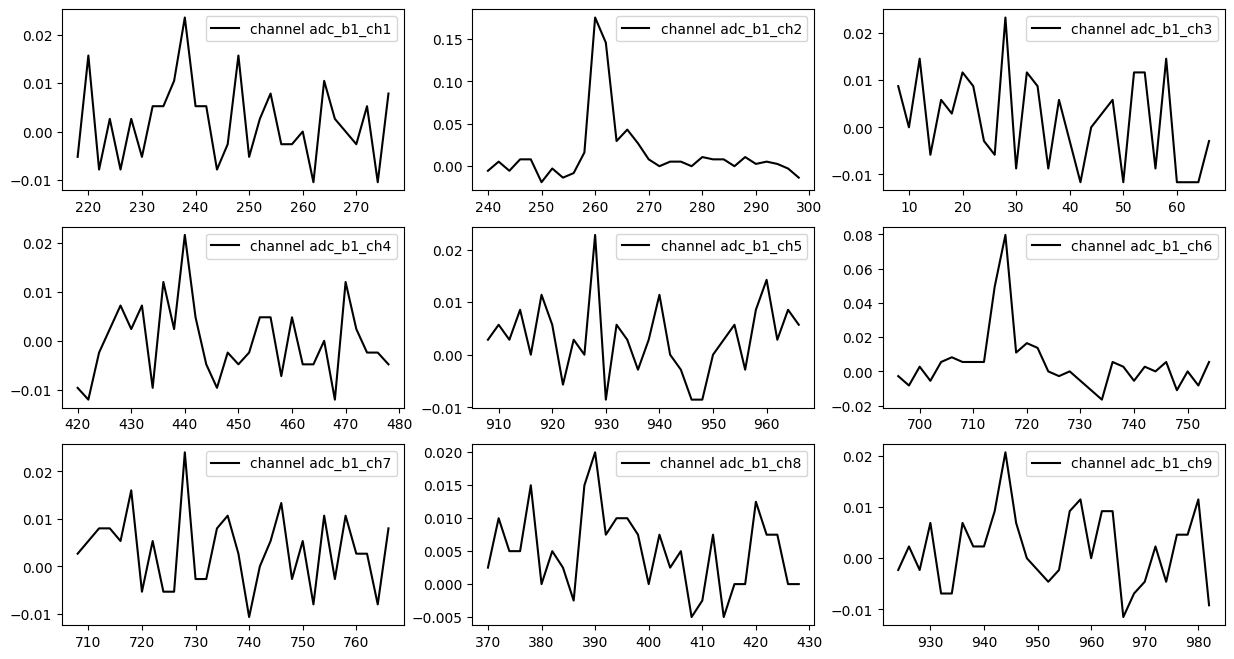

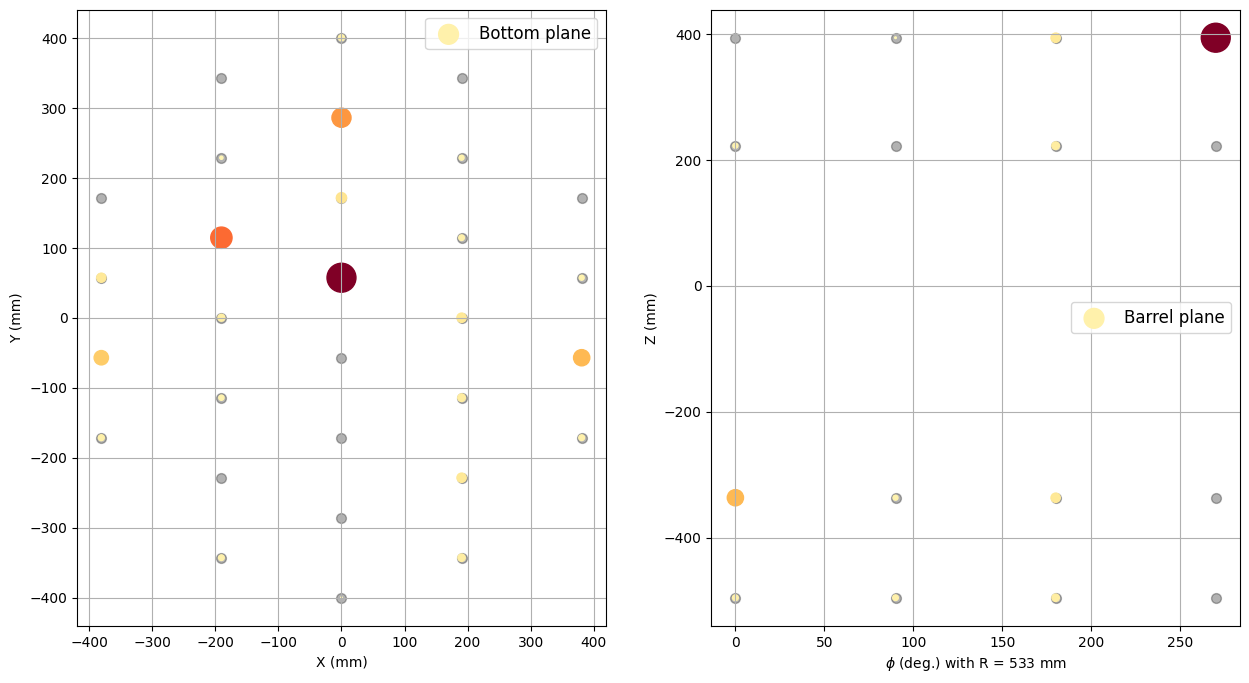

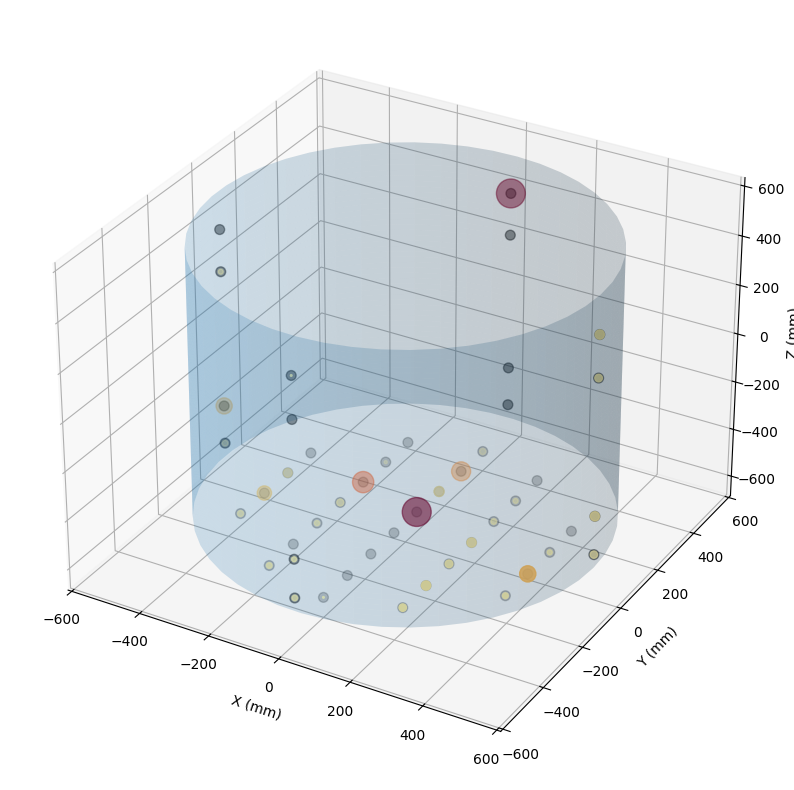

In [ ]:
start_entry = 0
n_entries = 1
show_wf=True

# arguments: first entry, number of events, show waveform
result = pr.process_data(start_entry, n_entries, show_wf)

Try to go through some of the events you collected. Do you notice anything interesting? Do you see any Cherenkov rings? Do you see a muon crossing the entire detector?

[15549 15544 15545 ... 15550 15545 15550]
adc_b1_ch1 0.33034923459117554


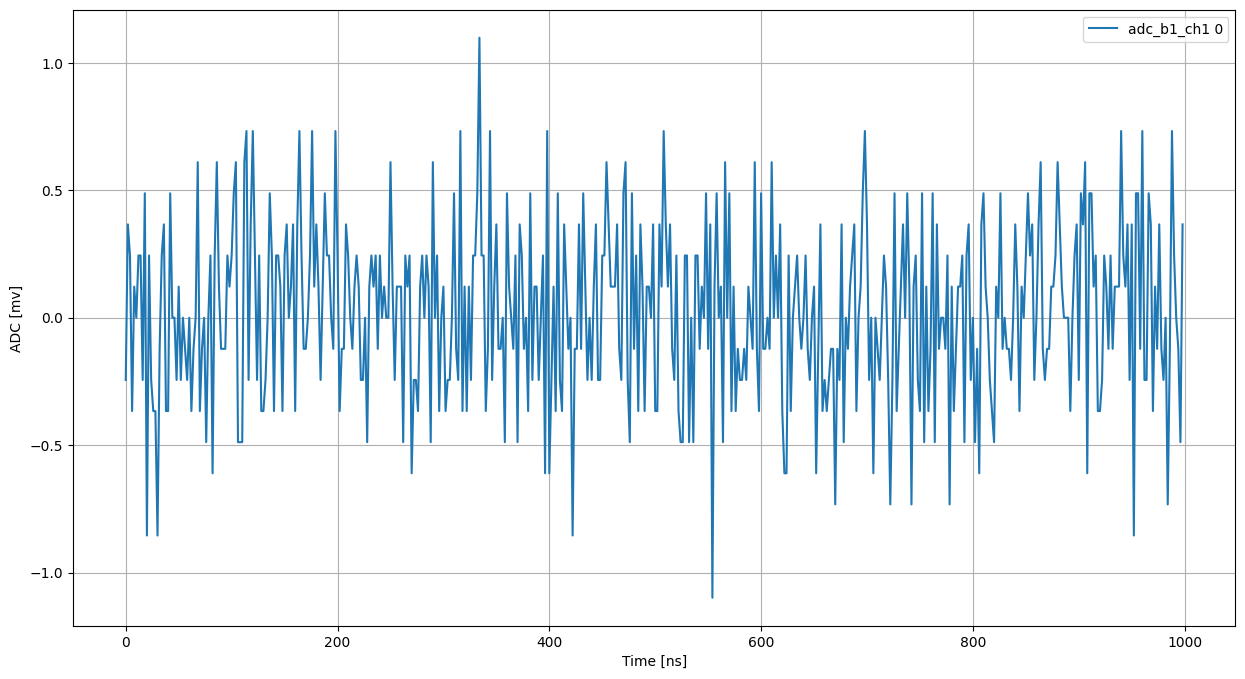

[15542 15545 15547 ... 15548 15547 15544]
adc_b1_ch1 0.3231330835313475


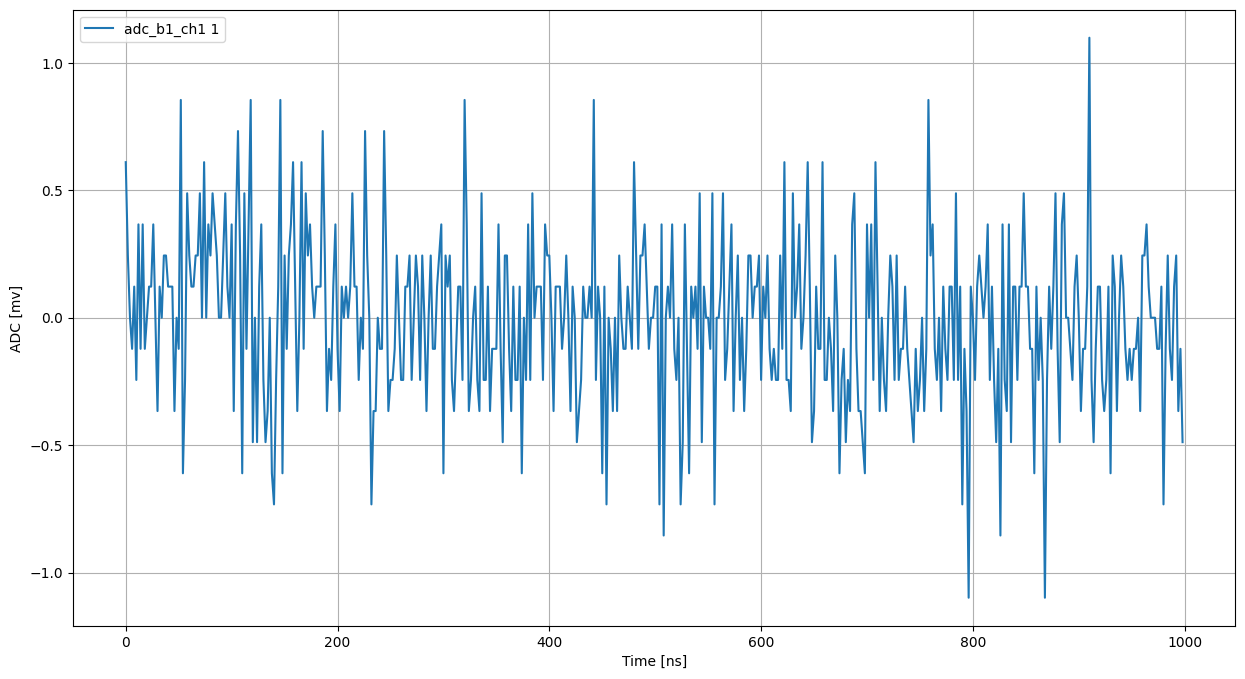

[15544 15546 15545 ... 15547 15546 15549]
adc_b1_ch1 0.3180466414877981


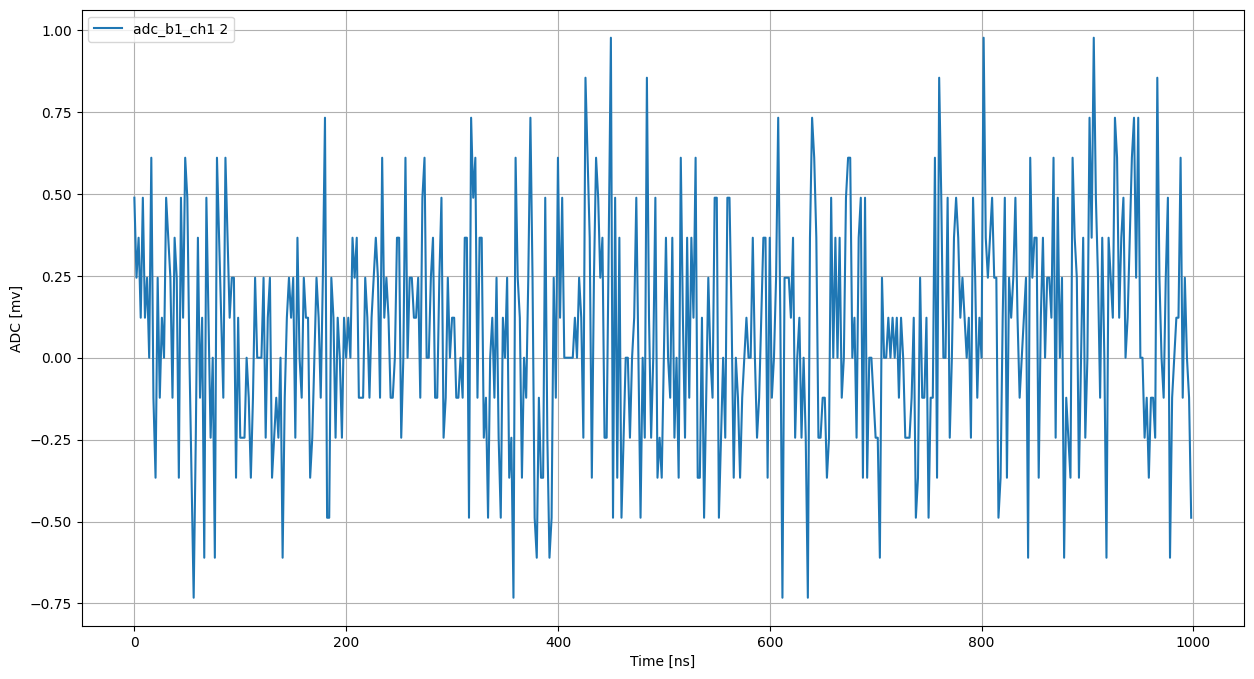

[15551 15544 15551 ... 15548 15546 15546]
adc_b1_ch1 0.32676046688075544


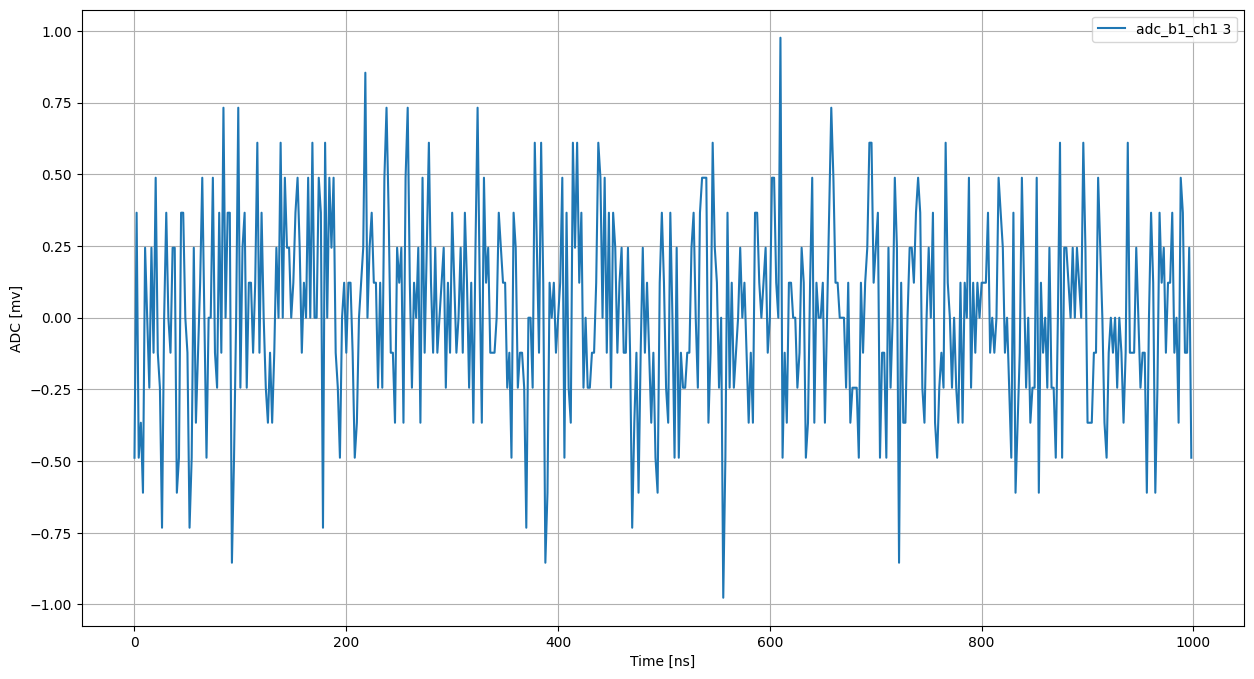

[15548 15546 15549 ... 15551 15548 15550]
adc_b1_ch1 0.7084903695187919


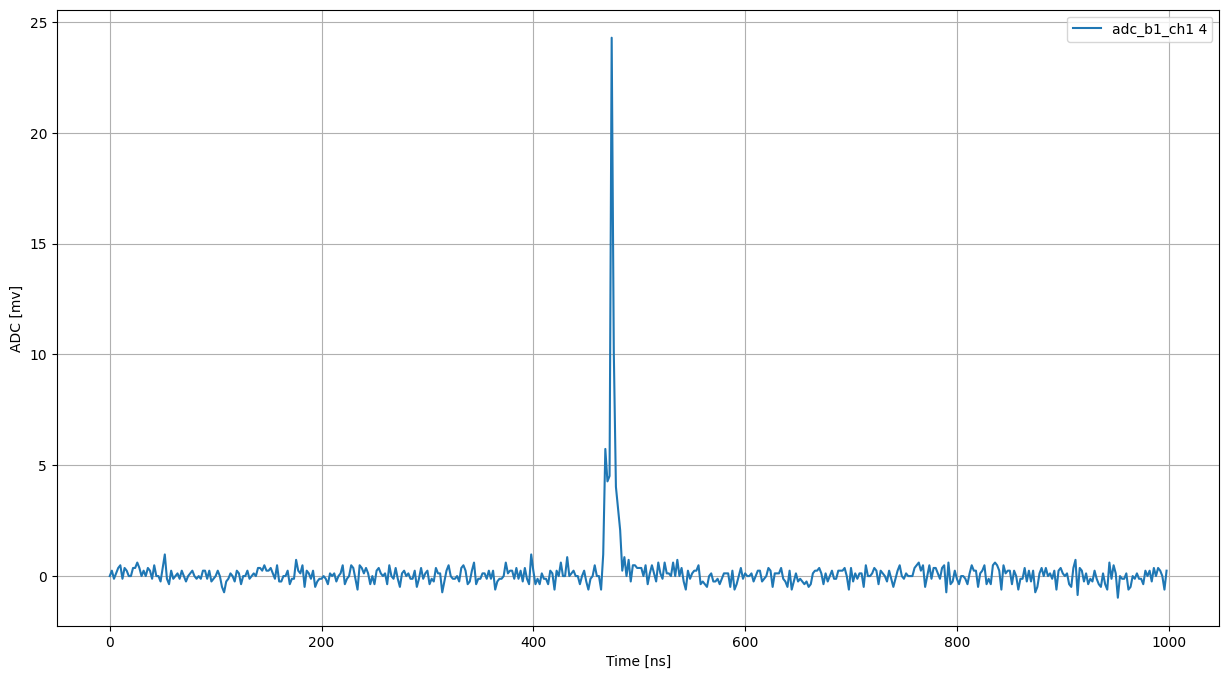

[15548 15546 15545 ... 15546 15546 15545]
adc_b1_ch1 0.3316967632196917


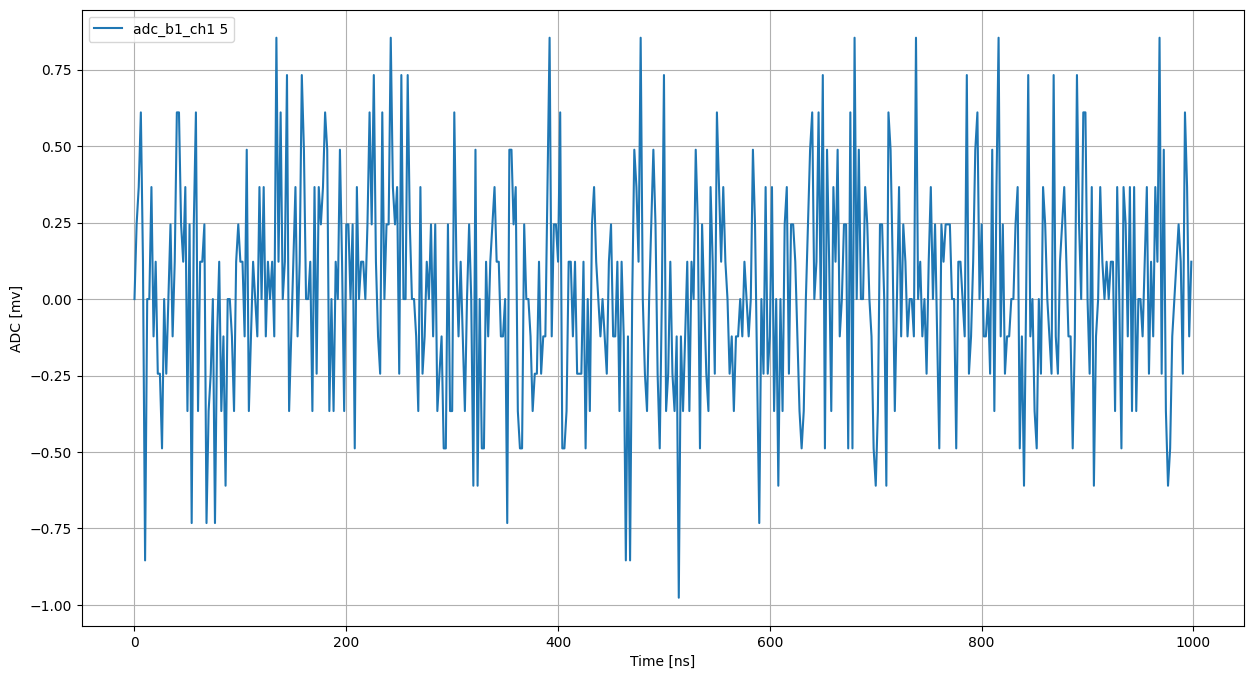

[15544 15542 15543 ... 15550 15540 15544]
adc_b1_ch1 0.3274357748713764


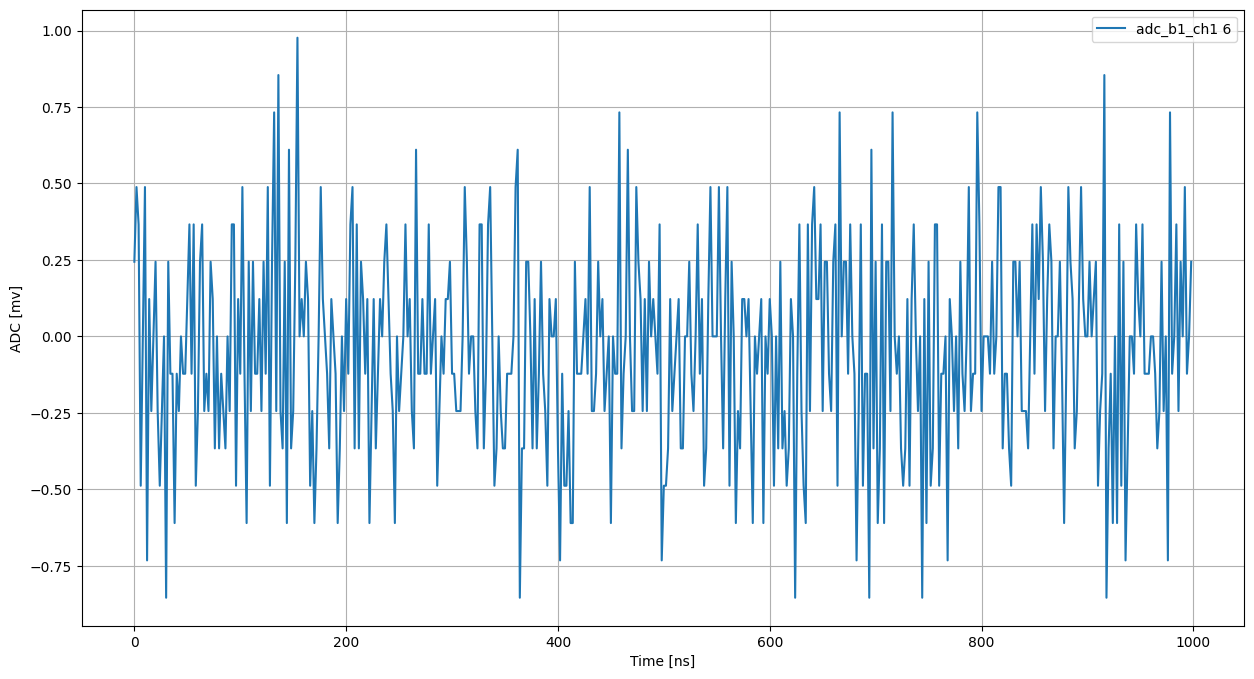

[15551 15546 15540 ... 15548 15546 15545]
adc_b1_ch1 0.6112818682119224


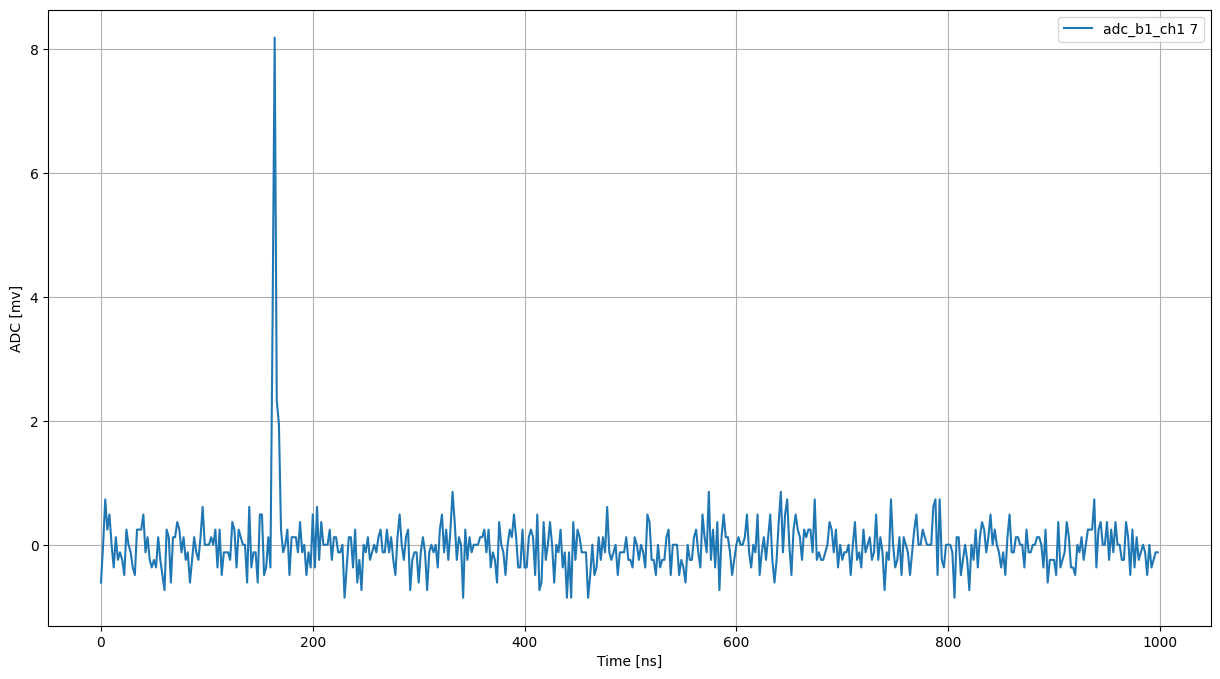

[15544 15551 15549 ... 15546 15551 15550]
adc_b1_ch1 0.32531934566122456


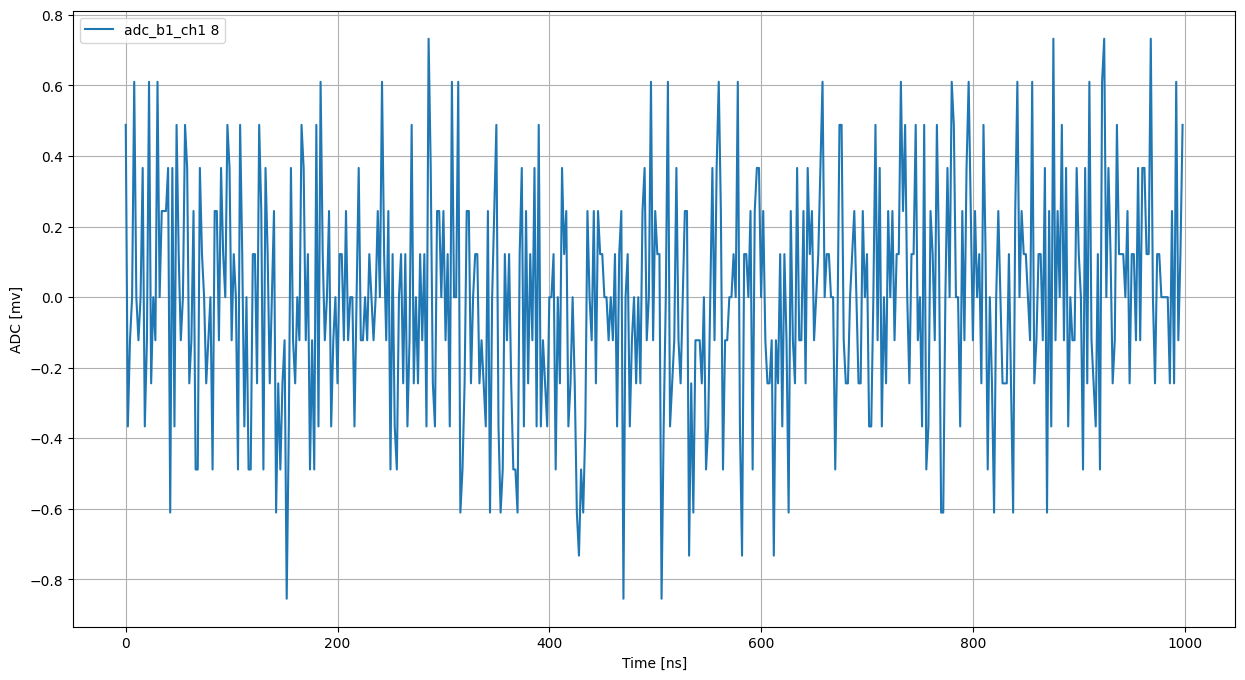

[15549 15545 15542 ... 15545 15546 15545]
adc_b1_ch1 0.34230983120964376


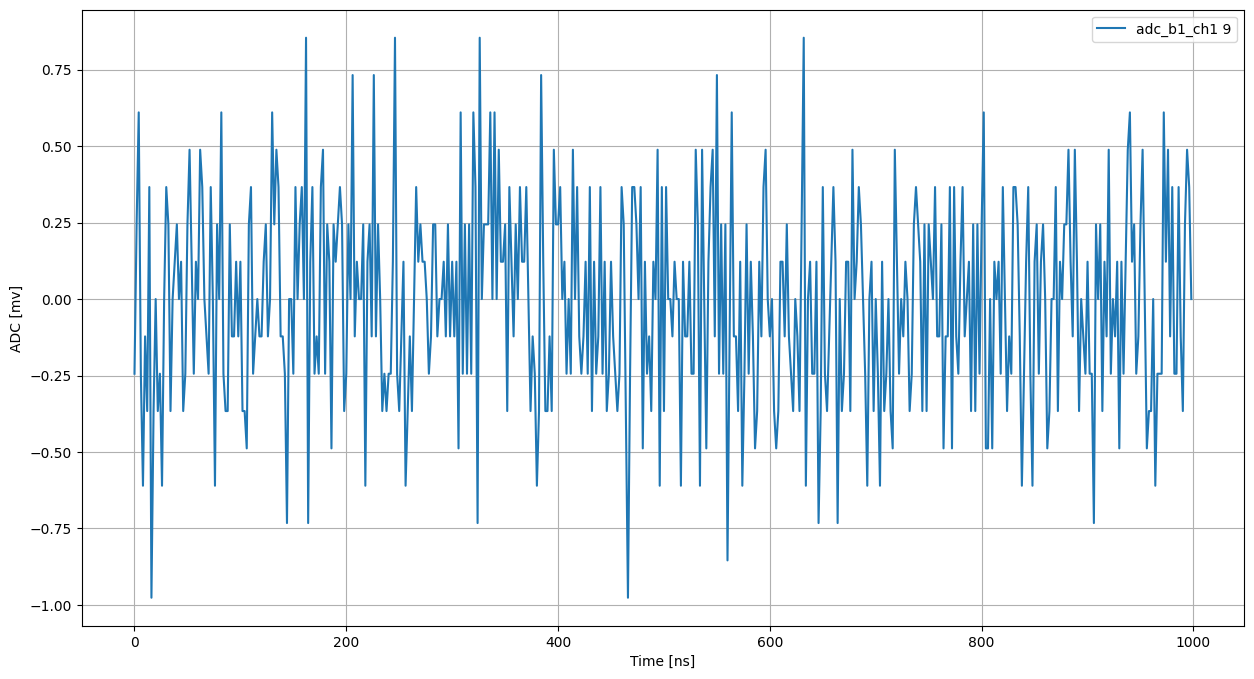

In [ ]:
#change these to control which date/channel the waveforms are from
file=FILE_PATH
channel='adc_b1_ch1'
numEvents=10


#hit enter on blank prompt to continue, or type n/no to quit
def nparray(inarray):
    return inarray.arrays(library='np')
file=uproot.open(file)
wfm=nparray(file['daq'][channel])
status=''
i=0
voltageFactor=2000/(pow(2,14)-1)
while i<numEvents:
    a = wfm[channel][i]
    print(a)
    a = (np.median(a)-a)*voltageFactor
    #change which if statement is active below to only show waveforms above a certain height
    #if np.max(a)>16:
    if True:
        t = np.linspace(0, (len(a)-1)*2, len(a))
        plt.plot(t[:500], a[:500], label=channel+' %d' % i)
        print(channel, np.std(a))
        plt.grid()
        plt.xlabel('Time [ns]')
        plt.ylabel('ADC [mv]')
        plt.legend()
        plt.show()
        status=input('continue? ')
    i+=1

In [ ]:
# data for adc channels is in pico coloumbs
f = uproot.open("/Users/bigd/PycharmProjects/EDIT_Event_Display/modules/src/EDIT_Event_Display/phase2_wbls_2pct_muon_mid_x64_19mV_alpha_230701T1014_0.root")
print(f.keys())
daq_tree = f['daq']
print(daq_tree)
print(daq_tree.keys())

# this ensured num of events was same for all PMTs, cool
# for i in daq_tree.keys():
#     print(i, len(daq_tree[str(i)].array()))

event_ids = daq_tree['event_id'].array()
temp = daq_tree['adc_b2_ch6'].array()
print(temp)

['daq;1', 'run_info;1']
<TTree 'daq' (66 branches) at 0x00011842f2d0>
['adc_b2_ch6', 'adc_b3_ch0', 'adc_b2_ch9', 'adc_b3_ch7', 'adc_b4_ch1', 'adc_b4_ch5', 'adc_b2_ch0', 'adc_b1_ch7', 'adc_b2_ch2', 'adc_b2_ch1', 'adc_b1_ch12', 'adc_b3_ch4', 'adc_b2_ch4', 'adc_b3_ch1', 'adc_b3_ch3', 'adc_b1_ch5', 'adc_b4_ch13', 'adc_b1_ch11', 'adc_b3_ch6', 'adc_b4_ch8', 'adc_b4_ch11', 'adc_b1_ch13', 'adc_b4_ch6', 'adc_b1_ch14', 'adc_b2_ch5', 'adc_b3_ch11', 'adc_b4_ch0', 'adc_b1_ch9', 'adc_b4_ch10', 'adc_b2_ch13', 'adc_b3_ch12', 'adc_b2_ch12', 'adc_b3_ch10', 'adc_b4_ch2', 'adc_b4_ch14', 'adc_b3_ch15', 'adc_b2_ch15', 'adc_b4_ch7', 'adc_b2_ch10', 'adc_b3_ch13', 'adc_b4_ch12', 'adc_b2_ch11', 'adc_b1_ch6', 'adc_b1_ch0', 'adc_b2_ch14', 'adc_b3_ch9', 'adc_b3_ch2', 'adc_b1_ch4', 'adc_b4_ch9', 'adc_b1_ch2', 'adc_b1_ch3', 'adc_b2_ch7', 'adc_b2_ch3', 'adc_b3_ch8', 'adc_b2_ch8', 'adc_b3_ch14', 'adc_b1_ch15', 'adc_b1_ch8', 'adc_b4_ch4', 'adc_b1_ch1', 'adc_b3_ch5', 'adc_b1_ch10', 'adc_b4_ch3', 'event_id', 'event_ttt',

In [ ]:

df = pd.read_csv("/Users/bigd/PycharmProjects/EDIT_Event_Display/modules/calib/bnl1t_spe_fit_results_230420T1832.csv")

# ccess columns as variables
ch_id = df['ch_id']
ch_name = df['ch_name']
pmt = df['pmt']
spe_mean = df['spe_mean']
spe_width = df['spe_width']
chi2 = df['chi2']
dof = df['dof']
spe_mean_err = df['spe_mean_err']
spe_width_err = df['spe_width_err']
HV = df['HV']

# the first value of each column
print("Channel ID:", ch_id.iloc[0])
print("PMT name:", pmt.iloc[0])
print("SPE mean:", spe_mean.iloc[0])

# get tuple with channel name and SPE mean
chann_SPE_mean_dict = {}
for i in range(len(df)):
    chann_SPE_mean_dict[ch_name.iloc[i]] = float(spe_mean.iloc[i])
print(chann_SPE_mean_dict)

Channel ID: 101
PMT name: bt_p1
SPE mean: 0.930999341046264
{'adc_b1_ch1': 0.930999341046264, 'adc_b1_ch2': 0.9061144309318712, 'adc_b1_ch3': 0.8392086048978025, 'adc_b1_ch4': 1.0188792630445187, 'adc_b1_ch5': 0.8571872578036189, 'adc_b1_ch6': 0.8887604587687018, 'adc_b1_ch7': 0.9160206223663412, 'adc_b1_ch8': 0.9788288742150532, 'adc_b1_ch9': 1.0622450216959698, 'adc_b1_ch10': 0.9606945708957306, 'adc_b1_ch11': 0.953469399648617, 'adc_b1_ch12': 0.998699359687559, 'adc_b1_ch13': 0.8141626471664862, 'adc_b1_ch14': 0.963979364166906, 'adc_b1_ch15': 0.8997711372254543, 'adc_b2_ch0': 0.8689176918953643, 'adc_b2_ch1': 0.744651528054722, 'adc_b2_ch2': 0.9613804571132436, 'adc_b2_ch3': 0.9845536254369124, 'adc_b2_ch4': 0.8779618807231395, 'adc_b2_ch5': 0.9593546464872158, 'adc_b2_ch6': 1.0811756042179228, 'adc_b2_ch7': 0.9120578139906804, 'adc_b2_ch8': 1.0038087955997674, 'adc_b2_ch9': 0.9439793072840978, 'adc_b2_ch10': 0.920857079458285, 'adc_b2_ch11': 0.8814941988689673, 'adc_b2_ch12': 0.90

In [ ]:
# chargesAsPhotons = [evt_chg[n]/gains[n] for n in range(len(evt_chg))]
# we want the total photons per event. and then we want to bin this in a histogram
# so i want to make a list of length 9898 that has number of photons corresponding to that event basically
#print(daq_tree.keys())
#print(chann_SPE_mean_dict)
num_photons_per_event = [0 for _ in range(9898)]
#print(num_photons_per_event)
# event_ids = daq_tree['event_id'].array(), this gives array of branch
for branch in daq_tree.keys(): # branch loop
    if branch[0:3] == "adc":
        if branch not in chann_SPE_mean_dict:
            continue

        branch_gain = chann_SPE_mean_dict[branch]
        picoC_values = daq_tree[str(branch)].array()
        for indx, arry in enumerate(picoC_values): # change this to test
            arry2 = (np.median(arry)-arry)*voltageFactor
            ntgrl = np.sum(arry2)*2
            # divide by 50 due to resistance
            #edit_array = (np.median(arry)-arry)*voltageFactor
            #total = float(np.trapezoid(edit_array))
            #print(type(total), type(branch_gain))
            num_photons_per_event[indx] += ntgrl / branch_gain
    print(str(branch) + " is done")
final_num_photons_per_event = [float(i) for i in num_photons_per_event]
print(final_num_photons_per_event)



adc_b2_ch6 is done
adc_b3_ch0 is done
adc_b2_ch9 is done
adc_b3_ch7 is done
adc_b4_ch1 is done
adc_b4_ch5 is done
adc_b2_ch0 is done
adc_b1_ch7 is done
adc_b2_ch2 is done
adc_b2_ch1 is done
adc_b1_ch12 is done
adc_b3_ch4 is done
adc_b2_ch4 is done
adc_b3_ch1 is done
adc_b3_ch3 is done
adc_b1_ch5 is done
adc_b4_ch13 is done
adc_b1_ch11 is done
adc_b3_ch6 is done
adc_b4_ch8 is done
adc_b4_ch11 is done
adc_b1_ch13 is done
adc_b4_ch6 is done
adc_b1_ch14 is done
adc_b2_ch5 is done
adc_b3_ch11 is done
adc_b4_ch0 is done
adc_b1_ch9 is done
adc_b4_ch10 is done
adc_b2_ch13 is done
adc_b3_ch12 is done
adc_b2_ch12 is done
adc_b3_ch10 is done
adc_b4_ch2 is done
adc_b4_ch14 is done
adc_b3_ch15 is done
adc_b4_ch7 is done
adc_b2_ch10 is done
adc_b3_ch13 is done
adc_b4_ch12 is done
adc_b2_ch11 is done
adc_b1_ch6 is done
adc_b2_ch14 is done
adc_b3_ch9 is done
adc_b3_ch2 is done
adc_b1_ch4 is done
adc_b4_ch9 is done
adc_b1_ch2 is done
adc_b1_ch3 is done
adc_b2_ch7 is done
adc_b2_ch3 is done
adc_b3_ch8 i

In [ ]:
hello = [3006.568063826576, 4066.9323237297135, 1218.329982071295, 2879.302530038133, 64230.83062121664, 754.1389299450324, 3619.321913813034, 2763.458415829448, 2567.47097380593, 5264.1722352687475, -314.05074478481765, 71772.50903902206, 5131.204213463055, 57276.003380522096, 4104.596384597258, -1873.5134351280883, 394.52774962543583, 3537.1152763488485, 3566.4852375346322, 74171.31451047423, 3574.2160123544845, 63879.818810627476, 3791.9897096467375, 2864.352824247416, 558.6679726773033, 2821.862825915751, 5069.814486079835, 4187.901778428615, 3144.3971581071264, -25209.511463262912, 3619.891100134752, -151.12284387460176, 5461.846127976422, 8497.82105933842, 4341.674146611951, 5019.241695597369, 4039.12875890355, 858.1590763538891, 4028.910306446968, 2909.3326592335884, 1439.5421091253431, 968.1923285510627, 74944.79435145417, 6229.314699998522, 79020.13191129679, 144.66694144196816, 2189.7903827780897, 76770.48690076952, 962.4154238093886, 5073.396161360818, 98052.73198660725, 8185.152681622548, 3250.7954264461814, 508.205981715822, 957.2037983819168, 5443.0510549784185, 56548.29386861134, 3012.118363570775, 3091.1435600226737, 1564.1419091416103, 8253.163053706805, 4985.681942310843, 3815.4805226397516, 1592.542506544974, 99106.18790059435, 1544.7806721565398, 1437.4004953046626, 7540.821364355468, 102753.826611515, 6148.3909944371, 3033.0705082149157, 1429.7775907272894, 821.233948830513, 1961.5437076242677, 76468.98436743273, 155559.4416399374, 3336.3751435833688, 63168.3212688674, 3278.075416169297, 3957.8259274671, 2932.8215270856767, 8340.14452596001, 192.76999277733347, 2526.8205745574664, 967.0933163782474, 3458.7265872348557, 4118.432448715416, 2250.811655782449, 2539.9401167581145, 2231.738620453079, -1633.9046469341336, 3990.707138949507, 7476.577362656107, 2222.143459315808, 3266.184340670643, 53915.48063400392, 4081.0509000019238, 5912.900590280682, 3707.3939561703796, 4510.290860390486, 4155.328834586677, 63569.381451740584, 4018.418887488526, 4215.149133503831, 77820.87240890834, 3392.2795693925154, 85876.17946834785, 5760.890361267449, 907.9719255940655, 65221.07653664127, 1521.814902495981, 2189.6454084054926, 712.8416313035765, 2320.9819050169162, 2064.4384995755663, 70992.02007420151, 48501.981230023404, 2691.0579285171307, 3197.8033443645827, 44850.80769503975, 5320.880906088763, 4385.8942926214595, 5466.176743502632, 1640.802678365306, 5349.474153384126, 2103.692134874513, 66510.97496545414, 4604.940084849986, 6233.48759120057, 59752.4243866637, 1160.7639716599904, 64349.41421025663, 511.2187325577537, 2221.064639591029, 3462.8392501804306, 41515.872268379724, 65096.15362752255, 2878.781124225583, -994.7565402231094, 2071.611409165306, 1311.9749909369516, 5118.821200457399, 3126.7189061549293, 2480.6144508219977, 2692.945581317249, 1710.579448386208, 1926.7703595491434, 5921.177645555413, 1582.3611646476447, 42787.770059130526, 2571.822371928168, 3704.249007665883, 45737.01861695149, 2678.147765873472, 54720.4874486057, 6431.570154590667, 70452.80703697113, 2288.718685034808, 53385.86474336861, 1620.8003467193682, 5757.906400079666, 1916.7453352673585, 1671.7012513163431, 38981.891322750125, 2246.5790198029363, 2660.7763441240704, 3505.717257629013, 165.89001086599464, 3970.476934619057, 143078.2039879327, 2330.750227079235, 6644.009173107574, 524.2310280959919, 4303.570305281416, 53992.399499314866, 2412.9159658866947, 1401.3269158142632, 1743.3039286416945, 1455.426031418942, 5042.557938841329, 5089.583397631778, 1322.5141494173238, 653.8297346810554, 8502.889016990577, 3785.90754490857, 2506.441506612735, 4122.232697693421, 1274.3062243884879, 3382.5715515215766, -225.0869800846971, 5129.180079799957, 3052.482253790082, 5540.814417458562, 1079.8942263742667, 3538.1687052258962, 2638.183362366406, 3352.756394118268, 3436.55152960942, 84451.46513996323, 5641.610869767672, 1139.3474609604355, 2364.5745073873372, 73651.01511187958, 4245.904001205006, 21008.90530501513, 5041.999112190672, 1753.205262719507, 2170.2888389758655, 41610.03143740582, 71197.88495461673, 1810.117167715059, -1912.877224192844, 2676.7264006888918, 2884.0224503181134, 5212.190042931715, 3968.4257563135475, 94024.94787396876, 3691.4769281648573, 2474.395945681351, 84635.50375414782, 1289.779909113357, 74595.75299477004, 5739.292543606641, 4278.619417121572, 4174.724291770654, 5460.544320687666, 2825.326613750728, 2652.0946371365862, 4437.527935625234, 77131.35580125965, -1500.244780437125, 8701.992955498807, 3934.715066313851, 5180.674469691454, 3626.1460983686766, 2044.441006064894, -27.596975399345666, 83365.0368932704, 65540.40811413735, 3791.45123156838, 1803.3383116489222, 2058.382429670576, 3333.5518304229045, 2384.7073346352645, 3711.585252433379, 60021.05545644353, -694.3000137520324, 3971.640343664706, 92756.99234677461, 4988.037103239782, 642.0905844494815, 3996.470104504459, 70442.7032343888, 5177.859516246118, 1952.5246906870784, 72115.0332254424, 427.53211169058875, 4934.871612937424, 5716.641728192115, 1490.5166729435985, 3736.5236640998774, 5608.234137696764, 84085.15381278851, 2820.9110840288113, 5382.261434371398, 2753.060969671015, 54251.33032740049, 1250.1926367906517, 91724.43056215483, 5439.216948045582, 2582.675892998192, 89349.61500018307, 2074.557928302589, 3847.333176988722, 1296.5772567269223, 5726.505531746965, 2536.312728751661, 5669.569416512365, 48317.51762198994, 5891.8025011379095, 69148.31253982268, 3681.8781974851117, 4100.28468797357, 3422.5337016615085, 5262.92615952339, 3214.007685056946, 50228.69655790922, 5501.911043484029, 3466.1936562346764, 4640.546549738682, -261.96295174292794, 726.7514583462727, 79354.6336521506, 4687.545671434819, 7168.075240244169, 69307.27897557367, 54848.87803941907, 2759.041682096069, 2080.483950604559, 3906.08398933998, 5350.733726663862, 80196.54755224945, 72319.27560139749, 239.57597525255716, 546.5795286941432, 2396.5671203012685, -1642.4916437275392, 73601.91870181984, 1347.5654533822596, 2815.363474146119, 6895.614814471764, 1116.1394611500907, 969.6115581386248, 3047.8175254747803, 2721.807198275353, 58606.09963702697, 3558.709178882695, 1581.3504558345114, 3250.2598014201944, -7.417902155835485, -2320.3198090662268, 1166.2127569381094, 6597.189829808337, 5098.941650722833, 4906.042613322123, 2150.2220385069004, 1287.6189482711031, 1151.3882398742537, 75144.72907482057, 1800.779491108023, 6035.154644979332, 747.8622530003352, 3856.7757496703557, 5979.196390349512, 1223.2038706070118, 4057.1484668357875, 7175.226115162754, 3224.043550147841, 8218.136246632574, 6242.003562732971, 4238.333003080267, 5521.529612865132, 4120.572032321626, 4071.337031154357, 1659.1554604813182, 2681.0596342302024, 2055.254039697977, 534.0468901808138, 134966.42727869743, 6418.35896753113, 2300.778832651232, 1702.1521726688034, -714.129632158529, 2412.901627931801, 2963.2369858923726, 2650.430472652374, 2938.5520336225914, 81686.24203474159, 4318.260974772999, 93649.26024736992, 3255.8539161817644, 64440.15056531397, 790.8723002632905, 8012.4388728706035, 4970.326112307253, 3182.3442260001907, 4790.502062808748, 53645.537711776546, 991.9780660878752, 71566.44330786052, 4463.683889717975, 74634.21167141625, 1207.4647872746962, 6377.896598168891, 1415.3295453874844, 105353.69629306423, 3888.1750794694017, 3905.245890579143, 2396.937714181901, 2468.000329022827, -1365.1735897167935, 173587.65142351622, 28.340963016264766, 76973.5355365671, -126.46692848297609, 2251.351707774016, 74737.86743775122, 1168.438512296021, 2452.324820269736, 4007.1687471706555, 62885.78191074187, 2494.7010380293286, 90913.58807368814, 88469.7491757792, 3639.9784852650596, 3926.0584752975387, 4232.826788402629, 44503.26206038405, 2553.8778618705605, 50688.6737526423, 2626.1494684829736, 72816.38082508753, 2397.9396330618233, 1291.7381939000768, 3745.1373484521487, 58488.136281361745, 3995.0433539069745, -216.74140491767363, 7216.038565949791, 5310.656127165854, 3486.288946186043, 6051.482668656067, 3914.4495375032598, 64998.232423296424, 3397.3743270066693, 4325.099220645481, 4568.078443150515, 4352.292571135788, 4459.471242833538, 1837.1454247012698, 5395.658756971297, 64826.48591611463, 2886.572308264513, 6338.651111742434, 3379.904145319824, 4755.594317348416, 3530.8905323664317, 5456.373946322714, 1984.4080888664416, 4891.293916706287, 6177.969053991595, 6324.9429969277035, 872.2677461185935, 2164.671320136437, -849.6427116375121, 3228.677957937246, 4102.036996336639, 2295.248718813697, 6069.591742659652, 4749.408025348079, 981.1637690175917, 4122.17667733208, 5163.928453854378, 2119.842459105917, 83148.07353499698, 2303.026585719638, 84972.0558312535, 67433.77924208899, 2947.9725263003374, 1965.7449933612102, 4530.289635911572, 4376.001783803343, 79665.26339848683, 2302.1234728264108, 3385.888072732524, 3025.8924399711914, 1259.943890677555, 4058.5438785955516, 2640.915705949011, -926.4984399098016, 4583.503933165266, 59459.64687118781, 5293.355686434014, 6126.163173106846, 4032.607250110323, 80220.65862972614, 3843.4004929199896, 64105.47037947166, 65067.00093163814, 61960.584442191685, 3273.430955011465, 79397.28349519793, 5198.032075808814, 1832.6965223372272, -1240.9563221674125, 6837.05135598061, 2572.3804459682274, 3201.4803001672053, 5912.132530042688, 2887.916349522692, -251.1190625029334, 37212.77673863144, 2428.198014903821, 74819.57123355434, 3204.243934877211, 2999.25324781457, 3351.852494563979, 893.7488800764879, 3809.58769769909, 2694.38504797067, 5404.3445751607915, -22.381659999542407, 6961.678983053418, 106969.20630948071, 3952.5407184251294, 2336.2941336278004, 73137.89839484359, 3902.4327543396716, 5983.727333135236, 5044.893221807482, 3465.99762900907, 69669.83655295584, 3122.8964278332455, 7034.767472864612, 2858.1206139752835, 64295.44072572926, 1255.6814489424544, 3685.5870079554707, 1670.2357265878466, 3249.7156662318716, 4238.818089831313, 1777.3960874483803, 2005.9594848152342, -1563.2528740290388, 1994.336078586007, 67540.7107837591, -1428.7833588187814, 4593.13908247157, 3153.60850935632, 96335.03516278251, 2204.169829692216, 395.90873772463465, 4034.7485846151158, 49210.58494282216, 4143.302693954162, 1282.1226125896155, 4242.017270602498, 2484.6147208674156, 69798.56244929848, 3365.089982803243, 2598.8468286033913, 3754.171979258437, 2929.4648001430487, 83061.12491963398, 37930.03830272755, 2052.306673122632, 112106.31098191727, 45363.68305027025, 2364.4100420227105, -452.6210091076925, 210419.90051657925, 3689.8924957178897, 61667.04688425633, 2967.8482767047303, 73745.21632641621, 1558.7715170265953, 33805.53944601338, 786.4948125475709, 2367.824168803805, 2359.997872737067, 1370.2211574450998, 5171.138245924606, -851.463785727519, 65700.33776257624, 4683.20692721466, 7266.969835196656, 4007.5329859711846, 52456.50795571667, 3907.059682088248, 623.4582348214483, 61200.25570256798, 4100.14034762557, 5258.91652202329, 4683.619414250718, 4744.389231890843, 124728.69190175357, -1407.1705392677627, 1946.8747991714454, 7111.597435747671, 4931.630745435868, 3709.6345401920694, 88459.75274967118, 4045.8847640872127, 4248.807889173013, 4344.222195969263, 3153.9533156659554, 26691.46792616195, 1541.2825771966507, 2233.9787975951963, 1962.1094248349464, 6147.707728599213, 4232.331218606758, 5005.060016330491, 5082.339061636831, 5527.899949753047, 3823.0926300661695, 76.03677708819104, 4163.228235152058, 60515.57034289337, 5184.763192113199, 4129.703826591726, 2043.1842870666862, 3294.0788144862977, 4933.611809884375, 2863.87827450112, 81832.86496218963, 1700.7477434336472, 23839.919808806204, 2862.7079467663993, 1851.0163620532178, 1674.997605104837, 2384.62447263361, 20629.967336717884, 73417.84816446251, 4545.417778946024, 46202.49938084407, 1424.82879719495, 17064.820289386687, 4437.585613362437, 3457.956384560712, 68606.85508110879, 2858.116471755112, 2516.9078105853646, 4136.397802950042, 555.3102704825131, 4566.7603257341, 3300.194870927817, 4875.329177806922, 4307.022182371914, 3344.5565764085136, 1436.5185229514082, 5345.325004192588, 4617.312777674786, 1861.9533056794317, 5394.923929565179, 2469.6118650870876, 3244.7579682500777, -889.5592198809202, 4498.034356271457, 76807.21598831408, 41185.66432226239, 4947.008961292024, 4412.413758567372, 641.7294537679785, 83994.30438110049, 2605.0847518982955, 3349.1060761539834, 71977.68006106197, 1913.2038507123925, 4692.9809948717875, 2824.405191322385, 73571.2862580708, 75443.00967794524, 4222.931522936645, 6081.5350486179295, 4152.6765156605425, -633.2088089620776, 1072.7352545793938, 888.3217746160192, 1347.8112446886576, -1718.3150018027602, 5516.514106527863, 70792.15640874335, 608.6208084884145, 76252.17877349425, 1122.9920392088907, -1532.4518879843076, 6513.918665483201, 2229.5453204658675, 38352.326587360185, 3274.575201732554, 60764.30002956169, 3975.701692133608, 68137.20854167681, 4593.3530550910455, 5501.259564995363, 5039.539410832434, 1147.0819841220944, 5696.379508701859, 68472.50258833151, 4322.956671703019, 2867.742417740003, 2633.082135166433, 66811.3470690974, 5324.110964924873, 4308.607933259035, 2596.6032097864017, 2532.913415811452, 5773.239200320807, 3395.005399414611, -170.3051003206864, 47767.490917911346, 5320.945542345813, 5901.175612934954, 2716.5468692770096, 5547.628102958422, 629.5039997873542, 6049.400332599747, 4600.3836736135545, 119529.5717199929, 3793.99964935473, 7518.3707373673205, 3157.6852947450493, 1478.6174161709814, 62023.95113622869, 3981.7812085079654, 4776.078840868265, 1405.8542963990844, 2437.9044982354135, 3614.0466296180584, -277.6022774020809, 2861.4673760896026, 3717.648768006935, 3767.355011431279, 3355.0651120432467, 6939.005222145837, 861.1017696006618, 1801.3990827392322, 4321.663609354446, 2627.2103145049837, 4299.886059793395, -90.65143575371636, 59431.90672223854, 77303.30432363512, 3042.6339807682734, 2567.1733812503885, 2918.1340543850615, 31743.060916703365, 328.52782790055977, 1880.0137105650647, 5494.402104865186, 4019.395107569901, 5309.988533202844, 114266.81310169637, -877.3802395377995, 5114.927281138929, 54655.76744910921, 1386.582093285001, 1096.297187197175, 2208.656596360183, 83586.38769013727, 1959.8879620742784, 3818.2274813235654, 2400.129144170746, 3055.190959922802, 64643.087833040816, 1539.4716590445494, 3517.4604695029498, 3296.6275434346003, 4886.044437631627, 8127.46659770164, 3323.010418123909, 2649.2497789806625, 3948.897058751113, 2848.652129044016, 78491.28295686543, 2350.950998076268, 23209.046010417485, -695.9427523137623, 59189.99967250222, 3600.5280250151, 5966.076992749889, 424.5707241281717, 5522.031151851678, 65862.44901352587, 1693.1888520924185, 3150.5167710854466, 76531.99548919393, 1974.5762663837506, 7735.228037250778, 38018.96038108812, 3284.3121996956934, 4900.3055183646475, 1247.8816687757526, 2218.025994831435, 70805.19802325056, 3744.252614651253, 2382.8047062885603, 37753.00601314443, 1943.3297553164523, 4700.142068360478, 1538.3883738863688, 2251.1177342704104, 3153.153992381559, 3973.647035406671, 2074.7528745211744, 66333.08841576928, 5121.270266952533, 104383.43702913492, 76549.76632582508, 3269.357723040359, 2404.0697148215604, 1641.8850052329904, 4297.37254543156, 56268.376441702916, 135394.16162461333, 1846.971173195497, 5587.169201316668, 61604.18558132796, 2777.9615454875507, 5101.342844440164, 2891.615942946195, 83036.45442365744, 2578.6707722069623, 877.133380162773, 81093.71050215368, -956.9430464965699, 6754.138898039996, 2857.5837560357995, 1349.1517483101647, 3504.4107674753445, 3076.171017722875, 4200.32206482364, 4793.187037912417, 1326.4731406438273, 6210.581925516479, -146.743093716694, 3933.1730215405883, 4103.237699444544, 2967.9275057761315, 67510.48472937163, 3825.814409835662, 3898.6380052360046, 2058.6614845851645, 60543.135732939874, 1895.1793502502378, 69972.17295482241, 71751.23882341557, -1132.92343727775, 1663.9397018677832, 67604.73914572809, 2674.4007079313765, 7033.165924717332, 3101.391351693609, 64796.51609718333, 1142.4953008927507, -863.5740727083571, 97364.61849457207, 2932.2821241168454, 1192.273894473963, 24819.67066275752, 77758.50332854505, 605.9717983186654, 1293.3763381594663, 58887.25575168341, 1405.2550042899643, 5223.554468086782, 5559.434990672783, 87248.9180142258, 2407.5736211105404, 66718.81657574973, 2217.115701310605, 4819.428559086745, 4799.895805207893, 83416.23877619827, 3310.233417111237, 33912.44437690887, 1449.3059017322753, 5697.4440786749665, 73200.77153128586, 2384.776367848758, -270.78429320908447, 2659.980756249174, 4015.5635838250732, 4136.2636212605075, 1367.3568001461942, 5018.139463446252, 107664.38233979084, 63572.03714673837, 75465.75180709752, 2430.2057249712743, 2573.5692056123517, 3712.3900586914256, 1501.2560641733808, 1705.8730881297015, 1111.586588026954, 3778.728943569417, 62307.01926883143, 1879.7354857034686, 616.9155855971227, 2380.9232517186465, 3121.18633044533, 85224.10031003878, 87730.61371661029, 50621.533921802096, 4592.093655515897, 4599.69702931847, 3511.9953503213774, 1851.859009839615, 1665.69610096673, 4326.246400365877, 2257.303941186114, 73149.22039412698, 3753.394806000712, 62584.40644965882, 4705.500844022137, 4118.615739169503, 2352.642991825335, 2162.8379860586706, 5513.960325956911, 219.87638325720616, 5177.304886937209, 145468.0716047745, 1945.347733166206, 2728.1451125697154, 66177.82803811462, 5689.009264741571, -521.9305499143936, 3391.2019746278406, 86750.60351784411, 4194.363084610353, 3294.911841604725, 8301.974985087549, 5625.467908972853, 6602.571533584719, 75467.31917854714, 4645.933702789128, -724.6881446157022, 85290.99798183482, 4809.438340878399, 92287.50429647845, 155.59433133957918, 4218.190008286819, 4187.940223434872, 3704.797910577211, 7019.053905976749, 2981.0656856233254, 2565.3856596510464, 79099.60841721464, 6535.769012389239, -411.5727657008877, 82964.32710948751, 1268.0432812281088, 5818.162176781177, 5197.128875580505, 2134.607217873884, 436.2915920624993, 3709.928070840904, 980.7018790577, 5523.330585755811, 3038.012157724691, 1139.9462330477256, 3795.0062074145276, 1119.079919753652, 953.9529208506038, 4622.192683583246, -472.4792222418857, 4296.270814947959, 3685.503545886844, 63275.130790077885, 4957.618904099938, 5009.9929704886845, 6140.092658777131, 1585.2483933123465, 51746.06398896038, 1665.4864300945183, 2720.6070336064245, 2298.727768136265, 4732.602565137519, 3474.8038600547957, 4040.0079972305566, 3165.291564134098, 5726.106469301079, 2815.633307792812, 3438.4232735423784, 6155.162130490941, 80944.72987303486, 2571.121063411896, -334.67613023322247, 6533.916354386064, 80111.67794764254, 2425.543689629029, 5284.968522362708, 2454.302337349462, -587.0807899815936, 1150.5980678196447, 4671.561068229445, 3703.6641244823268, 4794.614267952064, 5959.275154539421, -425.92494777912987, 3732.8474004052546, 3480.759934493189, 3282.02829636002, 5277.515608935093, 5410.5592002510075, 4596.937523916609, 71533.54075110279, 3899.5595808009502, 3267.1320086666515, 1200.7171939581515, 2403.8890134578237, 2130.3229192191643, 90261.74575382777, 1532.594660409691, 2817.90241026663, 2718.117755141062, 66145.55422749244, 25882.75329185018, 6801.361175874791, 4404.283975649753, 2428.5635918600574, 66022.24561939875, 1259.5145885101058, 1351.1274050980326, -583.805393752363, 3366.9693778798182, 3747.1728698019924, 2411.64304786227, -1503.1161131287952, 4164.51379813167, 28296.1431282809, 2962.3706193374687, 3068.7920707453745, 481.56116990491626, 1340.6408823860888, 60585.700400681555, 5486.649616458433, -644.4204602412801, 5662.774218745762, 3126.9642717520674, 3265.4926016371624, 66446.29075284128, 3845.7271782596813, 64382.01296146041, 1383.9959264071156, 3969.4419132285193, 2442.233964750495, 3908.4204844854494, 3065.5884298730325, 4737.9798441718385, 71972.44450117768, 4069.011237176234, 77018.03320185404, 1811.6026018031225, 2408.3995294653664, -841.335015548344, 95541.58975407062, 5340.286116005059, 6280.905821751161, 4717.481936862778, 3831.0926089898135, 4073.6189263071306, 56561.207323314455, 4464.348200834252, 78703.3171697501, 5713.927391104096, 5425.718534511219, 5719.817067091847, 594.2844430589939, 3996.085380070124, 63985.14099857012, 3441.825642225488, 57220.707223864374, 5298.521280667467, 1994.5513807077596, 2104.045962901893, -694.9234385192581, 4650.3675822118785, 3056.4873295742063, 72756.70226121272, 3955.938951760131, 109185.35773688028, 67330.68944775262, 2013.3169431057875, 3372.593679562999, 4266.981420535881, 3509.9737909017776, 76247.94885634862, 56905.182332424025, 5776.064889089639, 64948.83121193243, 1915.6934721725622, 56369.04607160064, 1283.156798687214, 5918.7850194081875, 5495.658203951948, -429.8005379583325, 3304.2186097232984, 178.51229061657335, -1510.6236385198838, 3953.825291269037, 89205.22746900546, 1593.630702967443, 6073.142556725649, 5501.709410983888, 31129.19139989417, 29210.053294892637, 4488.6433991741005, 3927.931462251253, 5728.086444296934, 4969.131443441801, 4376.3142278237465, 3575.2387366127086, 48209.029706094574, 130.7227852588167, 19144.951848360095, 1739.8578238403193, 3139.1314123466063, 2803.282401411032, 4839.3006861051945, 5951.97713171174, 2510.274596310036, 2882.8646311496104, 2441.864980492874, 2118.3693571308777, 4477.638043560599, 98858.53939648718, 4704.708997009108, 4715.075651124596, 1537.7966032893305, 4485.855347813052, 4855.626118080986, -677.8391239936318, 2079.028377402041, 3295.266193973425, 2665.995306608762, 83166.38164268166, 2306.821187969411, 2143.2790225197623, 2806.967798961392, 60182.23517546749, 70069.12598356428, 783.1634977550154, 1551.166541653081, 82513.9200827497, 875.2519881711407, 78146.99171619835, 3106.4702374212675, 3234.9203247481432, 10410.428579271784, 2316.1140651241762, 2669.7954671119564, 3311.8961522963173, 2778.8657768189514, 68645.26301993938, 3700.6963521026646, 5558.222146112389, 5807.539790665181, 2779.5685608745703, 6651.5833101167245, 1554.2343872302858, 54584.79396591955, 2460.809633232869, 4563.0046008148065, 2392.472614395577, 4363.65721772287, 1354.2722983802255, 6122.772048407959, 2285.9713484676445, 2951.720534218245, 8247.498380149864, -930.7236503770434, 63007.817023127536, 4916.257273913955, 3584.563101568872, 2991.254898775395, 2788.097006518564, 1271.2765956766752, 73230.87604626281, 65263.19818838248, 71624.54333085143, -31.543173303724544, 74513.3167582842, 566.308153122129, 3781.688468014276, 69482.80955139692, 3118.2808752628985, 1744.4249806028747, 2161.02044802191, 2146.9610496823125, 4651.025588228549, 68934.91441551658, 6329.095344757464, 2828.99329727482, 3272.2818325140674, 3298.341777671263, 4989.339153567033, 119997.26821154745, 69827.04136121874, 654.1758033944127, 5700.00545904531, 3553.6463011112332, 63099.46445164607, -1925.2670887590357, 62454.67959892268, 4631.860560159263, 1814.5564356358732, 3266.237189390596, 66117.83330190042, 44955.40222195076, 71650.48123223962, -1392.3015640207805, 4173.114386520067, 1931.7040302762864, 1989.5799293696648, 52830.08692466946, 2339.824667559376, 7990.732202226571, 2804.837663202889, 5533.616715012526, 2841.1990580448696, 4615.015728472873, 1555.1132738879062, 72887.64296578706, 2372.7273832348023, 2147.333399364974, 68835.02040170794, 2177.616870501019, 4722.422183372555, 5330.0919397483285, 87569.39527035024, 4287.7683915577045, 40479.686294160536, 2532.988148422296, 61565.04054005738, 2197.7173028453362, -892.7190715488754, -66176.39190456252, 7525.884310103983, 3855.363655648762, 4362.28554740572, 3575.2654833433317, 237.22690139691883, 5287.695579725461, -349.63578757843857, 1454.8764861537647, 2179.6366334045833, 3473.666683640102, 84610.56986473946, 3555.7544309456025, 1904.3873486292368, 5869.715714382041, 1505.4024602934262, 89194.75790426039, 3511.279618167523, 3278.8035831782695, 3657.721163118378, -468.8592171143417, 3279.3467031009436, 3686.0978750202075, 2168.5042919583716, 1919.9443508677818, 4820.784306742507, 3244.520021570693, -361.82674418788577, 58365.727719270944, 111616.22078396419, 1452.352990850884, -1769.5187866942586, 4022.622929550277, 326.31985425190464, 2638.5986405740414, 64985.393477323916, 2068.4237650176774, 3066.486169124461, 2768.471217628414, 6165.37318573961, 58913.57761985871, 2263.11190630907, 843.35649540497, 2900.0916060721347, 79947.31328354012, 3761.501185495801, 4740.843012347822, 1866.4279978629668, 2733.7366531174057, 61607.273421088204, 65737.91113608718, 3546.420641500242, 3634.429571433566, 81169.56487421315, 629.8846910124832, 394.7699859278699, 4756.61465029119, 1765.1542025540828, 4438.324822991192, 1535.7823562950182, 1499.937769208097, 2027.1334621875512, 1731.9444827630848, 6295.00861328423, 1836.4283585974479, -856.7500317480653, 78677.85674786, 1844.1057744158302, 6424.58866828752, 1997.011590449377, 966.287115274606, 719.3088185071351, 46380.43559121064, 3811.9501291228066, 3351.3249267876213, 6050.782163912764, 75539.02964645108, 5617.3284887854215, -2645.562496184234, 4261.99008524183, 4487.426916750859, 50984.81846493163, 6434.676477241659, 166666.80219704768, 6926.756265194531, 1833.7039494332967, 3802.037783241817, 85450.06274580736, 3316.8046593535933, 4267.967534669715, 5218.565979023119, 3169.5290115652106, 91084.59592864806, 3609.758802829117, 1897.449148529061, 2476.833086636815, 2760.0835458395313, 76020.37548888357, 5005.727937165597, 96052.67988365208, 106847.32807470723, 4.514799300961613, 5192.177848093066, 1639.026643630175, 61263.17969345032, 6586.532750256373, 66973.26725040421, 3938.793992386034, 139789.40026025564, 2632.400881555067, 5232.830937613153, 119.22311190880338, 1447.1657918479896, 7329.041044316248, 22.985077075157207, 3978.0059873400332, 3785.1101723859892, 10025.30839406295, 4335.3862052813565, 5095.6587289560985, 2281.6898061934735, 113587.06501244266, 4614.860512022823, 4976.593566710457, 2851.033354963053, 6266.439282922774, 80506.04588996146, 1329.8757070323436, 1353.6551540618723, 100138.3633036883, 3259.324608442279, 4201.627988377015, 7680.166536908252, 3232.4330579876487, 5159.60903295398, 4011.9963808720936, 2211.4142012137263, 309147.567726231, 429.8387825249748, 3479.4803883063823, 2465.9023353179755, 65544.6832493491, 933.6199145423199, 5233.84584517023, 6336.101609330197, 54509.85215056719, 8189.033994840516, 595.8700740050261, 42281.09008171994, 2271.808843789618, 1425.2681335260738, 1644.359010043146, 4708.784675355679, 5115.745294547112, 5586.656021706047, 3795.391034306765, 3919.754770369012, 2041.7569032061926, 2720.581988539686, 56955.552789458176, 5615.791040975389, 7000.944589042385, 3000.5785037993983, 5658.889333880239, 412.3996520232748, 3393.0602247775278, 4681.796252831429, 3290.38371854868, 68214.96445131613, 75167.4443436276, 3906.1325945231847, 3432.1311311343393, 4708.211044777077, 1133.5860537930164, 61609.960313518626, 78416.94573694392, 1810.6504265714466, 3353.2302284182456, 5825.111911920067, 1967.9057291757567, 52.13552428784115, 3040.7132228160585, 4053.7875934900603, 7989.354891061528, 4751.069709916783, 1881.831102819889, 1846.3704523399076, 129372.52516438773, 4939.142111486633, 66173.83276293505, 6074.961690463753, 65992.67290820436, 5083.668056121757, 3420.491166233825, 6213.117866225749, 956.9216312598899, 55352.99184044635, 2689.897313404804, 61090.082148628004, 4889.533776356918, 70147.9868799329, 4124.954081273732, 2927.6917776405876, -542.4178345749947, 60465.83183659324, 2178.303398338781, 3991.1841232161173, 5546.720085848273, 1914.0685252140127, 1280.2448422201214, 3969.9462775145503, 3799.051091332247, 85791.21121550108, 27510.99576431799, 7650.416704050691, 6937.418683911672, 142076.28372875755, 3066.1934056290474, 4842.147061973452, 3321.67782746513, 2906.5473715968105, 112.12172305665567, 3640.2033511095415, 4203.91643020033, 97305.17892364149, 3974.240500592257, 5113.595068723799, 8182.537971189779, 4645.24667909739, 60636.80326582249, 1047.9299586774891, 6066.298566632892, -138.0049711641582, 6434.580055921229, 2930.9100604539603, 2001.1502644528744, 19281.488362642525, 2737.330074076029, 4998.477152465056, 2805.3246111430026, 2948.1307145997735, 5769.075680023644, 4496.450172731936, 3986.3517559981765, 5641.540741228649, 4828.682540069763, 379.28035342960516, 374.57420632906536, 113583.7100240423, 1171.6176848351447, 30245.63893824469, 5261.205308891564, 2039.9973004042918, 76822.63706752809, 2684.113588522711, 5285.343102027661, 708.4796189899257, 4940.943685439088, 24214.322254535517, 4151.586770891776, 70651.22939955405, 4010.0221896637113, 1280.0852533681714, 70858.95563212768, 39794.6676441091, 4225.690968346597, 79994.14013515362, 2175.7405465932247, 1989.263660342335, 84182.90773279419, 5316.932549110358, 48878.20694800683, 4447.567400410156, 1100.3578396047837, 83398.1051445212, 50287.33916095795, 6819.196752289599, 56933.222779841984, 3141.770100503492, 2689.3222854787277, 1520.4681943652197, 3995.527895883292, 4338.340362903131, 2909.7785143207975, 55735.61637065478, 344.40025503949107, 4290.929653818904, 4241.070239676534, 4626.78011282644, 58189.99512552599, 5876.027844015936, 1211.870266903195, 75236.138851268, 3884.601542176114, 1315.118231758445, 5303.898559918574, 5069.986449877332, 97866.50195092568, -715.2449265369553, -1754.1231473564385, 3828.8051028739233, 2368.2655970397414, 3326.4308467057162, 2556.7157809587907, -667.8776374190918, 77131.92936781052, 2098.168731896633, 1672.1466266641003, 869.1324096671526, 46391.20264946974, 1674.1380096445478, 5828.003830628434, 3893.0470526381114, 5070.8422042387865, 187629.11536552943, 3932.8302984421202, 3461.489915897144, 3753.377832695415, 4554.265371572212, 811.6909774510274, 1725.5398120179414, 809.4756744296225, 1469.670801876321, 2588.6625782693623, 4747.295829564341, 2891.8176687223813, 1205.4328456253834, 30896.460588582337, 4192.771823837167, 1527.0085900905567, 3441.767940210695, 6076.100669494533, 45977.713313217544, 5409.007226954689, 484.35427649586524, 56441.27757227895, 2847.5853368784137, 91124.54570461164, 1238.9124928633944, 996.1787109756934, 2991.0739939955065, 493.18265828958954, -309.6599788278397, 3163.195847022734, 1633.7541309520745, 2033.9299632578281, 4338.324672639102, 1076.9295359925172, 25957.470163361824, 3083.765735731434, 2735.5714894695357, 5317.925989077151, 6297.038556475579, 1395.2694371947434, 1512.3194387797246, 1154.895179724361, 812.4774649426614, 81774.70127925806, 2596.6290576618094, 1404.7485685564861, 3313.980550306907, 4654.357850498555, 1720.2374429153474, 4549.715308588695, 64428.10110814706, 4053.9393533629095, 2636.684090348575, 3670.3202651636293, 153095.73044778334, 3644.584066864631, 2980.169466522479, 350171.8077887054, 3765.931518404244, 3714.6968848922565, 6803.972868686458, 1087.3190214560045, 753.8838388776473, -294.09873058760024, 58.82353022562714, 111225.28645613929, 3687.5138639375195, 93.74744456617944, 3103.7681936194595, 1937.2913900147419, 2522.2607122708637, 2693.658953834189, 83346.46685146818, 84000.44469682135, 3470.2723679989167, 41469.741629200944, 2534.575408332178, 4007.161604837041, 4832.817336175484, 59164.51286126973, 4784.849045572698, 4906.885228006237, 1905.978749659948, 74990.39314234452, 6816.282813966905, 7207.228917080473, 4315.792290477737, 3157.265592985943, 3315.3569114655465, 73089.08447107126, 6158.828483468779, 1054.3055543582045, -2983.001021421209, -145.4304143375872, 4672.593579071363, -785.0688747708948, 3492.202511679702, 79374.47849091508, 3597.9320780142443, 3723.059659546301, 92332.87770434945, 5146.4572698712145, 4843.409084632679, 3958.0910742851397, 80342.8997187606, 3346.3578217193394, 6126.642738653352, 76585.3565208416, 779.6290127563018, 2298.4663281379853, 5982.368984428419, 3351.1140672089136, 22440.546185727377, 2064.151864132766, 3806.645069406374, 88.87021510140556, 72930.53051072196, 3495.430237276303, 73214.28633994986, 299.1139044624136, 1769.406276300825, 85846.11527391031, -123.34915851475023, 61919.32138400885, -1761.5483694115424, 77731.98528428469, 3797.493919288929, -986.0055873875351, 1098.9635315692437, 3585.7165911050356, 4162.250159250572, 31.72865732419423, 50764.73390908994, -1244.354515354255, 3874.5435569855367, 5320.731225604136, 74727.57013065943, 4767.05425723628, 83256.25363837785, -70.77513071622474, 2197.1518698751433, 78635.59520585756, 2472.595567910521, 205345.69363613037, 3387.6789289025737, 71377.87149943356, 1804.7437861908345, 1856.7895330933077, 3564.880873645991, 4489.3642768064565, 3792.0396116120432, 4145.729477368717, 754.7572682370718, 3594.5210319911644, 77342.89710267146, 37952.69036014111, 3975.831993932041, 64964.82471223997, 53672.55050190992, 1281.363255430018, 137.8635326531574, 4738.867102872929, 1702.0680716707425, 7905.927626980895, 2030.5328258349307, 79870.96383221877, 3353.62184056968, 50716.46084172788, 4490.868024354467, 4845.573586474416, 1387.7623735829345, 140713.4349255361, 4983.807945681995, 1146.443515765394, 71384.6739902202, 3061.8850072416467, 64475.00889835799, 20527.091767661328, 1307.0777510970922, 118062.82225997192, 61945.6250400381, 3059.006672953544, 81901.381165825, 2464.299617347701, 1663.9749638435837, 70349.97713095587, 2419.12232322205, 1350.2343809689378, 3771.185072112313, 2497.8032936622076, 423.5998205576001, 4321.203434264012, 4946.111689557254, -36.174933835212556, 4803.295003870568, 705.2007687539656, 50213.44458711498, 408.16215147505324, 3850.706735996815, 2284.2299643110828, 63610.80566035076, 3434.295607477017, 35924.90555717655, 4040.9033087222992, 2476.132770408769, 62965.373607071975, 2663.2670363359216, 22845.52361089283, 7073.539165595777, -399.70676659583097, 71607.83050765656, 4576.199653906606, 1769.5186758839989, 1836.9292877339867, 2705.3462048199053, 1131.829312010784, 1429.0490708348955, 579.0622386743771, 1850.858103745271, 5572.366752663049, 2274.4746148094855, 2179.2091588692188, 851.8051867747721, 649.7467390616516, 532.2896219041749, 1805.9194317085446, 118190.76008633588, 1213.7809598078775, 72835.91612331843, 3660.731458913694, 3785.9237078090487, 220.684654683333, 32016.703209920124, 546.9400999574675, -567.4531809477282, 2716.05442901353, 218.88199814575717, 7483.870240533169, 53202.55511695728, 22143.252154502894, 6162.662604731675, 19553.16025448578, 416.3036207742251, 4660.620460236148, 2309.267474823687, 2976.645197882342, 55285.94383261323, 6900.4249604225915, -2826.543881735238, 1726.3807640790017, 4379.016569112142, 1501.5566037177643, 817.4473041939117, 65846.29803881042, 3995.7924394702277, 1934.2615162089592, 4738.204649467564, 2029.9496164305356, 2815.9873892218366, 5099.591660610163, 70421.16000998106, 1657.6967609785775, 547.8061999610914, 3330.817416624528, 5681.22788807283, 5393.302087001343, 1342.39442001229, 1369.697207000638, 608.4839573022662, 71969.04319522805, 4704.7075120128675, 2246.186695039629, 3002.6021959469276, 6646.324409487585, 635.2868512911703, -37536.36979308942, -43.5952447560528, 5272.583401336962, 2377.4188626641426, 3936.815498718346, 50.961104767562716, 3992.8346136445575, 5118.449980036945, 38241.06257707981, 2109.0904820553433, 1727.3754622503548, -1492.0583190634297, 5931.805484027746, 79925.8277612386, 53500.880589424334, -337.11117405733046, 3476.2257249216073, 3832.9611099925332, 2888.989511801583, 3754.867638159948, 1419.5351307917763, 1944.7630737465618, 5279.131696720921, 2671.7644949017917, 1181.886069855786, 4588.695762236894, 3788.7677566782927, 5418.169817941522, 106744.63097602392, 1534.542067495181, 4044.8645277097166, 5760.366595768554, 2082.7952260613747, 1290.0800764682801, 4291.113799716346, 5123.745356376069, 4026.548575871733, 54950.377218584974, 2610.864745468315, 5101.779735857145, 1817.87644329339, 2814.103484534287, 1541.0119052267314, 3601.7819038054217, 3061.726551405733, 2369.870251440988, 3905.2212914719416, 2226.32280495225, 56324.807275964726, 3287.427697998917, 1276.6738282188912, 67095.38738105416, 1933.265418043985, 51222.52585307138, 4584.9802148167455, 4123.54024993579, 79068.97743982375, 967.0708183836941, 76161.38540539287, 1698.4590689452384, 3380.8181770755955, 4995.471134640596, 82363.01028530624, 56197.86083708642, 4544.780602776875, 80009.04379462599, 26521.526043935697, 61090.66745980669, -95.23508766381488, 3891.3443383476983, 2456.8999369401713, 639.9977521251844, 6639.851358486443, 90670.71526306281, 3652.827635330309, 34952.04605248115, 83759.19872701782, 3630.2037103438083, 4119.492077642785, 683.8472606260702, 62339.37012953026, 4367.649893073204, -121.65805537205608, 456.191278924328, 5993.279751657345, 1021.8537987245459, 2546.1866383308493, 2343.9787792327493, 4418.622719908114, 4570.5857072915105, 3140.4967904572673, 315.6801038622079, 2406.488125876245, 3609.3580259834207, 73273.71286573242, -242.80143671383507, 137631.93351227086, 78078.58421211688, 1071.9722505788623, 6716.281343904613, 3382.360421707446, 3578.1935223654095, 884.2022634981183, -2057.113628811452, 57866.29423637408, 4987.68735001251, 2250.1813026889354, 75075.41413797867, 5312.189442703387, 2248.6323369484116, 5411.380436283941, 5368.861725649376, 3131.2510848029306, 509.3742801212959, 70699.44106527593, 58561.709377560044, 3291.6489855033324, 73431.74697297731, 96.57168100957253, 51491.6093814145, 70955.18711522207, 736.0982171493628, 67104.12238913417, 4300.677734836233, 3445.3026716613335, 6477.353372390219, 3116.462780068671, 2723.542108781589, 67270.2146452863, 71128.60680147572, 6068.258110518374, 5876.325143823096, -798.7911535354282, -109.9507004565663, 3901.017347130879, 57953.89256402776, 6475.219248714861, 280.9580073884728, 6327.962746285876, 1596.412617339563, 1092.1761717998186, 5614.669781312299, 588.386012675658, 2875.7673625726543, 75615.00997540042, 3234.293339278521, 224.92997876496224, 1482.4545257102911, 2766.9715827350988, 1265.1982760197918, 563.0961076632506, 53946.62623480373, 5441.251935722922, 56988.63174474056, 4602.05849134729, 60431.1771496075, 2606.9425668462704, 57370.000031037205, 7294.5571836461995, 120335.73985935091, 2309.839528094155, 3067.440751967099, -701.4505986303318, 69949.4406015608, 6588.485227361478, 14154.987253775862, 5719.883611196507, 68984.2654759759, 72778.32895937547, 3488.9526770721777, 2052.145433893611, 91843.64897612327, 4129.1524412183835, -290.8766245942109, 3724.114987812979, 2953.2716427515593, 51218.484744329995, 1685.0419999054977, 1632.4115655806304, -513.5346246494935, 3029.1914904096607, 1316.590118010891, 74003.59146978086, 3811.110248961547, 5161.3400771064335, 87324.53660478895, 5705.165242526813, 6101.30682900524, 4667.148864182062, 3459.507863580782, 3861.2549195728266, 60051.80422276815, 2117.7860460086804, 63175.004596285835, 5128.789910533418, 997.0549170963817, 4380.971853518983, 49356.07576051427, 2915.185748868358, 12616.710721722677, 2370.918495822876, 2606.9420125227452, 5195.610830722465, 1105.1120975586637, 7472.6571602657195, 1721.4521130237179, 1862.1562049449678, 63120.42167590938, 3370.690232416597, 66172.5723096409, 4255.33738148395, 2056.109791727845, 53.487740661799535, 3708.2717326479988, -16543.655102509165, 4757.26641565819, 3253.416334177187, 63730.569724905, 51992.836392382334, 1975.957399626829, 61119.69670895772, 2745.7119168620484, 4820.65821118731, 2217.861238910489, 104222.37816373711, 1155.461345078781, 53.93043341651733, 51976.907616667275, 3940.954143828844, 75920.644309984, 4093.5489661036936, 7086.774194041527, -138.84944658511148, -428.68914500947994, 3936.1631002292747, 46265.82397424214, 60574.39360669879, 6740.053398343341, 6529.326215646879, 101189.18660161951, -139.49394696359317, 26572.976609203302, 4422.85211532426, 1220.501917017998, 137.45862460852092, 3424.7738336172642, 3916.1531637034846, 4052.942602944627, 1288.0946737863192, 4159.7979077352575, 1180.964629362384, 3680.2473261970435, 69587.7045468844, 4327.475566250456, 1158.1680397826792, 979.1217620293074, 72785.70436944552, 26732.016866783782, -495.15452411909047, 5833.21322105433, 58891.5316462754, 3485.123108621734, 160604.1367461708, 5001.870677764897, 28668.83341909025, 52668.76322068989, 2426.4011510754594, 2915.329700920577, 4136.424389531404, 2447.7314643978775, 5674.088935126526, 53376.467604047786, 1060.0763779627919, -1873.1683720148353, 4699.426473965084, 2997.5789080128866, 1751.6084865413472, 54015.093886813935, 66773.76625463848, 17237.17853036673, 59240.91634600781, 2628.16049176843, 2411.594080494846, 72923.30636612368, 1184.288255387391, 5760.948902987532, 4060.1071406238984, 60544.43940540086, 4463.785312946972, 126399.71827945474, 90855.38566779668, 2417.947129912857, 3218.0359745444516, 4699.988086497367, 2027.4149836271847, 26286.78881028361, 3892.698432068334, 3961.79182538445, 61062.430232277286, 3832.3862330347847, 1975.4003131322922, 5182.546925043295, 75058.02010561753, 2437.967700739774, 4529.918392742923, 3081.3089138676805, -855.8079021898411, 5043.03557098804, 4695.48837904204, 3767.08052268787, 4085.178190452114, 3302.7933324853357, 3536.7736850936353, 3694.257740626699, 1581.0099973055653, 4989.0714725399785, 4671.501902726812, -296.3911462491972, 2237.443159548022, 71289.55574096982, 70799.02033502929, 140.76050928547585, 3827.9434466213747, -1105.7874235330432, 6649.647610901119, 77458.52055897041, 5509.471562405988, 80390.81846074933, 2105.1630213118992, 92274.34891301516, 1317.9734832187055, -1295.5107131719244, 1226.4160103417191, 5083.383146007212, 5816.9523825370525, 4899.9905553717845, 93419.62925303401, 2615.287505035316, 4221.591268473854, 1532.8904974494055, -168.8385631320594, 65343.71094586377, 1341.305060721162, 55592.95984506936, 4144.307996134199, 1609.3345191019166, 3547.9243904398895, 2118.376168846603, 106427.13119267042, 4153.354029868651, 3825.2616564317505, 2465.6149726194562, 64293.75752127243, 5920.259120672613, 874.0321813493982, 78802.82394639422, 2539.749426171106, 73349.29337783247, 2762.5322638097573, 5234.878873654718, 4971.975848995242, 66620.96645247922, 4388.270160631098, 55334.72480143344, 2132.389032802868, 53203.1879191705, 1247.942181960325, 67245.52341091628, 236.05923314195616, 103504.68293348813, 3100.0764987092043, 71795.10878071931, 7843.477143714855, 54355.447366598084, 1583.122626656895, 70044.15254194118, 1334.9083974035432, 89444.66557439583, 3188.148175241366, 59907.030760899666, 3247.3804867566405, 152923.43491161955, 3604.8324553955663, 3969.926617256891, 4247.0132703095005, 3716.625314297577, 3550.51816908156, 102171.25159104506, 1416.7365462787375, 2503.268741743049, 1951.0986598447423, 4724.689329141222, 58382.80417629231, 3430.0672258816307, 2820.4960047233362, 4762.279687298187, 2035.087155814979, 3594.074947072482, 3613.977893968566, 2487.844628323488, 4567.8586699263105, 81460.49361512988, 3512.940815170603, 82747.57148550244, 3781.377984698626, 5037.870032761781, 1762.5556815978457, 3859.388841132166, 1596.5189538132604, 1386.8233412863067, 1291.9989894343748, 2265.6584013017964, 6147.773047951139, 70895.02568102728, 4344.398863270126, 65436.865976940295, 4079.880062489873, 8216.25963433271, 5242.509215077191, 5248.568552126209, 7280.756628683008, 698.2719341401413, 3217.236219471897, 65580.4910955549, 39886.00860134116, 5485.926879888295, 4545.7507158931485, 4306.848792274183, 3033.6883722493744, 52775.40922413753, 62575.67566444712, -169.37677063345492, 1827.7267678246246, 709.2189876898952, -1042.525601868735, 2451.4028424129237, 158493.21667591986, 3761.8449837567105, 45802.826305348135, 4631.337324613314, 82801.95982118821, 234.9472501121839, 1492.822520422058, -764.8290554742732, 4266.547746906252, 8067.4002420938505, 85631.56946972516, 1751.7051160030517, 4080.9372044127626, 5208.102215932482, 81227.71411153558, 4381.919994705144, 4643.892681368635, 59908.37562073601, 3410.948219947779, 1788.7525581106445, 3230.0539236737536, 1138.5170346644352, 1996.726189461032, 1434.769105788298, 3398.5226704347974, 3635.290480238575, 64970.72402494266, 280.4742737654725, 5180.620337862216, 1202.8826175713664, 910.0905300384516, -33180.374563641584, 3296.8687943231016, 78290.36472684117, 1031.7012145389226, 3313.0564843582933, 72389.63970273177, 2194.7854451830053, 2786.082520152836, 74143.57073744942, 3891.606445147937, 5497.8300305357225, 188.32226061000804, 5447.712719024524, 3523.971633629021, 4748.359049856478, 3205.4380393857145, 27432.28864832839, 3638.8399643895377, 4983.5602511476545, 3238.1625451187733, 12360.484245186599, 3978.9361027439772, 64271.87253022153, 6180.807201242654, 5270.036819756645, 54179.60219086917, 67846.80296959548, 2095.788031923561, 933.3787779528338, 3267.526678024364, 2278.672863426438, 2679.754484159545, 4514.14485063063, 2082.4693303602758, 1276.4834668068584, 4539.2852189595815, 59075.833150811915, 1373.6011018909164, 55567.709768736015, 20694.120599827616, 5147.399962329159, 5311.007480678559, 656.0659953779257, 6409.804105607513, 5530.701121681569, 2944.4761233418494, 37541.3102033419, 4026.5352692756264, 4503.359477357511, 85404.05586407769, 3465.9147599372827, 31312.846533834858, -292.1004826464281, 2213.0089734476614, 4397.902392624482, 86346.79027320424, 3317.6642020326653, 57686.066683933066, 4826.718576505247, 7886.552149489331, 6798.827038067996, 3543.205869532988, 2287.800894417656, 2610.1513621073072, 914.5173323231472, 6054.939423299466, 4732.147576427486, 3718.510306948179, -788.5496483570776, 95165.02591756989, 4547.271698790359, 5752.734442082431, 3830.963665151496, 3048.910901562889, 86065.42997833772, 5643.622175041677, 57478.99298682272, 5184.772428573681, 1142.310720859528, 81528.07836246438, 76927.9067802819, 4275.138737118785, 5071.496513838014, 2318.9137136994236, 3797.0942454404762, 64447.46385761208, -385.26158587420696, 3915.6583567640437, 2106.808470462195, 81028.12989571487, 60519.02036612958, 2969.755820261457, 1634.4180536706726, 5143.01043766981, 3374.7248045403553, 6397.362564076205, 4929.8756644617615, 416.10445872979557, 2612.3795914413636, 61625.78527400986, 895.5602464690797, 77315.74871411832, 4723.307044577639, 5502.900571270532, 5127.0689795409935, 4724.117884353102, 2783.2199634559456, 4689.7433948306125, 2207.5511926428953, 40227.869415307745, 3023.542152188084, 55560.31831547756, 2418.205245968355, 80940.9179891785, 4990.770481450067, 4567.298716145879, 2863.933535432157, 3784.769978001671, 1475.9688349777498, 3925.792783258077, 71470.37875309304, 3641.485293821331, 2969.1186088946893, 3293.0013623325335, 2520.4128582089606, 1600.3116184168514, 2427.8082387357113, 5466.26019570917, 59868.11020295454, 73903.35521392208, 2875.4719854582536, 2273.704759787645, 69184.98835116609, -1297.5559486202428, 4685.92227376856, 3827.1092290769348, 233558.2255272477, 3589.234765276168, 591.0444237857479, 1154.6510470086716, 68249.76182806889, -174.02299287058986, 77300.23176268354, 4474.032640370215, 53887.68783651284, 3889.2441838512, 85038.72782992617, 4447.376961934949, 1229.558022064055, 2902.7919806563273, 58361.288868915064, 1996.354093840398, 31633.15801334603, 3704.2126755464838, 71371.16125137113, 1643.2550615698642, 2293.1574811623623, 3227.0845087559255, 81896.88113255543, 1101.830741698132, 5553.968721398507, 870.437189541439, 5194.930699106249, 4557.844162008269, 1131.4837143594857, 70302.84359446054, 7199.67314550778, 1208.6384862794923, 2882.6294114725474, 3914.761986664025, 2911.311372373872, 1407.5871738696471, 38017.70145797926, 3111.012793897242, 3281.9188435637557, -664.3516077667598, 2624.8545248360565, 5429.959344273776, 75590.67135701938, 5994.517256148989, 28474.907631386435, 4851.51755871982, 3064.669736480994, 1997.4544570704707, 5364.366517731841, 3485.2128114681104, 240.01715848563728, 6615.2344824043, 4426.563982453518, 1723.5352845267457, 107478.59944673767, 3329.832242792695, 68011.75566786167, 5906.167571228603, 6106.035225172956, 66353.96479448714, 2826.541668378686, 4560.814213885343, -401.90523361803355, 1160.4643246730127, 1184.6718300018943, 3875.139086362632, 71437.38132139186, 117105.5797271983, -779.703516843384, 22341.1880254993, 5560.218434747624, 1599.6330389453683, 4454.091739009211, 3555.265437946298, 105939.4561425679, 3856.728768851072, 77656.95681107181, 3623.923937637731, 91913.66183663683, 2348.8185099552334, 4101.34006984673, 4730.873844154198, 7600.527753513848, 67459.26121690983, 1408.8210151246824, 1971.5746323007993, 5042.238341681994, 3353.9676445112873, 1636.7744369909306, 3798.239196542718, 1300.9396782252861, 3709.5518705321147, 2121.633386859529, 60150.635967922426, 1227.2938664314634, 2094.254912371627, 73422.3348741487, 2698.071790934935, 45984.500053746415, 3512.9412919633623, 6695.8002085928765, 2570.1490135710737, 4720.216910008753, 1776.2020831839538, 3019.0295125008092, 48056.62474589459, 76082.77212193319, -155.86643261069077, 56009.58139164816, 5521.151059107591, 125099.43701566763, 14338.754953289646, 685.421032997747, 2968.603965724662, 2557.598770435646, 5995.991384846554, 68576.5858981001, 2544.230688729507, 1487.237501710178, 1896.9525839912567, 7570.1279619546385, 3555.246805524197, 2998.9696595125097, 48081.228101935456, 142.06224170205542, 4289.451979585606, 1382.2513477470652, 2568.795197466299, 4447.313643717318, 3835.654563401562, 136776.83160467914, 1082.3266497829613, 63086.07260519511, 5029.554279605909, 56053.97708708562, 2739.3155600241334, 561.3439013555641, 76064.10374143324, 5496.627572898487, -73.7898431059038, 3732.240352614541, 4925.042336477136, 1764.5807602143507, 2335.5043854224946, 3094.0748324453966, 3863.354283274445, 3105.5661802687896, 1501.5674303648052, 32511.939363256362, 2572.350414027001, 11.668598598171968, 3908.9160106483323, 77803.91191995818, 4093.6096869236517, 63074.53896171625, 5593.970654389255, 46.612212044232734, -389.9952620084535, 3267.047638706535, 1120.4782627017726, 3199.985462748039, 76582.81707263525, 3184.638538269914, 2333.01958922204, 91289.28355130913, 6531.317995080343, 1579.990372304738, 3065.3519172024844, 2071.676572202104, 3093.9408670766707, 5685.53466435701, 56996.51444549686, 3023.745605225391, 61439.70355706648, 6167.932404542873, 3701.562905960339, 4748.88145087066, 3145.5436922666026, 3240.030114916544, 1963.455441295077, 54668.90315834908, 63419.00595469609, 3272.9689107778286, 2937.1562333568822, 2275.506698656265, 78385.0026850002, -202.7964440112854, 2920.275564423769, 48012.546847988466, 5504.502615123402, 60604.265710071944, 217.4099195177507, 50040.0278161793, 5783.491527382179, 2481.7437316035907, 83933.730113234, 6584.496593614914, 6204.950938483453, 4555.3182611553875, 2117.509771516053, 717.4515553144977, 21492.202064186244, 4349.008162085411, 835.3765141919234, 67072.67264446571, 108521.81103509114, 24060.71534628233, 838.5280841900876, 39661.13633917301, 5426.397205191475, 79041.35614841289, 1310.3098971886516, 2420.7794617473032, 1105.6962066347, 4124.494849703675, 2049.8407144072435, 138.58666760074584, 4583.98859296978, 6598.366589406869, 2293.37162407743, 119960.88994896438, 3393.224026202571, 713.9037369070325, 74065.03181685635, 1548.1145486256569, 1315.23220223141, 35789.19215390355, 3927.480396182689, 76333.6810799348, 3663.101112606865, 54928.62092896381, 3610.36049322669, 3306.779805614648, 2211.026810994953, 1322.3849753959996, 83834.40197296525, 73196.7907965881, 1627.886975950254, 4307.3771590847355, 2569.6926405352892, 3515.656730486529, 60472.20078308158, 3244.5055972599475, 1214.075424045064, 2003.2744595194454, 1848.811355180345, 2758.006916378227, 5847.358786867773, 1471.6279662048578, -721.7672402157937, 4377.887382067011, -1674.4219083161795, 4073.072148510111, 5130.59921545624, 2368.034727124881, 5665.067857485227, 2136.573009187506, 767.8217417114907, 4639.53664251261, 45596.070086830994, 6513.546436275074, 68219.50266552148, 2004.0315009165492, 4568.0565526816845, 5528.995394714235, 1418.8487678379304, 3701.040442339907, 61249.43406448294, 4664.4761152451, -56.926429214113625, 1151.782547420331, 1985.6537926625654, 4914.17935888169, 61590.25977198203, 5182.37374094792, 2807.8076874442554, 4049.157059504811, 70777.59416607587, 2673.481127206712, 5295.269621639755, 4441.273190268963, 5820.751808658878, 59519.10926213697, 2100.3750474087965, 5004.349030523565, 69812.05934728941, 1892.4954000928474, 1614.7885183701503, 3238.4068790091796, 65233.066630730515, 72293.13630282882, 7257.844025298136, 4302.198454618642, 68791.63179577162, 1573.5088808233327, 6011.185902119818, 2019.8381756071817, 78616.26017895967, 699.302738518735, 575.8848240322061, 2116.9357041353915, 72741.26082948127, 4091.5428835917783, 4006.2240521150197, 3406.112398790259, 1379.0503754265687, 4578.29957036386, 4425.858812765146, 3760.8604696973525, -334.71106123562123, 2100.24998509239, 97820.21410281966, 4507.187150766553, 6777.814656481645, 2499.787567619159, 3946.9210166634557, 3892.846351453177, 2785.925777427276, 3324.5581417673934, 71600.33226596707, 87082.83707041743, 2872.868657367878, 1780.5427452701233, 89302.62375138937, 2484.697087640125, 3384.5262677732494, 1081.8719093646237, 40065.0225391765, 4600.210304061963, 66615.69019816157, 57531.15121150165, -1083.5487609912916, 1406.430235521851, 3852.675521692638, 4651.119883306488, 5952.630958824185, 1816.1771580801405, 2690.229239420482, 68092.54648009971, 47135.16737026401, 1993.296381888798, 3553.7143888390965, 137742.9892707535, 3605.955032186843, 76528.00495074414, 3437.9606134134556, 1437.496714007335, 48440.907465103395, 2174.496635275088, 5393.047726208833, 21382.322168034152, 87922.8891054896, 23080.553359989513, 4555.412081044895, 45983.03667723498, 67676.62919636366, 3812.119600766716, 92707.98041081571, 4965.374141349861, 4837.37392737353, 52379.491393443226, 2847.74454130395, 3243.0266889960844, 3756.907379220985, 1847.0288872139377, 4457.734127965309, 2780.0155317057515, 46765.22356064335, 3053.9676346730644, 3209.6192071865753, 4887.659506058427, 2721.245024045924, 2180.9504609513933, 1465.0137987466123, 1295.3918103622862, 96.76743657111973, 7001.942627581204, 2888.4187769071546, 4092.4401105170477, 58715.152062822606, 1617.8954706883335, 68676.90297800608, 6902.623672914332, 109272.35485119073, 3909.3821269980817, 1089.5792492229161, 3882.4046983527296, 46057.84692404114, 3289.008632854082, 2994.2446285079823, -626.6797378728953, 2884.2160818081347, 93163.26662918291, 1975.7947683968707, 1505.2876290895524, 2241.0499449608315, 94699.04436634634, 2377.970779170625, 4869.065439388036, 4679.066958480354, 87940.2093949418, 2781.4899822487623, 78228.91917717806, 53130.54178810868, 3420.2124856174205, 4209.6748931966895, 4153.788859279722, 3510.8755738153136, 61921.76429820191, 5824.437070529512, 701.3107876417123, 3848.1372853453777, 58687.50938168691, 4269.348826613691, 5344.574471052939, 2808.639937326211, 6455.721964838624, 81749.5703998461, 3659.009689214751, 3363.167433774308, 2676.8536330807124, 4168.322571333225, 5439.235134028217, -149.57149507395252, 3377.0270853455477, 73361.1433182306, 3224.7626935443845, 59805.83624597121, 2504.288357841277, 4425.98320304238, 4990.654722469346, 24804.292332218454, 3605.562079890664, 70796.38106235121, -803.5485436852692, 997.9310274935308, 1491.312302433154, 2240.735599730212, 2636.549727119617, 3498.323178068333, 3997.9929562430584, 3958.996237531244, 2314.3947455583034, 1347.669958154989, 907.9370300703489, 4362.511930647483, 178.49749338157957, 5039.237915023783, 63738.31649400103, 5293.9101137001735, 2419.6073944010445, 5424.2112269258505, 1774.4500179254792, 4475.0107267163185, 3384.8975379978374, 2628.211297240444, 75818.69653355794, 46847.50417208061, 2338.3108515726417, 603.3622957793461, 6397.158271320124, 70675.43363072877, 2487.6999157720097, 6106.5319454872915, 65336.173887176075, 3759.555987018441, 71359.5052423963, 860.6186666282472, 48454.0584376975, 1746.216047572412, 1723.073076078179, 4256.646818829972, 2504.9319060797934, 2187.735271390041, 2047.5979120144439, 2314.2822058158285, 752.9256339069132, 866.2755875730413, 61111.04500048926, 3664.941304228613, 1748.6575058440997, 2088.7878339206277, 3527.6596944497355, 78835.0756371918, 3830.972284375266, 367.4030281910976, 70879.35311146684, 3717.1927081180197, 4512.7785354120215, 1647.7029757506023, 33806.934686123925, 6550.201742531884, 1508.444957695173, 85561.09096729598, 2249.0213838846544, 76128.68812916108, 3842.489535002367, 4363.531696561751, 72749.77156866898, 1759.1793369934524, 4712.180946657734, -2597.949001682443, 7424.33973632394, 5578.314926611429, 5226.839459686202, 5055.964351248547, 3047.9727194820143, 5915.346200059896, 1184.879786292437, 83003.37273661267, 4418.084044845076, 2131.0286168797957, 84663.19866109772, 3312.9026602303866, 560.9869957312075, 1780.1858639041782, 66629.12298926081, 5131.092463932942, 4060.1371900733066, 55428.71862474713, 3173.484768092674, 4748.5749804012885, 2335.4719497709043, 2657.6076360411016, 1056.6375405760834, 4539.996612942591, 3397.580650230366, -36031.31215326053, 54469.39116814062, 3413.8329981005645, 43438.49672137621, 3272.4870313674255, 6198.743630865876, 58451.38551039643, 105.80416180315791, 837.2014252653887, 2030.6787921295122, 67006.68507404358, 53513.45483860286, -274.1319306304022, 65932.67806153647, 2556.2009833742923, 2178.4478614283953, 4710.3416563465, 3680.509433392695, -24.284560993207236, 71107.94532109481, 1891.2621958542877, 4973.982002042131, -512.7389280640289, 75018.50229359284, 3063.013889980873, 2364.597465220111, 1735.2060517078212, 61238.87440455899, 66029.86098155881, -472.1467673911202, 3403.666721336693, 1919.008544434087, 2707.5965857948877, 114519.42571110388, 268.57531252745605, 1444.3666449188368, 52870.95936207135, -978.8488693199663, 62253.780978471455, 1947.8126029283212, 117057.42428128755, 4529.284325810684, 5820.440452658457, 6063.58008839137, 4135.284845790737, 5470.874067123361, 55568.12884886941, 6725.029753833746, 2634.5577111654798, 75838.42507155096, 4455.450552712306, 3834.7984419461386, 381.1811631387953, 5967.863869902274, 3327.173483446668, 2991.2139385005407, 4466.960122940695, 5271.491844902524, 4654.594140309655, 1298.2573657788594, 3805.449193341472, 54222.16986077345, 2031.4577573436004, 3555.5094617005743, -1216.079310690039, 913.7199924251751, 2782.1949998181217, 5814.439980038645, 4416.809161558598, 3329.7379375585124, 3435.0351700564433, 62706.507483355745, 1751.915262270172, 59108.2960766076, 3207.9728645441533, 6036.811475094637, 774.6034989035494, 5253.052746910361, 2348.83410779223, 3687.0166398883216, 2529.1431445174826, 103261.16832879093, 3117.6038245524305, 3538.364296114334, 4063.4759621812314, -311.2409194200893, 4506.147342466933, 3413.341302758578, 81080.45498443366, 6964.527571881094, 1748.8931856567654, 4068.722040592766, 3292.194054651095, 57790.39784485514, 1497.5011967112337, 2035.996014036542, 49195.847817238384, 7131.499057362846, 2679.026005353642, -92.86846766456426, 1015.0213946023838, 68345.75513622601, 4871.981155774788, 3908.070473158073, 2580.7554564709662, 57715.46823888979, 3348.5977718555428, 5059.526504416852, 978.7946144838586, 4518.991019341162, 76142.7032690706, -163.88528561753895, 3550.2273485342016, 64268.74514783322, 7573.927821678517, 937.486414429487, 3429.7362695768365, 2969.5341488572876, 4705.743184007754, 2503.586341191839, 5072.352909949609, 72857.98638983456, 52688.290195473455, 5674.1236892482575, 3116.502408001711, 1098.1931493419754, -2523.011665139435, 2652.186955335079, 73564.54669156203, -620.7880377010642, 71071.6443071487, 4996.35502567261, 3053.497277451223, 673.4019613613791, 5700.428867767304, 236.30236169370005, 30443.609910523806, 74348.34444599136, 4737.235315606759, 6198.04154692274, 3576.480807280592, 129.75019657508165, -571.8413860722478, 2446.6506243083522, 6240.206860612752, 114017.32053128762, 3257.1224698022743, 1940.0964687995306, 144.63314937748262, 63400.31113758941, -462.55642466721207, 6242.542301532067, 1898.6747207194921, 4296.816082903534, 3892.7753789807875, 2764.8649699014677, 74042.67770501532, -202.2834719560778, 4106.044879722629, 5586.505813101234, 75431.4134627365, 1979.3265928070803, 2865.7193469423737, 69172.17080212107, 90706.12398152254, 186.78490822171153, 4200.597877277294, 5226.979859676763, 3743.966423003425, 870.0310348248845, 10346.593458126044, 2176.170704103708, 1557.690594852553, 767.3500340193541, 3532.816080889967, 501.14718100105256, 850.546739562402, 124632.26340175899, 5548.590690058284, 53466.797303492654, 2981.6310090195484, 66009.80308734623, 4739.782534947704, 83121.91378091765, 5791.5095721631005, 4063.0508025132126, 3627.9266714625583, 2677.870479128718, 5948.06852222773, 163503.63019843897, 3663.078964611007, 2120.9696740994673, 7538.809426003185, 1497.2022928490655, 36654.152957218015, 5853.631749994695, 83824.04033207611, 4718.669091822899, 1260.3626165638366, 68621.049951889, 3584.708569549535, 3438.9910174175357, 4839.426086115506, 2502.711587363638, 4753.035266492553, 5150.8166234769615, 1103.7476493755246, 4898.778844492093, 1863.274050122229, 2541.879706497217, 1524.2330147368825, 4314.80007217926, -938.7611119342987, 9122.77032192631, 3860.3712305204626, 4595.865044935307, 2787.8388067892433, 1486.815835143799, 7737.260497776857, 1233.4600086386733, 72514.15430929797, 3156.8896054336824, 6074.008315121149, 69231.67062325952, 3176.9567821402106, 15460.493809217418, 984.3377362610564, 58155.964724897574, 3896.510925529164, 2134.3748058851065, 5749.329971633617, 6450.038032461635, 4885.611893239711, 5353.06472654016, 1878.5116888855882, 63234.8940300408, 1634.4075872083502, 4368.887880585943, 100377.55019359718, 4674.130346340841, 3074.965098001337, 1446.6502233694264, 4309.877183862279, 4835.959104995477, 91625.37677717635, 2342.218827024817, 1311.5620587773064, 4375.753234200617, 1628.7490304930611, 26757.27474468163, 66099.04928240659, 3826.369084687276, 2754.744114314882, 2484.1024950620617, 303.1203682979036, 3345.620557713959, 1204.3492384807344, 3639.456830185382, 1928.8824910564758, -83.03793187385202, 2612.9326956771993, 3400.5592123885413, 25974.3824635239, 2722.4283018675865, 3139.6159158318083, 1475.6894047678666, -243.98862147075567, 3028.882637779758, 7313.03377593738, 44630.461830257336, 4931.860426436026, 5722.499371640496, 3078.504354115734, 2702.24393170232, 56270.36971659991, 205.95521673649782, 74137.31016346597, 1832.0189135366904, 3780.8339404123335, 10307.863396286886, 1414.3467729323534, 75526.5283420769, 5710.678551627086, 2585.074159612851, 591.5733096651136, 3889.488050976893, 65115.33227981085, 2261.106499480261, 3409.9605031287233, 2219.931018692143, 3671.2689599211035, 4652.93994420059, 51526.62661354729, 67386.25844851529, 4237.636393886305, 1143.7512041951632, 107075.6673666578, 2851.242667781222, 86711.10004381256, 2048.153809855433, 4051.905875048952, 72359.7996260133, 1113.269731975114, 4138.801895185715, -452.71512197329014, 5563.012148069474, 85507.05192302451, 49554.64943480063, 2424.9274568541296, 78153.82700607332, 4494.255417465924, 49858.84393083557, 3942.102502453497, 2113.9812156880503, 1474.4454887129514, 450.85333067003967, 5612.040463108615, 3380.604194565426, 746.4608965115835, 71685.80432368499, 2251.8505038766248, 2069.557316670691, 4574.798761904457, 68164.58845918636, 83505.63058106232, 2839.053568796739, 611.9216187607386, 1784.9850909483077, 5339.205420216818, 4136.78555089442, -403.3664585546974, 3173.2064599676523, 81123.59433134644, 774.9877656082128, 5640.803330611831, 86175.04067322201, 54891.55416166986, 2804.3752276589144, -2708.252597048967, 68594.12145337672, 4335.844376292543, 5376.70655729516, 14565.05431048994, 937.3931385557702, 50228.043007392975, 6178.41848627372, 1483237.8293645314, 22955.632713366507, -516.837115138688, 154051.72877697347, 5264.07289699981, 2070.918897750133, 49613.76264269813, 1985.3340325812264, 2407.18153559643, 3275.1796044738767, 76810.33489702368, 92145.4284186691, 2923.610670613025, 71113.69531733863, -1074.8619784508328, 4121.382999947407, 83545.74979434474, 3261.861055980684, 4646.824763980074, 4190.960893719698, 3478.2376402325617, 65086.78962993498, 8033.303679400515, 5349.632733401075, 1990.3140156132035, 1907.5651081479898, -1235.402289685677, 21180.168341935656, 4048.147799385444, 2603.6462531099046, 5994.197863904791, 66965.28565406027, 4977.489224715724, 58609.5228202663, 4765.008660525486, 2864.314229729946, 4839.787804162066, 4135.984530606646, -116.89798794181462, 75357.46510436019, -514.0025521771802, 2109.015698369719, 3022.444511353419, 41338.36504181472, 4400.498557973773, 186.36572032064274, 2324.356439548948, 1648.0396321942733, 121865.79805813156, 6226.38988213335, 3251.1267998179032, 2927.401677004305, 68698.74932730575, 3721.2193499584096, 1580.7685584445362, 70566.82461910107, -494.2360070413349, 2520.433554293356, 4162.440923350443, 61526.825044519945, 5984.063196663647, 66597.71979768749, 82475.64509064269, 571.7471887686045, 819.2439871840996, 4350.174772772404, 2245.643837934015, 5377.725255819882, 2241.884375947351, 3112.460637989372, 64755.42986552103, 178.58472222432596, -741.1569249604005, 5941.016125635305, 1571.4694859415804, 2910.099030072852, 3000.4357077718573, 71809.32087509612, 3094.366485215948, 638.2830536990815, 3394.4179815187217, 7151.648347759893, 5412.334875625332, -3115.781940195035, 2260.432445195216, 80670.82141191514, 5852.449497094938, 15248.18117469271, 70805.69445245242, 5591.707411731453, 7123.9266152115015, 6352.642490852706, 5013.750115263288, 3768.9894796125695, 5353.867741370585, 59911.37826982806, 760.9107694582119, 45821.00953110831, 3224.743168648923, 3062.6981377442526, 84110.83810797818, 3986.356235104558, 3013.3141878052734, 69084.63043186528, 5042.7561237114405, 2926.4366543175465, 4805.318966022699, 1318.6212792989452, 2395.162291148374, 4420.240609362881, 65918.96293815755, 3664.690888475179, 4393.307172025536, 862.0409826648562, 5731.224607069156, 53218.99350904111, 4431.168757127434, 70518.94942206616, 4893.447467771081, 820.7369204173979, 57557.130591905465, 4950.83901034822, 63575.60093766461, 4104.819934779578, -1495.2326510553805, 3866.801403222963, 2085.144976800406, 74455.19658860097, 15922.338126820972, -247.26252665218496, 5771.874316627714, 1630.8984939637048, 39286.635406589725, 5154.933370922011, 4994.053046158126, 7387.690650269887, 2289.917221087987, 1892.034361998427, 62541.9871693172, 117841.92126614442, 971.9890933933858, 834.296276381908, 988.2877886140559, 79022.33458796336, 1068.7357118814996, 76968.28243583278, 1537.364904989781, 59699.17227218086, 88111.26224702042, -651.0349066394194, 4671.4938226359245, 2436.26710997265, 467.6577998886893, 3530.6688755566634, 58291.9577157076, 2924.61244188438, -937.6659118929217, 2729.885565452637, 4507.190289290807, 5752.796370860728, 1235.8089860808986, 63096.86496389346, 2933.521977718839, 5005.9841182707105, 3059.7291922791737, 5638.096693793688, 102286.74051554428, 1518.434898042235, 4394.7252536922415, -104.88415501555261, -275.1441658572866, 1947.4299549120356, 3530.694867750363, 716.9140279027849, 52078.259265994086, 3504.107513271868, -3116.0300276591174, 1418.6972926410808, 7708.444027894589, 2826.6444956116857, 5768.432585898617, -667.9934850175497, 4489.45653496944, 1311.8430034027467, 2404.7026088580988, 1879.448766390493, 3248.3338415463586, 4154.839238716304, 2689.655467921554, 63184.76620272623, 2257.846868940706, 8312.10602086062, 5157.406330333841, -1388.3173704131946, 4310.782466129747, 120713.1870660303, 6041.044105428142, 2513.1725425873497, 85071.1906678681, 84858.04479422315, 2971.496238505335, 3345.634342884424, 43560.51548515871, 2381.5179097982245, 63387.362875130886, 65059.37904069013, -1936.7606702806042, 492.1962803767115, 68322.5038200783, 2014.704345859643, 1220.5079810569166, 2899.296144029575, -2056.455055143194, 2039.3619707631829, -538.5263035889125, 120.72445808735478, 3782.1851899983767, 83422.82793496577, 52198.839151674, 23438.548401061384, 2579.1140607819707, 4407.092277022279, -109029.22250343833, 1808.694590153698, 2164.2441100198835, 3647.5677668311446, -300.02231927933366, 3719.0339484062774, 1710.6887820529626, 3251.9863373350363, 4768.412611150087, 764.3967870991235, 7493.058785318897, 61578.85036711059, 3619.408363977629, -1011.122751140405, 71280.3194392877, 1171.5150991598325, -1251.2898309935374, 4400.011276681362, 4604.577662565561, 93458.44567532407, 5973.621151203576, 1740.8503369768991, 4744.964254116273, 2266.0144054572197, 3791.496673104509, 4482.005285070835, 55486.514984567555, 59148.96952132575, 2383.179127579938, 883.1930453386769, 5979.962423304003, 6286.005391497284, 4206.463767740012, 4567.655767917329, -74.58888713181058, 3698.0767024031347, 533.5292002115291, 5032.342958116739, 3638.259128313106, 5453.700781261382, 1623.4255516959956, 57615.010569772036, 1948.3510253326363, 86277.66476675232, 1668.1715884345872, 74414.03743523818, 54563.5183431925, 5318.464022918136, -766.4324948077633, 71852.28908805863, 937.3583472260333, 2565.971527130827, 37981.12550673258, 5119.970031946135, 2122.592264463899, 778.4287002889483, 2301.4828915261505, 4878.510623592747, 3313.0824253829655, 86882.61901324829, 2726.0296200405187, 61253.24651797746, 4351.579972253586, 2338.3456955014954, 3977.6144726893144, 2261.0943237102547, 2262.660941058947, 3496.4943606233596, 83617.37585164398, 2381.437629361997, 3650.5847950648117, 3630.235384980804, 4069.367881743967, 43712.76672338905, 4425.226581196484, 4379.337784202268, 4997.5560512625625, 10637.063630408442, 3269.009112038706, 1385.3850090007204, 1562.5115653422652, 5434.514762943889, 2659.1861295045323, 5098.474094414463, 8125.337754115707, 74259.38140622646, 80612.44807189128, 3937.661637347842, 5120.774069897842, 5589.657793423851, 1135.6169931827494, 4655.733008426627, 92629.26053902703, 1732.7358222153468, 3323.7401398427382, 3392.0070978750614, 5183.619836818556, 6173.451341827329, 112846.89380814036, 2514.3748683762824, 3228.18666327002, 3822.0746338829395, 7481.663063356488, 54974.18702707361, 1763.7460931525889, 6775.154030644242, 3235.004633287984, 3379.31886386685, 1644.3750683765734, 7409.083404882604, 6827.966488390907, 4632.150408547287, 241.42324436618406, 68360.37798503881, 61148.78402428924, 3988.1461899566657, 91098.84219183959, 4718.358286487684, 1117.0345605977834, 3739.7705698955942, 5109.224058081462, 3441.2517550212356, 5732.912865199305, 6053.199278145592, 15835.149695596232, -888.6192482079349, 919.9864205103214, 237.51506664906526, 6774.883931583697, 7771.325542305435, 1252.9682750759553, 79694.4337792336, 940.7267917961728, 3330.003087582737, 3679.8447752386296, 3883.0852948967968, 64591.355163740904, 2748.6482399758133, 5365.515155578855, 5909.488845515267, 863.6326568978657, 1215.7465739477163, 3715.234376219562, 4685.311401606596, 1286.8822022824525, 1855.5120601853246, 3595.161771930106, 86380.75372481791, -153.82758488048256, 1919.7965300370906, 950.9130669203448, 5220.3194068977355, 4512.006459893981, 4891.3647932680215, 1249.731083679851, 1777.5190173114618, 1084.664904559631, 995.6874591873759, 3850.852768537415, 1131.1561502714508, 2166.673736140016, -1255.5521945818057, 59763.6238846419, 3499.8882325155814, 93327.23332343457, 4972.416847266452, -466.3574546807951, 4420.231655601109, -691.9546138946992, 3489.435655484063, 416.2467279316142, 6152.608250950415, 1800.1935713893836, 3834.8506836454885, 4159.464433720154, 2073.3536264311633, 1397.204652471118, 3671.3480479527775, 2179.33415924403, 62576.110896801896, 3112.957427924028, 3051.7725916271575, 384.37561056914984, 75617.81125093586, 4472.131654094686, 78770.00926196146, 4455.462097288468, 987.4465320994091, 3596.344487144163, 53401.67876501296, 58108.303153297056, 1422.3467597488911, -1121.2763799130576, 2945.373170417787, 4000.8837042671503, 2739.688507913707, 69629.62868504309, 1115.6621378245734, 4785.606478990508, 2458.665025146795, 3974.777070910515, 3458.9988961597287, 3987.3358531558247, 926.1271728910272, 6292.894867669901, 2363.0334313649655, 2624.8872389178227, 3283.999486967255, -1795.979357265449, 2550.752764298332, 3798.0488338135365, 2645.783517416418, 3132.421244814446, 5413.168533037074, 3694.119882988905, 3658.884320059581, 5026.038088444837, 1987.4169212702843, 87782.68860291148, 3820.910614878892, 2682.467811477764, 40540.31085304094, 8022.712010950492, 82932.27981033643, 3182.205573421456, 46824.46770099065, 1030.1705891788897, 3371.4754325725035, 82879.54404536886, 4331.568937364972, 2104.03243274821, 5205.6085254761, 69860.08141136527, 2185.0911164109857, 72753.1503916632, 5037.024836725149, 4730.486863353358, 1232.184077577797, 3621.9167514051996, 2183.3358719607, 20144.10146255639, 112326.1354181188, 1617.4712213619378, 94501.59041265461, 4042.109890494104, 5168.346191671677, 3538.207327620341, 2621.6402093972324, 2854.978481511785, 68933.58398369786, 37077.90991396246, 4939.164760272006, 5237.032200191619, 3315.357624969516, 1916.5727512363756, 63846.37529037985, -682.0971888713677, 4715.53697907095, 203.52018071894423, 6379.95559847467, 2045.3444588869872, 6926.139912096832, 51450.840248486806, 5624.096668072402, 2958.5585370962726, 176244.27020864352, 1070.9478319960617, 2734.205751792501, 2682.0158194576584, 74997.23030102732, 5261.517088463414, 2937.6440379199516, 2119.015044334369, 1219.7839806203308, 4210.952626193768, 3423.944037621242, 75991.63788996, 3022.8399684440474, 1220.927691229429, 3117.109691526332, 77587.32436366461, 349.34319329172905, 2452.2609531012113, -775.701243154642, 65787.22965085092, 1306.466808007957, 4680.924752318983, 73175.781905548, 3084.548152504086, 79563.20487049801, 67201.0118241431, 2108.510431200959, -641.8798756899575, 95456.03901135642, 3835.2215371170582, 706.032394857093, 1622.4560638939151, 67577.06523636798, 5169.016942248233, -93.02146394299304, 3986.9281079380407, 1640.950964713347, 4161.374268693933, 5342.159222492593, 21876.834090519293, 1409.1037640469033, 74917.71480627313, 2946.426671617092, 51514.98728426469, 60196.22511621128, -219.39840155720768, 89354.18369132673, 2212.0951941528224, 5608.944420290194, 2773.3227300359877, 3660.6037593661313, 110107.3706511208, 5032.086841506258, 86159.45074836919, 33721.202764391775, 480.84170820441886, -0.7222799359180385, 2036.9102204664443, 2183.983486836733, 1339.762905172167, 1921.5109077273032, 452.17088505529455, 3045.7103572838823, 1925.1237095257434, 350.29761749451933, 75270.18761538333, 6109.656662615935, 5867.113019876284, 4235.486614807933, 18742.33449144604, 3514.250524535957, 5241.237867519246, 4582.880186641929, 5042.110798234782, 5005.244261678952, 3080.3257589507693, 2341.962254629921, 3861.785219311225, 5225.1977108216015, 3688.1890599786816, 1778.741870633935, 40816.765189071164, 3000.8114880112075, 2457.9020253337285, 3127.5164128135402, 5750.984618398901, 2797.0404366347448, 1829.83496872443, 748.09194312156, 72375.22000314931, 6008.459818704811, 5487.820498774979, 85220.97578965584, 3388.948638956362, 55985.54774937285, 2944.399585968186, 2269.7269245979933, 3843.7336993128492, 61382.665882630215, 4024.254733005948, 6238.400177488492, 65678.86027441785, 4283.8770649803155, 5456.271125250566, 192468.89954439792, 5635.126012527101, 184.3744881024885, 64282.39213647523, 3526.845386940546, -446.2693262124267, 4123.134107227657, 3581.6156133285226, 6011.029230750496, 33138.33243461445, 3828.9903877321144, 6960.947779197599, 4544.593744676792, 447.2043511670013, 3352.954695915529, 971.2144765181445, 68507.11867525808, 3067.241595758048, 78189.84919212334, 5257.270462337624, 42577.06333681436, 5535.844780103869, 2952.08105151149, 3945.9955664634963, 919.5387021631595, 4108.359532773547, 24667.873759774164, -409.247045107707, 6652.749998278507, 2076.6984977306456, 2313.498745198972, 6173.093547621426, 1724.2085686671612, 1073.906972664433, 2680.1925797114422, 5074.100005569147, 3322.410298427454, 6980.705534002141, 4073.7323382909644, 125420.31742760033, 654.7121064782433, 4089.2398571720623, 3340.8113705598726, 1577.0248727396183, 4417.263503280728, 2108.8328096098226, 1559.0130408671625, 2259.4732138089034, -539.2202737316015, 1660.3833282110686, 64653.60466723306, 1566.4868166077415, 2641.512064466936, 2697.838555416826, 2106.7333250510083, 4747.190184510559, 473.0556868771234, 2503.930359060524, 4394.404672663887, 65939.21979891563, 1996.4834235180642, 2711.3952151783888, 565.722618081046, 103587.71673522532, 4500.697872381112, 3672.96023530718, 4368.862823998996, 4299.297858582737, 5823.619828507833, 1775.1218090420346, 66900.62619544656, 6346.585802595901, 2286.481829959786, 3814.125442847859, -102.8774250510905, 3438.7094006909256, 2417.6616908976416, 4885.987020172732, 2909.1244060506615, -705.2171740554054, 71004.73434788268, 1482.4036928526953, 6379.717784888359, 60922.2518217263, 1067.7288270133631, 4172.98448753848, 1661.0256113939238, 101225.12585360328, 2766.6436524428864, 3978.8284290485744, 603.2886460098973, 58844.94519563011, 2763.669693896524, 15490.212111647767, 1544.9808196129288, 3820.654992171867, 78427.93778583143, 76047.65652614934, 1565.977521941636, 2673.8172286994786, 79370.25023007418, 3916.3657674664796, 5248.052301084754, 3078.3643903152215, 4668.583536566452, 25793.59054003596, 2698.092410798926, 6397.464572345215, 5862.847760850172, 5237.980084156702, 1169.3805097153702, 2672.4950447566675, 5321.023093741403, 2449.5100249087855, 4993.737283711995, 2635.3665623218876, 581.7783112002832, 1707.346188477473, 2146.3271741539525, 114.33357908654801, -953.9464928533006, -524.9238934038624, 430.6310928229791, 3910.104513982026, 2399.9738802816973, 73542.92026598669, 4063.614086394289, 60098.8500769347, 1380.8115234995464, 6770.6836498584635, -1636.74682454799, 4440.141753312997, 1268.0899282662058, 69885.49195809702, 2899.8498502871294, 1824.639589680422, -774.537550815296, 61339.210847267546, 63318.038047390844, 550.6066534628483, 3417.6734110999323, 3843.12702459869, 3730.103151440042, 71207.70313747111, 1889.200169581136, 2369.4167267868183, 1933.8835459124177, 1473.8665475107118, 3159.17749303721, 1429.952911158751, 60335.782261722605, 3249.8423313171843, 77.67074088393383, 4033.694764689689, 4109.3960951267245, 5896.645592144293, 1008.4207818583142, 3426.198496029461, 4667.455996326012, 1496.1646213089034, 78141.82294521811, 5184.111632385419, 523.7972819690801, 80271.22413720199, 2622.6893543921465, 75810.2400169672, 1446.5520718277442, 4658.13349585987, -588.6249517032315, 74355.75408475459, 17072.13837893185, 3259.952755219875, 82983.26814115458, 4987.0635594428895, 82089.48505519515, 5033.6072681358, 4188.126744732481, 1324.4653553320625, 4933.193351146388, 80407.79356355751, 3162.8835447879774, 56369.29990515488, 3590.9138597810943, 61293.02109361887, 3467.436537377281, 62789.26984384958, 6269.622614600275, 2275.832988426846, 3792.619566240767, 3358.269877818418, 2219.757863496606, -811.1234670167996, 4121.222966654803, 2358.767191934361, 113642.98042316598, 2178.1052286394206, 5559.709474613505, 73678.33503959829, 1867.4112545042562, 54611.39124306972, 43130.74642400397, 4037.5195589709706, 2511.188985584341, 76378.88208310342, 3194.2174158027747, 103023.34417833124, 94277.17690224858, 26513.78483501572, 2842.8160337412005, 5290.6526498701705, 3671.1278803699147, 1480.8320808425349, 27704.72143105921, 5783.843284456584, 2217.315038869746, 1203.2348493152688, 6040.749957650592, 2753.5682890178396, 1018.9893854505619, 2052.478895261523, 114405.19322449526, 2026.9487597778793, 6949.314695660878, 60918.16193097256, 1479.8236331192984, 55027.88801439839, 8102.661538456977, 99034.43664255274, 4392.718146114995, 79030.76279916974, 2399.440123922262, -2416.3280807951296, 2903.4579211904565, 2974.241817390087, 969.5711663310735, 30695.389406898823, 1769.5872643519483, 5891.924019899643, 579.1419369140418, 3772.5282086923467, 1206.763363836265, 115351.16551341269, 3566.6010952703323, 6666.73648907816, 5004.961732251544, 3460.6285182847055, 3545.1886953434164, 55467.154433081334, 63153.98226668109, 1454.297704358425, 234013.602565485, 1009.4798872089922, 3362.914833546628, 1179.0073478490451, 79337.32819989078, 6271.24947811688, -1800.7875419110692, 2971.429927362573, 1944.8951546118146, 67591.24982833325, 2300.8854001442483, 3491.019558797761, 206037.06101487, 130950.88836984597, 2625.331240989486, 3256.331834387778, 77699.4036209223, 653.0303927211753, 46551.345365719964, 589.6264779805936, 23975.620313069026, 4539.506567978084, 7803.002568882298, 64994.25369503771, 1032.899340711836, 2001.5965017006513, 57544.09008341889, 2315.527209324812, 657.067708707493, 6949.127881697361, 2692.9582367540847, 4534.787858007483, 2925.260704017943, 2529.6355532472553, 1550.3725081043717, 91913.80863039201, 4889.5788124664505, 11994.195459662094, 2466.997844537842, 3457.153555083723, 3158.5513286650917, 5802.106238131833, 148843.71519736777, 687.2900455572006, 3680.272072521675, 5092.503835999494, 58169.89286195506, 6536.957751460621, 3854.5867350861026, 5978.95898415799, 4436.590946021679, 5445.597672826461, 5569.000948082169, 2468.2762744818656, 40174.6509843537, 1095.7230547364227, 90340.95002704264, 4006.7271397367135, 65087.72611873724, -2494.0811074057115, 562.2871822346294, 4468.013879793007, 3055.8113684917007, 1784.3781860449224, 6419.061231616228, 4248.7327613046145, 352547.6060139271, 83621.73376375614, 1485.898382422062, 52314.584013500185, 7927.732314305205, 4887.529049953068, 3018.765380735228, 3735.292907592967, 31994.451221227784, 59760.43896198699, 59066.40413145946, 2552.031226543483, 5559.740038837185, 4455.978464242413, 2915.251435321669, 802.6018321424792, 560.9885648249779, 2228.239098176732, 4000.6350010893043, 3435.2885199556267, 2434.9252236263774, 3373.065498901405, 137356.22551002752, 4486.134658723834, 7754.277975754955, 4474.816321580828, 2813.8340065453986, 67659.90410406524, 4054.890271972852, 2378.75929093166, 3381.0243879573877, 3741.5886104863457, 98066.02431902541, 2614.218581627735, 4888.000238163697, 145268.98801181884, 112426.28606576908, 5639.8539890563525, 6261.127092015649, 39281.534266197, 4800.5881738893095, 4761.786076680069, 3519.505869434834, 4382.455550867215, 65299.239798850846, 77030.59596267427, 2568.7784814696493, 500.6972331272538, 1814.9001725035714, 995.2648797247562, 3938.721277039036, 50980.223071562046, 4765.614857485578, 6199.3410864288635, 19231.830467424737, -329.1397959828971, 385.1993440522722, 5032.649903231199, 2151.9852186080016, 4356.689187909483, 5469.695173499532, 36060.211711510536, 5061.672836150912, 4532.768525026658, 2213.3927220217747, 86488.4371628409, 1396.9887584593846, 1533.4701825435418, 63990.725476955304, 4045.160776139745, 3637.619160278963, 3856.468524132955, 3402.1555824077946, 56799.594110148886, 2108.85679364612, 1613.437497864425, 4203.864568228244, 3693.904053001344, 244.97607321514317, 5326.974974336767, 3569.104106809457, 1631.8084775594975, 4697.401916710863, 8188.538043627635, 57524.827580534635, 72096.57814435274, 844.8191853535689, 2339.2514819496937, 61741.35939966768, 4487.041290151527, 59213.42958536382, 2919.4844226401433, 70409.44394236381, 72596.39377537169, 2154.8344029642694, 60078.195533823644, 60648.41666688683, 1690.9931649673933, 5784.083902110808, 2723.7810754636907, 2953.0602873889743, 1319.9371575278578, 4775.606481052479, 52303.40325881308, 5742.9343936227515, 48032.44294597065, 3289.643571161755, 3363.334111865492, 1042.8171603990304, 6197.238689564896, 2763.3923890955216, 1689.755378947701, 2229.408458217234, 4084.9340502379528, 5581.05477717652, 3446.967172225902, 5072.211174477749, 703.9440335942712, 4910.573939979812, 2007.2014238532008, 47314.49558102688, 810.1352735942949, 2536.9151239971857, 2755.2901680677314, 3144.5130301902973, 67071.34587219756, 2593.6422170770466, 2950.3562905038375, 1240.0794510452704, 71019.52874655953, 4392.879828548733, 4320.458952800595, 86585.97950203577, 3146.9000662339163, 80518.67544477727, 3315.5780817582686, 3959.4041842540137, 4662.28326282461, 2368.8779563882968, -346.107101317442, 2871.919698244468, 162501.85602825938, 2402.123647402103, 5378.599580215622, 4878.033720418068, 45636.203880063986, 4093.366601407611, 66100.40037481966, -1131.3395912475662, 2867.6759374208395, 68330.24592257601, 1588.4961424461362, 8146.98048170683, 106806.46011524186, 553.5493359331158, 64169.41750933034, 3147.5726808535564, 2403.2789311663937, 1995.7296917075057, 2022.201434137558, 3411.0192547485176, 2128.189534165619, 6455.908688750661, 2562.023579970207, 1215.1647820037545, 115654.70978290254, 78702.09963079456, 2534.909443363875, 1070.1042826969442, 5575.8111121573165, 3629.3024822108937, 5524.307327980411, 3783.99357974972, 2156.1695845910012, 92168.28825628672, -1274.748703811666, 3181.028091439686, 6219.854318904632, 4173.235850452958, 5448.042677669475, 5669.390359067077, 2901.874250516706, 5994.8677204176565, 3285.2115984289535, 1129.6812159553338, 4647.501745291881, 5561.589685783642, 679.6132777101245, 2569.860283300088, 58961.18936389053, 58286.5304756928, 64682.899472327335, 2778.1641793964327, 59360.97444410057, 1687.1767432283723, 5585.581310711952, 900.7041778085623, 69368.8676257334, 5601.255825255062, 53649.171565723474, 2350.478139200003, 3456.2637431443736, 82691.40026702697, 80.05635548787822, 80281.49227071599, 2056.2625153270883, 58267.34100769939, 77454.53849564212, 53.7135184845566, 19934.588559545235, 1226.6232626543917, 5401.82720347174, 3175.8221977528046, 1962.0038034211161, 4815.028475785568, 58809.111324883736, 4237.8151524170635, 1245.1568738168762, 4253.114384317133, -21.045061730547715, 1538.5325346254251, 567.4665872689203, 1914.0382542949558, 102049.47782014494, 3010.503858551938, 109.6706137193234, 45354.53127614276, 4854.974496959246, 1800.5315150660042, 75797.13347017393, 4308.859246330039, 94388.68709505114, 6379.932655083636, 4522.88018113625, 5250.152896606136, 84989.66328268273, -2873.1475566408285, 4245.616413923651, 82474.55363265914, 5835.470763770367, -125.124078235208, 3471.9240072636244, -1877.9863504058512, 2980.7750410266212, 4430.965812726192, 4250.078284343211, 54562.62726725518, 2557.0496026699384, 4004.4032112340524, 140352.56234559775, 1989.987077772747, 1222.4526187394138, -2254.684665753137, 42840.14861482146, 98.09879118511117, 69130.52469462909, 1428.9218132079784, -122.64701532561679, 2223.7816591975056, 2887.9961691194467, 2856.7721176022433, 2494.4552128969763, 2145.1934271523182, 4136.572799330175, 2433.239398657279, 79000.32528002505, 4362.920373568414, 79226.44345418228, 4255.6678446828655, 60426.96498897363, 4962.694405241822, 75865.7589202338, 4712.950011962372, 724.6527121938077, 3280.936981715892, 4759.280711452685, 2668.335949833823, 83117.41413274422, 1368.7804694393576, 3440.419216917281, 60004.28935741887, 2392.6143635218928, -619.6528437222534, 64416.35105770073, 3239.525102595954, 42608.35147411613, 5851.017547700159, 73705.64444298905, 3676.6565840992394, 5633.095670973389, 50037.35283461042, 1147.9779580586041, 2988.340110962025, 4857.412506824136, 3149.8025433518183, 4951.856042641872, 92077.69308366766, 5193.3652407041445, 74942.62788280491, -392.3790650216864, 3610.436988515888, 56522.466858502805, 5117.617461668499, 5514.35024405988, 2517.457653488103, 87453.81425831423, 3921.8136151700423, 239.28610026428, 65230.583883029125, 2335.252431903345, 52055.3848816248, 2515.46209220729, 50872.82710331546, 2599.3174872813943, 4459.430765680296, 3493.991718484081, 1265.1385347488408, 4739.342664768228, 72956.4484823373, 4168.514949547709, 3632.163883384102, 56884.92942380545, 1525.4547351731076, 93389.15147180874, 4097.296716115815, 1509.9820131655647, 58154.485265661366, 1658.6726493208384, 3670.4224309266056, 4592.896779549532, 3463.0070599093033, 67311.26100458812, 5354.372574888266, 4359.173685450504, 2749.2958330554907, 107280.01969237447, 3793.077016799196, 3370.156000109342, 2251.033357257793, 735.2861552611438, 2091.5745156962275, 4070.1642577391713, 1564.319192630111, 64533.08160071675, 63159.79522941529, 2081.9227867207396, 1289.2813768344524, 1288.4771741870811, 5486.8788745818465, 19679.815897885466, 2041.4877591950092, 27554.767996955175, 134792.31135680302, 662.0416295915829, 4169.31586056538, 5041.185781377356, 4404.954337946005, 77860.70711243644, 5705.113096534462, 80525.32304554615, 6388.501375739248, 5064.74427601287, 993.8110929185109, 54523.189032401155, 2965.0563333859973, 64016.76722228018, 53634.276080104384, 60564.21160464171, 57778.05810356926, 5106.243996631869, 1257.7373500243668, 2215.180353195065, 67563.86657986217, 3370.1395212791385, 77869.33321291406, 5059.593868790222, 2401.233156334398, 1956.87880048891, 7450.511428526136, 86095.0614198135, 5940.184112586053, 803.3884106180799, 77625.27193966041, 2424.4867859642286, 64560.406244136604, 4402.638309937312, 273167.8853871369, 5016.892104872968, 769.5218516595144, 1677.2197571854438, 4970.025288666776, 5746.489622242506, 5904.659985944423, 64905.43157799691, 342.04824512482224, 70164.54527131404, 67880.4848927032, 4043.6445718187492, -1616.4383880153819, 75366.55028570845, 4866.129618546109, 1099.0978868164234, 5060.841556830174, 4440.27737947744, 7042.314114177082, 5926.633053103939, 3491.7794029319352, 4522.91038378746, 1157.6308261302618, 735.1274151117191, 29011.475581042432, 4719.408818333642, 98738.08081297576, 2455.4933475872635, 82128.4811097867, 2539.7202374335766, 2629.8352806969983, 5366.61728406212, 1765.0039864788946, 2890.1785501280688, 4273.0135698329905, 86.30823994899589, 63103.81499451593, 70231.71526934407, 2348.049005648555, 2537.7149046741874, 4936.015839994686, 1537.5119763730463, -663.9401128120795, 2747.962282559613, 2887.0762797157568, 2384.8684004509414, 5329.473133810573, 890.3223476232084, 7747.600727742173, 3059.7464540762667, 81099.79746186647, 4852.74080765914, 3891.886831661972, -71.01846960760237, 805.2227209465802, 2248.5732744462966, 134832.94361132075, 89927.23286912794, 140327.45155954, 3364.6338989071314, 5377.760093707782, 85539.75475125588, 3233.2954665465486, 5975.127283713882, 2752.7558085801606, 1098.6752957471292, 4196.854998851541, 71603.30183555906, 427.3451542996549, 4070.522278723072, 1518.6703609836088, 4462.439400593736, 706.4731855673783, 3276.54969418124, 1311.2443034587443, 2578.4304031563547, 2233.7513157582102, 72342.34971389186, 4065.6679173318726, 4771.02620058951, 4355.147933485616, 4424.732797592342, 6373.590234501316, 4747.534432701129, 3571.340406435554, 95667.93026555625, 3664.2678932389367, 2123.059986108173, 7044.154100338539, 72413.35910347648, 3499.433948040663, 77445.30615939543, 3312.8553240426613, 4175.403101534979, 6055.1593499470955, 6059.041753280213, 64569.25677605139, 14108.837522579572, 2600.0604311368807, 2549.7725498253167, 98398.07715062323, 4601.70386302708, 3284.229903346413, 2148.441122124672, 2300.0482525888133, 4010.8695423084814, 93300.38481690333, 3829.9435840871765, -603.7843720537664, 2172.928202153063, 3148.8520839100897, -498.46570827072713, 1151.0946163176275, 39237.31434466695, 1105.3957612320573, 81985.66426904149, 1523.4393705883695, 72152.71990438615, 1772.1834149898823, 11713.314196692203, 5723.611893995208, 85764.21513043829, 2229.2291220601564, 3359.4471468060838, 3426.4480486693483, 6683.133255275797, 2247.1277087911594, 5581.642443373976, 1832.213858453403, 1672.809394761378, 4187.8513876250145, 20817.70331094095, 2838.9703500468486, 5496.385376836311, 1692.3589575879105, 57869.9080804946, 4515.018413084962, 69272.43161185093, 72270.73293832656, 3118.841042987333, 87267.9138011162, 3865.5923749431213, 59724.16511179766, 2855.449241178608, -6.760203510544045, 74718.21937038857, 34481.79559235374, 94465.73780867441, 5573.411666907004, -1283.4442659085526, 51937.011618033175, 4422.387946808066, 2267.7948957464296, 7198.253450881717, 2871.153920880673, 70824.842612451, 6305.974166364642, 80004.76903262554, 2155.3565516750728, 24523.725241644977, 4419.251107097364, 5278.444344527697, 3269.4158386423123, 3487.14470029342, 1674.9557088195343, 2385.9968567320907, 4851.651892903558, 5761.735771101312, 4861.705185945517, 1952.1129235325825, 4358.199047151909, 3597.1750102383, 1871.685360866165, 2745.0156191706164, 375.62520815604955, 5649.907817898063, 2306.199027922337, 62561.103148514354, 3659.8672208400767, 2216.1097922610984, 648.8886323339478, 5495.825640210221, 675.7577090669773, 5804.375042843334, 1409.425261802809, 3825.3391785726244, 3408.802429795862, 3258.1435942573794, 145.47699180546175, 1434.017877974419, 7099.409654323517, 5308.239653546734, 13512.92733999281, 2736.3519670310197, 6225.7240580293565, 441.2238080495232, 2985.840379940395, 4437.7878923287435, 1384.7364444807247, -73.86047300815923, 6025.820077273344, 3189.0286663241677, 4489.875023730961, 1309.1346349657758, 124.868675864874, 5649.661695817395, 3208.818645841792, 1144.3959950834046, 2156.6709458513437, 69938.44000312258, 3190.055124473739, 52607.196326411475, 7250.107006653264, 3467.6981752451566, 6739.958633771952, 3945.695118421342, 2803.5546739011115, 91842.03635268447, 3763.110818100777, 3620.6893940213017, 84808.83736392391, 65246.281250185726, 4244.3238577757475, 3378.385760497768, 3402.115729745001, -1240.2280456058957, 2346.373597103461, 2529.350634548201, 195.56339737325885, 4671.8903399963565, 167.66966623470262, 1232.0483460040164, 60595.33745489235, 131.29678332751698, 2359.6580873142684, 2995.812030967511, 22723.846104600132, 1136.6719576497464, 4724.030660265182, 6699.651451294915, 63494.92460160395, -55.077558576211786, 82635.76360079374, 4346.458949920856, 814.8704380031146, 120193.09675239488, -2124.5185900644956, -673.7184419056915, 570.7260114986418, 5175.787886957512, 1474.9729840621726, 5036.311217436968, 30305.404161906816, 4170.471323684932, 2585.538644684474, 2908.5365783823363, 2955.8737888377427, 54598.447390451496, 75935.15696981379, -33.72512390889534, 5372.142119099038, 5566.371693298373, 4819.790379338783, 4043.3246802572667, 2033.5427620094035, 2638.919260665173, 4849.904357642879, 75209.19881519894, 112827.07807392595, 1969.4267365020216, 4299.313269940965, 6466.1326505939805, 43796.228814081034, 4714.396323869697, 2445.296994392362, 6434.7383376118805, 2131.734884266934, 72747.6520588133, 2357.1965261581477, 4057.4215628453694, 2657.6353803879056, 125457.87222699501, 2676.4954164083347, 4121.287518257683, 72724.6160331809, 26304.864483827725, 4106.506215146431, 20124.294153356568, 5498.475828787544, 5068.006147691651, 4737.966131898683, 188363.843929326, -1930.6645385646405, 55948.32398386969, 3206.442364393987, 3714.1771956614643, 4501.102732509437, 20998.383445876447, 4873.636338742987, 2686.553285840005, 1818.0535529401707, 1771.208932519294, 3629.3688165208205, 6591.913725002305, 1801.7032252005988, 220.04298042522683, 1379.330104028702, 89644.25768391328, 895.432349792251, 4093.179640529586, 107444.93824663173, 82656.18709646176, 3712.11358511634, 2370.8318336007505, 1242.3222431173522, 5141.110779338567, 6050.705879679452, 1950.2256295209847, 2942.2907888513387, 76425.7126833971, 4191.8890007245, 4293.943492879106, 4651.282418391465, 46728.440627225726, 3942.1013027704216, 3344.379486945826, 3714.241716649578, 21401.681823819108, 51268.10431544049, -20868.82893855958, 2561.1653838858456, 3790.185438865699, 1556.3955713809996, 88388.3727075809, 1096.2260996474295, 3571.8044062082968, 4709.679926184595, -1358.4171848277067, 2198.3155176244745, 62549.80612538087, 4270.605638473274, 331.2605169019995, 5851.81071879418, 3692.995264747871, 85348.5246161056, 163131.00648570523, 64467.79064359857, 5871.21695632871, 1390.1138077143514, 8367.623103855054, 7504.618054425493, 21716.839361823833, 958.1907658349643, 8748.468164243732, 69476.8643901756, 5038.618502381491, 4788.5707534949115, 7700.367541510173, 3458.065521311345, 2117.023684932942, 33641.00993702592, 3352.5781306750227, 81068.54941401254, 56718.51870849477, -20815.829408810874, 912.9455022736668, 3066.491924270193, 4962.994586123469, 5736.317308260561, 3343.4326748298026, 3061.964675197293, 52738.49594962754, 4039.3743615737535, 457.80282816737304, 3161.9390585882757, 1795.3003844293157, 69570.93410872278, 3368.5346788690244, 70144.35805959011, 14750.32265083059, 6752.9484824324045, 2206.6429077354487, 5890.165791844521, 23525.789491055457, 7960.629030750499, 4160.905967870754, 774.4436931809264, 4565.914743502936, 3383.452190031396, 90952.57560323975, 5296.1675697340615, 4883.911914486675, 494.0721058792019, 58127.4947725351, 2323.223497117957, 6339.473845628446, 5757.7384481556, 3407.097510735295, 70139.21932735205, 4219.066117210662, 389221.7892515464, 4431.339056230852, 19865.59140225524, 6393.605505642473, 3746.6900264431565, 5577.889385927214, 6045.15061581048, 91918.81722810082, 5245.278074828342, 76453.53499393749, 5528.135836927958, 309.3706498954933, 4896.851581374829, 2260.0173553191157, 207127.70192750188, 46194.509099142684, 1620.5129003210768, 6034.280553134453, 2198.0531249618266, 4330.093651700489, 66990.87605414733, 4028.370380790317, 4928.30446529874, 4720.964881541424, 39834.25494868407, 3386.4703231194408, 4041.9697504758606, 1209.5129382396087, 1768.84372225964, 2364.0183742914933, -1875.1914454107484, -875.0173267656332, 2554.624844914909, 56358.662081985756, 5643.857212241621, 5650.108412820993, 3778.800834961318, 6312.8881823901675, 13.043583108781093, 77869.83718466233, 3161.649357351249, 8044.953155641399, 871.3465717434053, 4067.378050515142, 40801.391524425315, 3077.666581288761, 3245.9322846451128, 901.9973275967179, 7592.150607901059, 678.8661561807049, 74149.38787806022, 1487.680108859999, 1296.8956146469634, 2203.788926753231, 4348.496653668839, 3909.7393315330132, 89226.32394794568, 1900.1150348896265, 1681.900020591279, 1003.2076149487027, 55025.74099084756, 313.3441376681377, 117766.14713751701, 4934.218789981634, 3590.1654321350584, 207.33431588941303, 1967.033689617618, 1987.7476891770996, 72443.19933519077, 3911.5541353370904, 2974.248426969541, 77879.54872166294, 4990.828772968953, 74639.33680559132, -2143.26068793036, 2157.0154097886843, -1433.274905282682, 92686.47973998921, 1727.864542464062, 4004.480714133123, 1541.043822942155, 251.67548207182838, 1267.374192000848, 63191.196078624394, 55911.681834729585, 2896.0296488526756, 4632.722885676233, 3767.200620776222, 53099.091234221756, 3334.898541353669, 61958.96458330509, 5811.148021784095, 8650.680711512989, 4114.894340848565, 2951.996532740431, 6190.988110185209, 8220.714294725929, 2267.5117419739, 2439.7023745115557, 3761.2765137115557, 4353.834618506008, 81014.59415176374, 2077.173063462617, 2347.251551811425, 3774.454166465536, 2660.1431291027134, 27441.68205726801, 4562.747793346565, 7052.349968120268, 1570.8991832612257, 1429.4850208362557, 3479.078970349451, 1606.4013153793862, 3657.6916902047205, 2965.487581812302, 3693.8859944064257, -728.8969125498337, 5865.477037275829, 2973.432424105204, -1445.8647087324991, 70395.10874323202, 927.4900037759963, 2651.0106091418106, 13849.2296482027, -589.0880138712415, 2877.4587788393474, 3701.9859882534474, 73087.85124307171, 69812.88719001978, 125290.13334524306, 4150.752842501008, 3938.69322306035, 2171.681470264035, 1498.781696266085, 4794.651524173655, 6819.8729425967285, 4054.1823191747553, 3642.0262040330554, -307.359109641123, 2596.6834594863935, 3461.6440762670622, 1354.7715948403993, 1885.386951501645, 1619.2118802928467, 550.1779082158063, 59548.713567512576, 2409.4066343210743, 3035.4550193637483, 96260.93991373517, 5615.109396417738, 2518.7733349545306, 5478.106960042501, -26.20818111029729, 6155.126137719224, 79017.14453272434, 922.5889390875083, 4714.601240564369, -812.0203468414138, 3270.772372899096, 55293.4673081979, 4477.165265227245, 4683.23088604209, 2449.25158413598, 45640.56957872528, 2812.554262449133, 71418.30793176376, 3510.843622730474, 50565.20650375024, -1125.329079605673, 5699.342983010325, 2345.3618834781923, 4712.614958026876, 32236.34898222183, -261.50524280882166, 153.48473475001697, 113728.61521314477, 720.8695522410856, 49471.597403482316, 3376.2439310597692, 61559.67631397258, 7058.943556950995, 1863.4728181549285, 5437.28590350255, 22990.930110005913, 4911.2886228275665, 6649.829588469354, 83976.9083358113, 1694.2571881366755, 75072.14085509248, 3329.346224882022, 818.5665852932709, 1090.2457111405624, 53423.10034504873, 584.1328795955153, 3244.638472133556, 7093.540322367595, 4270.927542037011, 1391.948694689472, 3332.379614895662, 3925.2636857764323, 2269.0114306962832, 4878.323291542883, 4360.325649584705, 3741.4104462573137, 43280.459383486974, 2136.28592311833, 1280.8650280216534, 5826.492627989812, 99611.01738379535, 5882.043766201807, 3284.9695701641826, 4909.347904275378, 26709.492972458233, 7685.17026749405, 2332.865757896333, 108939.13818113426, 4117.305166464579, 2026.2077426299606, 5037.326385733274, 72600.8927066837, 2545.6599970971392, -403.1514306802229, 2245.8142680086985, 2162.047165991321, 5454.10020282246, 94915.68011928952, 113019.25503790441, 1585.885107189893, 72285.23060204455, 2114.5797421433786, 2509.803576934734, 3413.5553131988304, 1361.6428865270486, 95329.22582308367, 3842.751996147076, 4017.4831947030652, 103552.37394029042, 849.3795660222542, 5407.329317046548, 2288.9466167799546, 3026.564565456749, 4427.69025426027, 70607.4221921996, 2337.383430649238, 5389.789458979521, 81341.40311518984, -151.70666254120175, 58357.80176522512, 1369.9349440315573, 3810.876046213132, 862.6967401179032, 1941.1674038775616, 3879.2787151424304, 1921.7343938747001, 3443.4101074735113, 5490.282233235116, 413455.48829996015, 3344.820798691552, 3214.234930667452, 2761.308947266276, 193.85146753333595, 5073.551864154073, 6616.241939764925, 3531.3609630171673, 75181.37004974803, 1642.3698175215684, 60303.075609507054, 2004.3010569083806, 3019.7727961799496, 1991.868457895596, 4534.18925861608, 4558.760824081238, 3026.4383600474453, 4697.055236010115, 3628.1394251026427, 53389.27963664336, 1427.4762570162907, 93915.00577232148, 3095.780997343083, 1480.0085161301054, 69667.21532619138, 3284.4398197494193, 988.3633837246321, 833.9651179258501, 5777.291103423364, 2887.8707567456736, 2532.9064788479695, 4317.275315897519, 4145.422372433841, 3154.4778026022855, 11933.880018107033, 2465.819059377818, 3026.9011758049355, 79098.12017678985, 2644.861766733803, -197.17048616064736, 3436.162074198516, 3148.753640517108, 6060.639745470919, 1227.86110661972, 74432.28277090227, 5804.977953213778, 1576.931500821536, 80662.33194342445, 6929.365477490026, 72599.3497419404, 5610.692142541084, 91292.22210266776, 798.135099472579, 173470.91324866712, 2658.1143897040456, 3148.784107359839, 2656.9329910228753, 4441.4590198841815, 1063.322148919562, 3402.7696587400496, 4195.12789109807, 20164.18391772313, 1177.734932296529, 4613.8123835196975, 95376.32422366267, 66319.51362767104, 5028.156331334486, 21572.292638976716, 6093.510940706926, 51993.39309402595, 76201.64948360746, 2276.1815765202823, 3407.9020815057484, 5243.359355055608, 91623.09236907226, 1565.8935498235678, 67240.79022264798, 4882.458681989415, 120922.09871148794, 1935.641119600143, 3513.9971371500114, 53239.74891233221, 1512.3704670100674, 5020.803083562186, 3095.8194080589565, 2810.5963310100287, 4800.833824371437, 70491.48532896956, 1005.8389070228047, 3384.1079924602436, 3547.3845577210213, 3196.582337011268, 3041.143207690158, 2473.5417774820426, 5151.131451691909, 63004.70691271139, 55351.043373674096, 2339.1449519376047, 4716.296712287261, 970.8485789766747, 52636.92479938043, -411.56791534952794, 2718.896147093611, 74795.67609442526, 321.215698165722, 63645.25908312084, 5025.009128895212, -533.103751423664, 58278.66091687176, 1707.2482933493798, 4220.909679839779, 69611.43273985008, 6676.93815570271, 3933.911204326373, 4844.589904384117, 1381.6931717720026, 3985.2298980867836, 3778.5866114778228, 63345.52797316742, 51754.0249550337, 43.60172108369416, 3429.5759976288477, 15990.093068896236, 3912.662757484616, 1532.5760694885873, 31028.769873284513, 32234.30877926353, 806.6213633348596, 5591.844715327532, 2518.251970809584, 290.8864461264427, 2009.0484925852206, 5405.968975232595, -1516.007023140216, 1702.3227404860042, 2413.152912435116, 49651.36121844273, 682.2625478249731, 4314.796013683818, 4576.646919367782, 91201.98081997327, 2953.495738635361, -158.20341773583277, 4645.557237529155, 2934.3487790545787, 34764.100401982934, 2172.1759724495773, 69012.12765764116, 34629.53123265832, 4914.800641335561, 3780.8727268199837, 5928.162334997363, 7006.066173930856, 2763.9580726758622, 4169.997503123086, 1985.7788266365214, 68945.05391727774, 2101.2301867525625, 823.334879050747, 76376.2543604613, 3653.877756869669, 1280.263078009989, 585.7806445843198, 1568.3282299593463, 2406.710495058436, 2200.358484640554, 110023.25421423925, 1100.5481521416327, 4414.278546636414, 9881.669385282923, 933.1016171756728, 52645.676576641476, 6768.402752673729, 5150.864763562445, 5147.376066972299, 3037.751647728904, 3805.244316960865, 75217.88145105723, 2565.5446678693634, 1490.2263039023046, 2777.0565965264404, 36053.53849776282, 1814.4917545788946, 222.63361108252, 2640.7739218938113, 66144.79008689069, 3130.724995885736, 2684.7631145932087, 71282.59766796126, 1996.39266505696, 1209.9040497022518, 4188.583648340589, 71553.00879458552, -2024.3586854065306, 2194.0415159461613, 85245.62454305093, 3402.499843337102, 4085.596738262767, 46807.62884337716, 4115.217791767893, 893.9377476225242, 6538.68405185229, 5148.444548061698, 3888.4440376849543, 2220.001309741609, 4386.392559843449, 3077.876109029645, -263.81543098395815, 58094.21637145487, 4031.8894114738764, 84690.22011600835, 3189.539276550912, 4855.08894213797, 58311.036069316404, 1648.6657050905862, 1182.3269725568962, 3310.9290407127764, 1933.6782369367124, 522.5919043567376, 65071.979061384896, 1898.1994067582325, 4604.532390964109, 102918.02742162849, 4177.639620954163, 1423.0955141496609, 3378.564308857507, 84450.93952835875, 734.2758910612221, 5499.752332408987, 66273.21484768268, 4928.176376596522, 28317.290235278713, 2040.2307319187503, 59510.67458672446, 1534.74069560539, 5547.663058343426, 22590.62679073336, 4747.2559153469865, 3630.7923562898272, 791.7498126843666, 2539.02862773335, 58769.81775922767, 2610.4314028072263, 4681.093254048766, 1142.7844784729314, 1051.7163091133973, 5856.19667165298, 5531.244797943366, 2772.6694555143267, 83884.08099990524, 2432.245631367816, 115818.21618463492, 91119.66061639148, 85335.88785277471, 4674.3295470508865, 1317.0604689739166, 2239.0896885078337, 3098.9192427849475, 2274.0233315429487, 53362.30355136241, 3579.364227395232, 12976.982647532132, 83128.84786630882, 2049.557781361759, 3864.8920884101217, 383.13839177024715, 4947.379132096594, 54041.88766290427, 2814.4529743406115, 86111.15490654635, 4380.987227327542, 3605.794389893587, -1192.4667317511153, 4749.247782562141, 50654.154644988834, 4590.819404729063, 4323.456420128455, 1100.6990689730665, 3427.017670929763, 2180.31680111761, 2032.8875157420407, 6694.393547060577, 2478.045196757822, 6730.968587362779, 2626.039842903861, 5235.744193165533, 81075.46113508711, -384.9472211048379, 4409.199331176917, 1085.1753224918473, 5269.155981675624, 29657.24578330803, 72380.97670588658, 5920.539815886705, 74514.84362792825, 4037.2849854400274, 3805.475896875336, 1583.5954071650604, 3960.6217541321294, 4576.994685006347, 4166.323790543902, 30118.197413232087, 4135.49113021554, 68035.91864013717, 3425.9271785963683, 4942.061972529573, 3403.305782521031, 97349.00220731703, 5201.529076407505, 70234.73894689819, 3607.6818053057077, 1184.425330986314, 63392.093163738726, 2102.9553713471705, 2463.3963342872503, 3199.4485650289103, -1372.2327413874693, 4297.120073817002, 6213.119723965552, 3381.2851767365123, 5784.615368306056, 4230.167068180037, 3269.21054975439, 6620.406122482744, 2239.547965690022, 73162.62641523276, 3283.9318824645006, 121298.74847660986, 4299.556969144142, 2722.4114579239676, 20035.285392107562, 2561.2090485396448, 4503.581908843211, 183.43346638845333, 137.99594266888633, 4270.429796835775, 8.267990855874586, 699.3089863814723, 6723.605061821945, 23299.854649904748, 53714.40894437674, 887.43736053457, -380.17794228706464, 5841.2167564455, 3766.900263131271, 3026.5141934143076, 2195.943401603001, 3323.7571096667893, 328671.1738683371, 4351.907355834942, 24538.528944818514, 3505.026858839524, 1317.5285887989228, 1892.1103679342948, 17097.45702701649, 3339.4256485480623, 5182.332602269023, -67.19118251287847, 2832.632502587727, 2967.0779657797348, 4510.847447694767, 6376.839046773092, 3189.657600981717, 7077.420592772803, 5376.800903326743, 74359.24055453239, 2146.577427118198, 4146.322252058327, 4395.045459521894, 4379.646702259156, 3428.915200633165, 4129.445885121469, 4864.596208507703, 5388.851882404019, 4766.665858212093, 70475.01423633171, 2707.9523935243187, 67364.43487995952, 49142.95864419164, 3854.7817230014243, 3825.4700348929973, 6183.477402471751, 4610.039264368432, 75843.78401948199, 1089.1255203692565, 3999.837368494757, 1662.1548592869656, 52302.173670755015, 60089.40494649722, 79991.16296117009, 417.35030488755035, 67224.18716150952, 4487.222210936596, 3734.335368768547, 3460.951282018852, 1180.7979956910044, 2145.41446589901, 63465.85990045171, 57272.63420429168, 4943.80539019638, 5425.341347455066, 2880.83129185425, 60200.54524875508, 5443.71044933887, 4316.335847423566, 7279.0079648837145, 76439.54989514523, 2668.777425116348, 3050.4276750718336, 4716.207191149289, 324.10068551357574, 22146.210241327502, 2313.2763377085907, 3309.5836990487946, 2119.878861695697, 5832.877524682194, 2170.1300334172456, 3854.905172240491, 21306.91709090165, 65027.87873398915, 7331.3549044003385, 2514.7384622639574, 549.3581813973869, 2962.95485870106, 72533.29030113619, 71882.5543588162, 1623.0842727832792, 75289.61911800446, 4081.387147228381, 60509.168445750394, 35382.99118319305, 1464.0388262141043, 5086.086652866737, 109.29186571179741, -771.1300153566887, 4050.793239475919, 14.189311504922898, 3026.2459455059275, 6007.683445098599, 3263.4604300745746, 6041.569094623057, 5734.538408553918, 86148.8946249593, 1105.3337828892238, 2557.6175775414295, 2956.678003726554, 47075.15768144367, 2380.278596854589, 56152.63254044031, -689.4274379034831, 70666.26104178018, 731.0298731266012, 61301.0820904297, 1060614.0298422114, 4861.052230146907, 46483.926986779414, 1644.4246749391466, 1735.9245514900906, 44566.43894975598, 4474.508446352267, 82258.87541185711, -868.0756320998578, 4574.430517410008, 3075.599108512067, 88100.80255670841, 1756.4324021039695, 4549.405715473971, 5112.878702911944, 4124.926593242398, 4977.607325967054, 665.485564672826, 4847.968620260743, 3433.4596232832123, 4475.413826852134, 3261.1162413559823, 7441.163633223464, 3000.6643333281713, 6691.750319632744, 5481.089655777637, 4190.344639297635, 3882.8615339923012, 3514.61224904811, 2639.9616034730598, 3704.1970499573945, 6767.21888660904, 3403.6182184628115, 1367.3951283825188, 41353.158464896536, 2897.795284946023, -768.2334373767474, 72759.85263306134, 2526.893974852535, 6332.065654622073, 62054.12137373174, 4655.717899029925, 76112.12849582502, 4329.48164556445, 54147.940327508135, 1159.1665484892103, 4767.913965902599, 2684.555660568104, 95656.02849282161, 3684.8824836319905, 1596.7617674366875, 146485.81215962887, 2059.7102259096446, -24566.45197362134, 1690.3587382617122, 4646.541510604287, 4553.824492374352, 4671.91673511969, 4744.681003079237, 1636.437258064033, 62188.85202995715, 1389.5852160696552, 1863.992973787228, 100641.09281704001, 69737.28886992486, 52984.45827505129, 3925.8304982061763, 901.5526004782474, 3865.554996588163, 2745.136440133271, 2821.313261063206, -179.85030144070677, 49768.74089358592, 1790.3996147161429, 5996.7608217507, 5069.546264236432, 9582.818813717713, 6033.802309446099, 4666.890630168432, 1300.757747030805, 5892.9816764969655, 46078.38188888184, 2787.5785567902035, -795.7182482554767, 4333.814076821831, 72589.82407128502, 2423.5884619042727, 2628.385164061184, 4874.0502704590235, 1741.8674802641535, 693.0689247358212, 70833.71048407571, 95175.52560798738, 5636.0015413178435, 7356.987172912227, 2603.7393978017517, 2197.1758088945603, 2213.5807257607057, 57698.79287015514, -606.8440734233146, 1458.952662257662, -429.72545045321317, 124.09729332045899, 2715.0327532248284, 5639.876028395094, -596.6309721029879, 61558.946773867014, 6154.316105060322, 66765.96519519256, 5053.729283372758, 18994.146618461567, 2082.1845060265646, 24429.08631935589, 2622.272218309096, 5231.699022976888, 3414.514512771279, 2456.280448764114, 144019.18967681561, 71541.28360972762, 4708.1746495675725, 3555.2735451575354, 1813.7726968263391, 4484.936991902678, 530304.9999299365, 2889.7981823997225, -1957.1546517817646, 6132.110547142116, 3500.208088729939, 65041.43701832345, 2061.060330324686, 1697.3867714019334, 4292.427209641717, 92237.85482848012, 1158.1233674786642, 72845.68264218296, 1125.677232673273, 1165.5665812507177, 3728.805862603857, 2823.970728724674, 3303.948769005333, 2739.7343815900726, 5267.656479203212, 2901.8906680887117, 944.6309464016524, 2540.9778342038676, 4631.5712457001855, 5702.26392960204, 4651.37788535713, 80726.94970277898, -690.2130486626802, 4857.252359471361, 2617.827820737059, 1457.6478934658696, 51738.6372958851, 1067.9592977391044, 78619.80791879349, 4066.922141693163, 5730.7791184816115, 41830.53514563565, 2816.4498203894723, 80234.26509679992, 91297.76492079954, 4871.003354177595, 5399.162259875559, 1142.7631543509128, -1230.222944389036, 2036.6840740529117, 3961.4088285260054, 3277.869609739944, 58999.51527899917, -16.927616408165903, 5044.6153103847, 4539.090998640204, 1049.2851703568654, 75405.05115829063, 18587.538203771437, 4823.4206723603575, 88933.31356300302, 148331.1765574833, 1990.2460859224502, -442.75994744239335, -2676.0172351312485, 3631.7047400683127, 4068.747759232675, 4695.55662741658, 2517.099139270257, 2043.3631047394306, 5865.7536067481715, 2464.7203468163484, 125.16279401966528, 55196.28837636821, 82348.28686222817, 3479.44647016623, 4063.791233821338, 21740.08961731899, 60398.04502861636, 2875.594406641083, 2365.217973374272, 3009.185086150993, 3556.1056446916286, 66014.10682264202, 4396.260738446143, 965.3179092286402, 69385.77317407564, 65627.62926812655, 8077.780136208275, 110.76613957172526, 1930.4825495779212, 93379.06019401699, 1185.2762463821527, 43526.988881502155, 2760.330880465583, 4791.372290419374, 2922.0939344338017, 1060.6184574862918, 75540.60492633189, -9.97073510738636, 2195.483864691082, 2673.8108881140643, 6465.888241364774, 1880.5127506731105, 1927.4689903192018, 3411.737163151486, 5121.168184618292, -272.6270014534831, 1562.4218174106923, 1719.661552004219, 6617.8019555081455, 19055.578807590347, 243318.5729714992, 1995.2571851698146, 1296.2571490572473, 3169.0265937024005, 80219.63922647681, 44702.54539916582, 3311.930428331287, 2741.0097484087482, 1154.5906427843054, 4132.168713525853, 103567.6608583735, 3686.842225233111, 2478.178110454489, 2981.394430409151, 1329.8202138038907, 4526.660980628381, 74931.52360983397, 2503.7544128515387, 85442.09118089725, 102049.19951953711, 3567.0122432693292, 1728.2505597900645, 72068.16254935914, 7430.964347458404, 2018.159069994459, 4050.1720783921824, 1282.424799791895, 5.253130409293874, 41812.62579016241, 1189.7458586276603, 536.4177775960618, 69619.00896232756, 3490.9787649590053, 1292.8418628374445, 86735.7006233376, 4535.198030398402, 4636.131520137463, 1163.0647390218965, 4295.4680995161225, 983.6612582369526, 108530.38487171914, 2716.241057499446, 1143.9086592947424, 68827.48771566802, 77870.8445121512, 3874.5245076459623, 2166.387346996982, 80315.22133280632, 40.068556892916575, 3898.832094539948, 3840.3084974356125, 4276.078075724881, 2685.8337502888926, 37520.53591496502, 3242.0205311107975, 104771.12474665041, 1399.5406000062014, 1678.4012772365647, 31957.11456715956, 4879.780976957332, 1793.5940356823444, 1913.8432945702116, 1191.5307331107922, 3914.775516750805, 2829.7644973955685, 5690.278501397077, 50920.799158344, 1967.2533924467755, 39518.20845550485, 137054.1732453322, 53537.66176594226, 5435.617084557893, 2230.817145679887, 3458.692759997654, 4619.643607412991, 3739.2700845832596, 3178.7162357161073, 3375.5271988053996, 82923.82457987622, 1634.6678208133799, 59893.367155177286, 3520.5438828730203, 70845.85730309822, -1073.401583958215, 11715.81058559642, 7623.223392184301, 879.7832925884222, 3553.6848958926507, 6158.924935477998, 3308.2739711470012, 2993.917859777732, 80530.50511457326, 3657.9465556544915, 5947.728888325841, 3115.1668779119414, 537.0146890886066, 2799.603996632891, -498.27418281600336, 3934.2231874339072, -229.2945222462541, 5629.743721364978, 3842.3049889973663, 125.4681194166439, 4732.922321003218, 957.727792926933, 615.9140155607856, 3355.339053285152, 2164.2545605123423, 4640.407112406326, 4114.386836797525, 1723.4048552547147, 51282.806605347905, 3379.7604151415608, 409.9602155898754, 62584.844448354415, 561.1290893148877, 4462.151099046731, 75233.14761178453, -205.9553180664707, 1086.954382236553, 2145.505817521296, 3913.2797585139083, -20.44601503782752, 2362.6674818735223, 68197.10453935823, 3754.9758567384742, -1783.9330650672239, 2796.0136851141974, 1236.7070001242025, -505.6275678122247, 71662.45284467717, 65645.62578097891, 2589.777849893131, 3387.068017265855, 102157.86282335914, 51504.19730106428, 3684.3792462293277, 74247.19605166865, 1536.0328372027573, 5702.763578477123, 1355.8209150715732, 614.4521086919688, 4531.497443679641, 2227.326034161289, 666.0187850005291, 4125.428693787341, 3322.610038585829, 43734.343370059454, 309.41530417297935, 87885.69383605522, 106398.15668727306, 5311.585808593163, 3038.600930868539, 3526.281831923136, 1714.984936576944, 15978.048516789553, -2397.902890992223, 3300.5011783068494, 3650.757203105688, 73366.97373199741, 1028.1756336051271, 64990.11166442353, 5565.181288011097, 2149.788659863769, 3490.2828346751426, 4396.1746321312485, 6317.812766038351, 3159.0264930740623, -594.7185072259106, 1806.374113800504, 4202.279360171403, 4674.879973809952, 68446.03565888513, 4878.330065961048, 5649.688834856811, 1253.12104253659, 3648.437156883565, 9887.426562519959, -384.86345214134917, 59836.72286894945, 4182.169777775529, 2848.454367983675, 3275.607550122281, -515.8492077711112, 2362.614256767486, 62815.720534121065, 3664.48417797043, 2756.320865795621, 3439.5252167086014, 929.53026239105, 51036.843741116485, 885.0454824050057, 67206.48650208747, 2140.542741751509, 65254.90499861451, 245.96438030170046, 5651.513437242544, 4533.1024926385535, 71657.96395358759, 2202.944595194527, 4512.69620740171, 1820.521667542703, 2623.2007074114235, 5589.685322872174, 75198.53726191654, 8271.373015446501, 55248.04656227863, 199.78950866276824, 6448.346968028299, 4937.208840324318, 3125.1200188103294, 1789.877111089758, 104048.22382025453, 713.3754259574708, 3549.0166638366077, 2349.7407828770242, 52955.583703222015, 1588.0634089606494, 122850.524571108, 2307.33305613813, 49172.81489282656, 2847.9556515596023, 1709.182001050297, 3328.743243752746, 90029.56850509549, 7881.71763698157, -283.92268652094793, 6827.630837994854, 2830.2123353416173, 2455.6569490520587, 4084.6084765695364, 4301.100385094512, 6392.831877762975, 3978.4829017850407, 6221.122117601224, 2712.5608781065066, 36403.959296944595, 4705.343618322468, 5287.939582825892, 2361.5875434460118, 1158.6477675651047, 6930.5305140588325, 3369.1726794833935, 2889.3474655552723, 2621.4176732331216, 958.9574579960533, 4872.859811851177, 53129.77123424751, 2456.346531821744, 5399.392291590208, 72522.28326344297, 837.5854178768989, 1869.5197611082995, 5744.006933843011, 60598.456304638275, 63490.76558221283, 3082.0186735064863, 5582.533608479047, 4582.801366021422, 1721.247219080324, 4389.74805995814, 73099.8924235567, 1150.1778414666428, 745.4381700648689, 3601.3461586435033, 3509.013136425583, 61789.946656872315, 2862.18532742101, 4640.295118371966, 2178.786685292509, 6852.483694020927, 4527.902483892328, 3263.8204185118175, 30868.694887018395, -911.7399476061131, 228.78155737219342, -1976.30522261179, 4598.284256047922, 3682.0783791879276, 6367.057952865338, 2201.2017339915255, 65370.43167861623, 61018.720052144236, 797.2163075556003, 5222.349529757948, 68280.96962098833, 1607.7711098758818, 3570.063954943966, 38930.14353265953, 2374.359740797629, 6399.718786348288, 210.70505626821782, 6289.382759535455, 219.3099115414691, 6075.184124490731, 2472.544469202099, 2860.2467439375264, 5156.417497023357, 3167.606632243569, 750.1299868359475, 9198.440038671197, 66012.63128430367, 136042.78789914862, 1646.0570623818185, 2825.118103593017, 2452.580932824659, 3003.1356014182593, 1036.1594907783633, 47052.314524368405, 787.8639041472584, 394.6553145245184, 5740.30344868874, 105975.98307336528, 2951.7941350010906, 70920.32664963749, 2463.0674686827642, 34303.46938215767, 1692.7843102503243, 88189.00757067159, 6019.394619409132, 2219.781258528155, 156890.52939987666, 61818.62654439329, 7110.19202411924, 5141.764516910691, 4019.4825515965385, 3591.9389849411155, -424.28145298829054, 2976.451232215859, 5251.680277131971, 4833.929985867639, 4956.737436901537, -915.7368627942882, 1433.8838070297977, 81491.2651698537, 2003.037867379979, 84851.01958865723, 717.0847915343545, 3964.6330380929917, 3776.398148525415, 65922.72547009945, 3386.19512238363, 4367.880239245684, -1647.4200662410137, 165927.7987054568, 3573.2130203907295, 3859.2326051433474, 1876.7950015311442, 64053.24627726139, 2330.547856499619, 307833.2532162084, 3597.9782144210544, 5725.627251175585, 35806.07573716193, 65352.63286428006, -2052.559135238317, 2505.5131902167736, 79833.4835883222, 3992.498056830328, 4641.432952042973, 2589.6323724101526, 5658.815698487149, 52432.15347297442, 4071.730579980167, 1464.7340730622614, 5756.003462052955, 78073.14738352047, 573.5141283258829, 4223.670324830559, -1022.0138950553549, 3090.1581376001263, 66423.7862392134, 3089.3067553824512, 78145.68868878135, 5543.010560850532, 2643.151980968314, 5563.178332322352, 67962.37053601586, 3247.8456291395096, 3642.6492927914915, 4778.495728770843, 5059.498683873721, 57699.71537957899, 4589.552105676034, 3750.1700516531264, 59679.38109154723, 2307.753765346951, 5308.2093259634685, 2261.052076282329, 5259.118459216691, 4065.55624290496, 4672.0240600686575, 4783.964549436514, 4384.85120092366, 4348.788446933634, 4303.424911266435, 62497.40831363612, 1336.5796561455534, 1654.775528729631, 102238.69264257055, 1742.897443104609, 4899.567464073031, 3444.8281609567375, 2152.444766386512, 64564.7443308752, 69176.51395291985, 1273.0497659272035, 5345.518889555277, 79559.67732301627, -771.4882454578045, 2223.8113406879634, 7695.400518122133, 3811.008267647663, 3298.206230680449, 3721.747660023796, 1870.602422799654, 6029.608588620141, 1708.1879627650494, 85046.49309378349, 4835.8069671980575, 3662.660806190944, 66597.99642539956, -269.80955168629396, 3318.7453308420318, 63037.09983884426, 1621.9971789768886, 5569.184494516114, 3224.1588255836086, 3014.7981507417453, 5597.850031033301, 64628.01847640972, 65348.02913064774, 6565.75794341777, 113217.6096236866, 5138.164967555977, 3449.2368387357633, 5557.441213495105, 3197.806817156814, 25781.40220005903, 888.3360305903111, -176.65235383528852, -21.26218838615523, 45513.9371139973, 3523.6143192659483, 5193.4443352341295, 3852.3383568427753, -595.1097708260786, 79319.5979631553, 3558.085139992993, 83736.69594722344, 42459.49972177162, 4483.040935374701, 4413.08488726875, 73065.9928934753, 3439.0196634401577, 1129.7713504591202, 3926.878890578285, 63498.13176685075, 1403.908788432011, 116504.82726088009, 5028.20308705862, 2362.567702289685, 85045.97934962813, 3549.778884198938, 4299.363980701701, 5118.680589077522, 3635.709672093361, 4958.570345770733, 3239.728652229176, 52601.37167057098, 2230.4660565348977, 6385.307955078935, 713.3196268943865, -24163.38671967005, 2375.4549053199994, 3519.6963095199267, 44861.70050970143, 3029.6874383462027, 1579.740745019429, 5825.677429433056, 2237.7146212072985, 5351.968156684641, 4087.942094369622, 1621.9293695710576, 852.8012074989158, 3992.451058498612, 64095.725985205354, 4739.504865733141, 451.6946998206817, 68786.28453746246, 6357.6837144115625, 3720.926307843692, 1834.7479963344738, 60210.12314346401, 79435.2144410485, 2586.8511625719775, 5351.934484850821, 67681.73015093163, 167.6510230142836, 5039.24430919159, 2967.505720951287, 5063.37478123087, 172.51538389403675, 1193.1703347528346, 69054.99019691376, 4569.181082605765, 4327.219209277985, 3990.879083707743, 5826.250864216025, -605.8757251824127, 13278.159939815394, 4627.579497986613, 8600.219166056333, 2543.622234359546, 5769.871015310021, 71657.63743646773, 1054.047367228125, 4324.090879058279, 3237.7273868051907, 1272.273919005483, 1586.337709321417, -2892.2262062778127, 3749.571053250669, 5615.454006091535, 130329.10379204381, 3666.261760674609, 2481.492083640476, 2878.202012254786, 4914.072816752329, 132991.7689344844, 1272.0606896705572, 2584.8458020548505, 74923.88075446546, 3833.02801424242, 1263.702786316148, 2940.072515514399, 2578.429935189201, 87119.5127047909, 3346.5914446416477, 3165.474583478412, 4385.867141528848, 63142.340724298854, 2779.8059354986917, 5432.5938261302035, 71081.69471154475, 4282.530002678339, 28091.071205384847, 2872.329609359632, 955.3212995904054, 1900.016040495503, 1444.2165165778151, 4325.683812150333, 1355.205169122066, 5171.751046583338, 5785.163682144673, 2359.6911597123167, 4952.808991845551, 74951.92330378389, 79261.37126408472, 8226.72268435696, 1963.505640965833, 4247.4239188644115, 82018.75843279336, 145.6966070915856, 2987.538958944379, 4049.0184604654423, 2892.7826532711383, 3171.790641063912, 72128.83343718539, 4615.5354547935885, 5734.712824996585, 2355.405236504104, 2247.2573062382357, 3036.928334933821, 94184.70196046919, 69843.27645109508, 1019.6621892599574, 2322.496368042252, 3277.2021100726747, 1644.0304124824258, 58716.502500462506, 3327.4626084177535, 131524.9299313226, 4548.6565592475745, 3547.347111513041, 78001.56133166279, 2179.787725985783, -248.11259045842172, 61019.17894452634, 64362.503304143844, -116.19236321614008, 55903.62005094057, 2069.233175630668, 3730.912965404873, 132441.79795110735, 5561.883221475006, 2343.4589829084657, 3659.190859816522, 69098.36114637472, 34750.442626643046, 62271.327167880925, 4276.776598110265, 64492.91994332743, 2272.2366543416374, 5226.059649691262, 1780.694470506291, 77020.54148233682, 4146.655425480135, 783.6489273018312, 2810.895437602661, 3343.530378330472, 4667.082791303699, 3671.015385696772, 5155.009372796344, 56525.20602864789, 574.0783599862181, 4782.911589245215, 2474.9972800693918, 4666.318710621915, 2442.4636217300767, 4212.075665284905, 2831.9715197664295, 5210.52717335998, 2679.4412629896324, 3148.0264000052152, 4042.3276670742794, 1716.1785434011454, 3448.6394484887082, 30830.925222757465, 466.5466425069291, 3051.8438925587634, 541.4330446147267, 2802.2274375383104, 3071.393572372745, 5060.044226834088, 2510.3530557146323, 34264.375410772074, 5376.87691736626, -249.6130569671014, 70068.94373708026, 2195.6026796491296, -635.118187127619, 55117.706898759745, 736.7920682921218, 26731.842450668297, 3901.773838829282, 19519.522169349708, 3443.7941790230298, 4448.336741406279, 2114.3482014341002, 59492.82073217139, 4038.1445250872, -2635.130974349136, 2309.205667171675, 3409.940554293579, 5739.350263249884, 5328.175643969598, 62840.64105600242, 6948.865489719643, 74862.05935981571, 5098.341710633715, 5059.845967572184, -558.2700112500545, 2710.066965233605, 5463.827279804316, 5229.655444522555, 4397.121407502662, 6282.274710703397, 3809.035299610761, 139813.03033648295, 72438.76900645079, 4144.191122985561, 2763.4313233361972, 1062.3770923077975, 49763.550322813135, 4948.166384466292, 2294.468488846964, 2466.626998035658, 4367.296427215381, 5473.676009610232, 4565.102293685456, 7393.473323912102, 4724.617245447761, 44465.99738078778, 2725.184118513054, 5635.335802042336, 2065.527641344738, 4609.779253613491, 6772.804755278496, 401.41531263777483, 78859.70586758316, 4460.091484054703, 3492.537667427199, 1155.8569329118907, 60429.49598517275, 6920.054450650616, 1747.5722591048707, 1766.7460216110692, 2728.979922341669, 95506.38293554285, 4123.115969464962, 2269.0292840777324, 3906.9322445146113, 2931.3594254022482, 4702.029375196719, 2309.5891533212694, 2480.2969892739193, 1184.579283779908, 5753.9441010110195, 62915.048908016775, 2514.367651885994, 4139.9663091953, 1404.6314169116367, 507.01964219794456, 2896.4336327845044, 87158.41709960917, -559.4234007959251, 4654.123545406236, 5795.978115604792, 3061.791067198067, 4416.474275220416, 5129.37836993461, 4833.845452040809, 1722.8046201019515, 5790.830270112293, 3152.3170400723025, 1180.1798522894483, 73667.0696172991, 2392.5346200284, 19592.504793614986, 2847.8349843997757, 67141.33783244075, 5308.77421993917, -57.916645081453964, 1455.0884551483703, 53553.50845111639, 2727.1960237775634, 2977.9910593133295, 2647.945208278301, 6780.014040964918, 5437.076894483732, 1397.7243858263755, 63143.13671894674, 2282.425083022048, 69915.2168272699, 4825.102390913407, 5827.829262084903, 3150.0389496313915, 3507.5797163013126, 54523.12856503233, 1222.1372620347036, 3127.748346260247, 7541.867491362458, 80770.46118803738, 5333.441055969141, 2058.9842400657053, 1898.1206511865814, 58968.32059052938, 3912.5608488758157, 3988.714752013686, 59401.88446536381, 3593.433176920882, 78597.24295099135, 72449.30626540497, 438.5727049995644, 3218.414567526975, 3070.1778405124087, 2874.5037484059917, 78406.06361019622, 1792.3698864454755, 2250.4059811252578, 6652.124494867776, 3613.4478536608876, 5305.987178413242, 973.3223274890173, 59360.798452958035, 3739.1544625636006, 4136.154110338614, 34197.36730432626, 3905.661782229373, 5236.117669521009, 6437.736563720422, 632.806797281909, -786.7669839243729, 80690.02206611112, 4480.84788989955, 5024.258311921352, 5178.740646354377, 69322.8107873483, 2443.741848205926, 5673.9179254645205, -64.40977218405123, 1457.951759299593, 1761.6735702350786, 1379.0304343846285, 3604.0782535803864, 4704.244334653142, 3424.918428652418, 4448.007626938446, 71740.49808940287, 65493.878127747455, 87952.06119866297, 2930.945734388146, 2273.812040050132, 2736.7933350809326, -1400.18716708074, 1562.1384953999786, 6358.169479820651, 85225.21272861211, -139.05007311665344, 1320.4915237909781, 2435.894105447105, -504.5994040931063, 53783.241870111, -558.6938139205109, 77072.13320433229, 26733.016993024154, 4232.67295565579, 207.76382471498994, 5728.122577301113, 289542.3144631786, 3414.5878810496893, 1734.2147012449987, 1955.563212087237, 4508.4253592937675, 60805.111221954576, 67937.76343900502, 2160.472439785486, 2514.218706796395, 89270.66471850999, 35.30862543270824, 33022.45193544948, 2244.514283146013, 62564.71712603525, 1942.0565076384453, 74206.16916301532, 68430.41782223691, 5748.017528176646, 21140.658522937454, 4674.672233897904, 56705.10225369515, 346856.8901517667, 2806.6041471781423, 121192.80953989347, 1653.6756105642698, 4351.885792892643, 2495.2934593205136, 538.8869100005822, 2005.513054557638, 59952.22207111614, 4519.228222015419, 90160.0023119873, 1803.3688606954086, 5049.447984299712, 2541.206320393263, 3972.3884725950143, 2341.082110258594, 5537.777835784412, 2388.5133642070105, 2687.508422974656, 4657.902923414352, 2713.4241588757186, 6338.934052373231, 2516.1761630911046, 3223.8812978559176, 2577.2426399205106, 3482.445485119565, 1455.3617703406194, 43406.889596705376, 3257.657189860375, 2438.448086724624, 57593.514927364544, 5711.486120155928, 3241.751949489073, 2061.4956231188785, 1617.3925605060278, 3650.107512066234, 52462.14928964436, 414.45514268178124, 2237.2048481602415, 591.3754766666827, 7891.044670562051, 5817.930982496496, 5833.597229139022, 4911.308754674262, 58860.931143033755, 4005.639359299206, 1762.6376381576742, 1021.7264968966019, 1017.1871593805134, 658.7937917322288, 65222.628862885525, 816.0146478038956, 69611.87171208176, 6539.873365286283, 4611.954901761823, 4732.740265458849, 5484.567405312155, 3526.2989919758757, 72267.46577798107, 2461.1831840431023, 5435.686488928032, 497.1821133202959, 42474.50294345911, 4391.158721927785, 52585.07958539266, 2750.3219611439567, 93925.52366983722, 756.1284035156043, 1698.1891604966067, 4089.187750781698, 66112.83817480008, 52.78348823934914, 3321.146417938508, 3545.3461041089013, 59641.382777889274, 5729.26824796099, 101215.8990888615, 136.89854276945826, 67023.19089199304, -407.9115941901226, 7313.149292452903, 4767.54578096131, 1310.604935890912, 2735.2948217595617, 3281.3070144203984, 79315.17610743639, 3833.479306698208, 3243.7135670808507, 3868.5575563157445, 4100.608522978029, 3315.8486780919175, 2865.668730286492, 2531.5213816848777, 85972.72604988895, 2600.2976754204747, 5159.744833342137, 67021.8246149669, 2058.083014836204, 112012.14802185558, -818.4057081325612, 61355.50029781085, 6018.722706148104, 93544.80657893448, 2732.681542994832, 3080.137377061881, 4302.477520641233, 128841.35319424103, 5465.702411734047, 69798.18093392332, -40.926484331185634, 5908.466654107128, 156.43471360670983, 6586.326852180857, 1560.1254130200607, 3089.901483006889, 4158.588363897717, 7546.62544599998, 66793.81384712752, 2279.461496986466, 78510.86436601385, 6083.85131079044, 2442.567442355349, 54069.406907543096, 5154.641136694483, 619.703239048086, 80209.8628509166, 632.6008236018374, 3105.304790198497, 4632.969622712996, 66349.40448169586, 1388.9202185156144, 1759.445312342406, 3908.3055561668493, 2903.7429526990572, 4319.225106231814, 79535.43791785245, 593.4828470007293, 161279.0409680838, 563.0058502852281, 4526.46448236192, 2543.6848202934593, 6838.6073385014915, 49500.59191206381, 5818.1771353338945, 75561.79274531429, 103970.26755645065, -504.48192823107104, 6118.73963229665, 3420.905953772626, 58876.2148313873, 2204.1940224187338, 58838.47904775936, 84734.28696070841, 94.61949939321278, 5029.492519708666, 59634.749847742394, 3827.065313340538, 3837.5779817584103, 2824.9052025857736, 75085.16833571026, 3599.463422773693, 79163.48265123338, 5988.407024510352, 721.7777730899517, 81788.80789640431, 2743.823310278811, 2374.656068106288, 98073.86911643135, 3055.928800078592, 4274.049982705211, 1449.0736915658847, 686.5066096845962, 5721.044246735542, 55783.66076595128, 1914.1378039758185, 53893.5616184147, 4759.404835522919, 433570.4430121542, 4170.52923277068, 4501.377245710579, 3546.5720265010227, 682.961832078409, 5741.748031620082, 4307.898109589273, 3553.93543223465, 3621.780407197275, 4033.1608724988505, 9448.86241867554, 540.3033287539115, 4886.197655134014, 36274.82855988311, 6211.443016297121, 3157.317350999258, 4583.268379988753, 5735.179928261101, 51384.28725789527, 4371.076522889733, 98132.88235999813, 4600.316640558901, 4933.798493164927, 2101.27850610713, 2070.315699418548, 4162.015732135618, 1573.4712628078441, 121891.51727540576, 2183.3257413145034, 5732.095148688493, 86821.03021600997, 3283.2911722070935, 4099.197259728479, 30722.135580858478, 2891.6342082580677, 5550.354226671184, 4654.559782562686, 61889.523772224304, 1444.3574067826348, 2862.195650289119, 5198.601549766617, 6678.584692021662, 692.5485112518884, 4832.405628268816, 7330.214793157598, 4029.443893330523, 89392.97305898617, -1166.8171328145, 6327.532444507169, 3798.444305767029, 3182.8494716940704, 66733.93218353232, 67768.60133887138, 5210.072283317535, 2081.190800740503, 5694.961898518354, 3816.189462774279, 3891.594191322726, 1671.1919736207249, 30776.458003108874, 29226.789979709913, 1175.3143009562855, 7119.921351634737, 1494.7137754101157, 4381.3349177503405, 1122.443482721443, 51596.2194979983, 5128.269054327298, 36894.0980283114, 1469.7936454678158, 60144.45502029875, 3574.5657275044405, 68967.00404302291, -32521.405952949568, 3700.7688209884254, 56635.43121453962, 3890.9116023574043, 3045.3596430049683, 4611.127420549343, 1482.297925618133, 3934.0818936181518, 78135.48322166997, -62575.14891904071, 76371.29002815177, 7320.654151332758, 1745.7138856810072, 73009.3282427792, 3247.688519504463, 5313.182018158834, 39067.59612644963, 565.8018387527677, 258.8437389598173, 69071.67030055121, 2848.2547154709196, 3631.685133253163, 53746.17486671373, -138.3185068584357, 3804.3228326562653, 3441.1205515528864, 70935.75518147375, 116330.4089807964, 1192.833586811993, 3945.098566748921, 66613.39681860596, 2135.6582935327465, 1591.6487437182686, 70106.14726791445, 5753.236241138746, 52375.786080714795, 2707.302757591978, -59.956564506192024, 2511.5172334862505, 1639.3130567776739, 2851.323617528636, 56683.93807657281, 2271.475444698713, 80754.40569944815, 68551.6592788491, 69879.94725078542, 4187.489556292742, 4763.565609369947, 4040.8713545167316, 2941.8636892397863, 1071.1220440693253, 85666.4169348276, 4359.19616773092, 88698.97408144988, 4643.025010118851, 38320.49155221855, 4785.2794739809715, 1455.1382223180308, -20997.73454833997, 425.5049633738, 3867.048561283828, 4826.268640375733, 1061.7137116785186, 74177.38988902635, 5123.907267277928, 65802.86733203247, -404.10579844333813, 3016.663947693663, 3917.386643125328, 4398.086880414599, 70038.73261633894, 4024.464196571414, 54708.57410143155, 4686.166376954843, 1882.170673615048, 5575.657514825325, 4963.150353865376, 2988.563534534101, 67252.3462619492, 2244.547024857192, 1379.0569260445723, 62050.764425286565, 1807.811186486987, 5676.363210322216, 1939.889638090177, 2151.260328398882, 1518.0628271935861, 49481.48623907737, 1903.494002842142, 4909.167217799211, -409.2608923830275, 86687.69534009036, 6695.44000647658, 2062.2707772531817, 3612.1382891721664, 3341.017451074349, 302.7096173535699, 4527.176092208869, 90248.34368714924, 5895.32950359717, 467.63209311492653, 61245.98842511125, 5347.230538140189, 4368.029711565195, 3734.238825231612, 91614.12143625823, 7490.311698564838, 398.0202977398967, 2655.6706528482023, 4771.699659600334, 59599.08660389271, 4674.458531941059, 77236.7878062673, 1135.632517098908, 1364.0823650110822, 4028.2999546046403, 2492.1161247435803, -98.7864415445639, 5566.57366545587, 3035.1742119219, -1593.4301990675378, 92454.89494495429, 2801.028558089688, 71962.59003777418, 3252.9848811912193, 2035.5882059043763, 7295.7605921664335, 3235.717710795229, 5801.895232687183, 3721.6696358168856, 64160.15758859022, 74804.35015755001, 742.9482172642349, -1856.647330111035, 52579.308456251805, 1898.2240806136288, 110736.66635903175, 2899.4204010153558, 3848.122249817869, 5214.877104993744, 65722.06351947911, 1250.6645026847148, 1651.3370962829918, 3623.350093500128, 76774.50686792242, 75014.1970758694, 72217.71408272097, 3899.906405859616, 4788.029047066441, 3999.493571335732, 6425.545515894386, 3701.1378617631217, 3785.6045122759206, 56836.980579760995, 69718.53446868702, 740.8775092569874, 4156.974039765052, 4870.422300025421, 4235.5482476952575, 2785.7130252924007, 87113.36283464695, 1430.9993580758917, 3190.818320784872, 55719.200648594415, 3754.7279965475723, 1489.1364877505437, 3885.8097540327744, 4486.90907105826, 65964.92525222519, 5048.919779125544, 98875.42283256864, 3663.822811927178, 92915.81805026205, 5076.329138625953, 35374.003671761835, 713.1054248694373, 2889.3367551730553, 313.61643969395857, 21927.349707998055, 1561.8842619789684, 3357.656617882223, 3355.039185604476, 18370.181459660707, 52327.659358484045, 4227.14361180017, 954.9742396945871, 112019.580824901, 4881.866234849081, 71839.31249988868, 1952.8664075840063, 1660.7182284184846, 2890.543915792517, 5500.430022962341, 1539.905094182093, -3186.591399007884, 74541.99786494598, 95310.10342290242, 4221.44280282742, 85542.49044342023, 4675.914233069756, 74823.04666203806, 1661.435928179089, 4196.287400812136, 66393.15665939599, 83410.94304409488, -64883.785654228945, 14934.690698860397, -1396.0714417083561, 3377.643581784054, 713.7282591408947, 2432.2470296681, 75796.15289848074, 3067.8763296684383, 54015.420431471255, 1305.6188683341707, 963.9333063179267, 2628.7081379852652, 1881.760784424493, 69588.98544012796, 64151.08851007151, 2424.8841910544284, 6880.124363767213, 9001.641460329298, 6220.391074573853, 2381.291618838482, 2867.938857515616, 1829.9746167653598, 5954.651964875027, 74223.59633445402, 1340.994167749385, 6330.990915338768, 4322.86138647274, 5576.360620607228, 3065.725324881319, 42530.886003588836, 1931.164867762026, 2978.170896420669, 2815.033800823285, 21563.667140846792, 1297.7506435381326, 4986.372934761522, 3998.6821875591863, 2299.1377546828203, 2235.9745366982975, 555.283633435889, 4329.12734506153, 5798.842155487925, 2527.606694507549, 5489.783537670974, 6306.64553360888, 3623.405674875914, 3678.134565114536, 616.7893574684703, 1769.0515504421728, 4498.290746179763, 923.8022613211305, 2486.8869284445072, 3411.5318719426587, 4008.1482807972134, 57090.36095391369, 4636.381251341328, 4410.661207490945, 89333.88613210154, 5148.626055189997, 7985.461069843715, 65497.14860558368, -162.30039110794252, 91087.91817221609, -601.835973724571, 2872.1676836382153, -253.19857554450047, 5215.005056315611, 10848.700563686849, 2034.1944141293661, 1075.4281042349699, 1665.1298278986903, 4628.516474423671, 526.435391007758, 5091.423943054585, 79794.29223498123, 73474.02179443707, 4581.036238835229, 50196.98944093953, 2226.625009699996, 4222.987907241397, 731.9335129385479, 2574.5473039435633, 82082.37777642741, 2212.136198771503, 2097.2464748120738, 2652.8046766140856, 81656.76025000357, 856.8973983758938, 4475.1177762830985, 92691.1054897399, -370.00382702230024, 3119.700660156294, 513.3346028002895, 2804.4221346066815, 74370.04378344254, 1692.9255016508503, 66851.68785603168, 4192.329647628943, 3152.868121754062, 3472.376965960913, 3243.036308645768, 594.7914827571243, 4737.503718508644, 2252.1482804755246, 2560.0557039912837, 60526.032211309386, 4563.960961162486, 4819.5194971230685, 59806.50561449645, 1166.6531793637544, 1192.2376615671583, 4399.134884239309, 7202.935557803029, 68146.49005040374, 4096.240459933216, 2264.2444268882446, 85865.19335009232, 2275.556677642224, 4039.4832899373237, 59105.58519705625, 75542.68674821295, 61333.63898847722, 3518.2985585541887, 122.74655810170648, 5021.844392710232, 3749.478917089007, 559.1121340549043, 3279.185066328501, 88502.29600638799, 7763.780683131717, 3657.695838586556, 3490.272615165946, 4153.1327059266, 46315.58756705422, 5060.407587876331, 4100.290104452654, 2980.59616721081, 15892.474806260032, 2031.611044609491, 2214.76141093908, 72203.6909554425, 3165.249964664848, 2553.7062198590575, 4039.54315002478, -744.627341497447, 3762.4382999926534, 3751.0433094059217, 79319.27634283002, 2263.5082307512853, 2635.0442269652012, 16592.09500020885, 1512.5359633369235, 5738.450122613059, 4790.380209700903, 2393.6619628437747, 3574.9541896580963, 95.87334145699965, 3533.8674207330755, 71487.95465464145, 4239.237460981921, 2257.6357308372444, 2291.033978634259, 4405.728930704316, 55872.07000819395, 4323.763037139372, 4532.296821790233, 777.9007897252453, 76457.8009214977, 67852.84988218485, 68256.99539680254, 4952.562633325724, 1562.5706562283212, 1243.197707706185, 4062.845693846493, 2305.2985282763993, 83258.55996515843, 5841.488462444222, 3600.6701623848758, 7241.154923291449, 5392.1604191090055, 6700.964201727197, 770.0451187648691, 78629.60470040738, 5620.314891966686, 3582.931267760257, 78649.78973409907, -2469.2811357666696, 1774.5248372688798, 71167.1545959482, 58499.97756210106, 2855.0038024217793, 670.2983788404918, 5099.216553141913, 1979.5354243240702, 44392.53429447135, 5427.92602606684, 1584.6146507419717, 88815.80722629414, 2491.740009462531, 4855.77893862411, 5159.471924899231, 5130.620176731591, 3452.0154930883123, 3747.8743675917726, 4538.525678050024, 3626.2906089870626, 6084.689948943771, 3627.963394130041, 4783.788853884694, 4488.325792402519, 70024.96871769612, 2286.7104142603093, 3209.825294814684, 920.7634871554385, 3846.5780842147474, 767.7915998407732, 3616.8467154025234, 3400.4718095489156, 3378.2240029707677, 2895.242712267615, 4807.967670876438, 1303.431741445576, 71505.7760422947, 4964.804368213127, 4254.942072697786, 47571.06987221476, 7766.279328398237, 75963.13404932988, 6614.929981667921, -135.8824431955926, 78356.74086705902, 2390.6377722348166, 4328.394185404975, 67865.56014093547, 1741.3168841758243, 3607.4298776368178, 1781.7587760905838, 2291.5292246910535, 3428.4574909474986, 71714.20939733296, -688.8268556546551, 2110.174509077871, 6016.545122364486, 19987.86038408829, 2462.1522943290142, 2710.662518675875, 55971.57486340829, 653.1466952279379, 113.03733794943614, 828.7644738808491, 16036.714602465712, 6735.700966746023, 69438.6610565366, 3055.6471278772538, 104928.24684148954, 2173.821760812969, 118085.07460314436, 3615.26975308115, 788.2364464180448, 77770.32374917128, 2357.8996168747635, 1475.6760773932367, 1612.2050542441214, 480.77177292578784, 4314.905445337252, 72008.66164487926, 154.18506657435267, 502.4211913382741, 6747.56706456075, 6777.342131602916, 1455.3155297850608, 4159.914076021568, 3240.240890744515, 7403.844911145898, 63331.944296929534, 2095.4787966367103, 2128.1551249450176, 2853.7905999664977, 7505.023178113439, 3798.593719149327, 3433.135877893933, 199190.26369670767, 3763.321107081352, 962.6044485042477, 64415.14423653111, 4960.492512262866, 3824.3674751635153, 5543.179235313684, -60.497324254353245, 6523.060860451959, 1827.5510064921355, 2411.8935249829415, 6490.632339533873, 1927.4462257488913, 3986.8594225805714, 4193.96543935944, 3415.9935636556693, 2355.1189707538892, 4992.706414477647, 3297.6138180920766, 60612.60916528047, 59784.928950128335, 8029.126103628059, 5992.877906801382, 4467.108208637503, 2741.8536059360918, 68999.68887614597, 5407.373723327904, 6147.030477777933, 74463.63687642511, 22078.408530039833, 3932.4662828901733, 6791.61306840901, 1757.9603326082606, 2841.855406847892, 431.50719293954563, 2125.4123044323687, 62422.71236954095, 3003.9761441741302, 718.3299707249207, 163.32986846339446, 66798.21676804565, 4477.485361266818, 73582.31678950584, 6749.125583243061, -413.4564725093698, 2755.342384702641, 79736.4237376313, 2138.31024152657, 4759.551030112645, 4377.220268930502, 6612.947377773734, 6702.310437514416, 2451.1955519442145, 3195.0791536647957, 512.4056725152977, 120022.23435623408, 1098.2426901953452, 65703.73506262216, 442.3473510743575, 24708.08211739776, 7845.9868166084, 7023.781388605238, 101828.11974606205, 23070.30100057388, 2421.9741855779184, 84748.36631589994, -1649.4031587577638, 4982.253581830407, 27631.72902280214, 58572.6902508383, 6022.55792167725, 3397.50177537988, 63638.695932917086, 2082.7118811953333, 1990.868439406843, 4379.92300785435, 31663.53708215584, 2187.1097013018652, 2386.773955377669, 1095.9623967021203, 2576.912103266395, 2977.0082059612446, 64810.9400155397, 1866.3271425846701, 3398.8866194369325, 2372.3503123375262, 1517.6881367142755, 93164.71531584238, 2615.621762173284, 4570.584063010224, 2101.053713634491, 3261.5828441213453, 5315.755666341025, 114285.10892055614, 4431.988033833664, 3035.3949432481236, 3331.165075908868, 60061.50873201428, 2286.856696154817, 2210.4767300190138, 1492.6041644607055, 66178.23439160034, 3383.21781719466, 1075.0359959091497, 1049.5117539243608, 4772.765742351209, 6880.863350320332, 4114.405517739751, 3003.0164751464135, 2791.9452422238724, 44966.227176292094, 3602.4342056039713, 2632.2656048531308, 4311.787226782157, 4655.398517624382, 58374.98965079821, 3204.724593373738, 96521.22755539647, 4890.739774748974, 4968.139281611258, 4475.82869377563, 1609.4014316014936, 2696.413928922687, 77897.70086151447, 1911.1849884043315, 1290.6607733580781, 2602.3566661641144, 4366.682960044863, 4431.944155804372, 67565.42932589649, 4010.732531902326, 2745.0286805259066, 782.6437508744232, 1980.4279226613546, 1582.4705999294724, -30.893194388965185, 71887.32577103177, 2159.9718687338154, 59088.0451817685, 5509.72253899602, 3405.4358913298006, 3853.3568705973785, 72265.01262382507, 4229.782304563231, 190285.43431425365, 81903.11644003968, 119784.49061193892, 1791.6713101230428, 4995.021728162506, 67586.67708583765, 2662.3520271197576, 67048.50137931733, 63597.488661835596, 4267.394263001591, 3148.7375848213983, 2561.7493060087, 4461.0031111811, 3017.7245285465033, 1318.2821674475617, 3726.8367661886673, 4458.24004338826, 253.2107780597948, 92216.40188008052, 5186.415150245659, 2931.2116151716086, 1774.6984602558534, 4784.053162348119, 5430.217257987536, 3513.7890172479706, 4077.102966709439, -473.81846350270905, 808.9693948484477, 4020.1016221216687, 73743.43209983822, 4713.1406025329825, 638.9400796579155, 5417.805975745526, 2672.756356987712, 1536.4576291085718, 53356.49117350949, 2997.4798960592466, 79881.70455658974, 1740.4759401298024, 49699.12948871978, 68552.98081278846, 5453.88112955732, 58881.63281613442, 1762.094543909353, 29759.866231721066, 74404.54144459621, 4718.3694260749335, 14284.42610830578, 290.2966306726231, 68589.45573787965, -671.6158654676624, 5399.6528346623245, 3723.0287048282817, 8.195318156795622, 57855.308442688874, 3400.433208624873, 1560.0835307651162, 235979.03399988543, 5092.009547952086, 4944.998204714562, 81989.16473517113, 13032.680884215895, 3112.297435765923, 4288.815346479917, 68625.62255422381, 58247.26585861738, 60263.040984776766, 33930.62254422033, 885.7590332289462, 4560.103731709367, 77195.44371192351, 1650.968960497384, 1756.5178884761337, 48463.79544031173, 2970.4831024058585, 2864.618873152895, 2638.9839523082464, 3163.365044231304, 4091.48236577401, 1529.6285879188788, 6420.039119995087, 74886.69805343833, 941.2391869193627, 140037.8319745738, 33248.81827219901, 5514.650284117048, 2979.0478997823425, 72859.82821136934, 295.4906809281184, 6544.27529571774, 43010.11738027746, 51217.93196345458, 62785.355916458066, 3018.993933738817, 7350.086556703212, 85282.96067236441, 87457.89374117658, 3698.3483171470516, 3281.035387556983, 4684.145103041768, 3563.3299034214765, 1339.0798145673855, 4132.056673873064, 530.9000336374767, 73296.76308376795, 65319.44643861726, 63376.71117916067, 933.7978306557784, 64256.69149742511, 72680.74408653333, 691.392219643245, 86418.72298898204, 1684.323550434512, 70848.52827367683, 28346.4262500644, 4234.836097846249, 11498.918852247398, -22.2853185079623, 2736.944113178048, 4489.409351039091, 253.87835181952926, 1390.2531351500224, 5065.23717674869, 2808.088705171796, 69309.11511036457, 5002.894839726107, 678.7903498893756, 1621.3581004917596, 69144.57237539881, 3420.0583404001386, 4978.785741945226, 95311.5055717191, -374.31267923209134, 1469.493644092487, 4519.646054369328, 174891.82599077042, 1793.5227772814649, 3608.572792029063, 5279.646180817056, 1400.3406788792342, 2183.143969529119, 4538.265917729835, 4049.615368475461, -624.4527432164314, 4834.989112420331, 125458.3534722855, 2824.5572552835824, 3469.8869397352346, 4981.826548187505, 6834.038460290049, 3656.237987563097, 68569.56740720378, 2843.855748649751, 2464.3071414179885, 14722.449487880787, -248.44138987700674, 3512.592711079926, 1724.2625766797212, 2610.634397331821, 1402.6010375002336, 2455.9569810133985, 49893.742584078274, 9879.707899138155, 6806.426586368433, 4822.388600790319, 7173.915968963726, 67345.96091871698, 1236.8321732424722, 1632.661504789021, 1717.0020105625822, 4209.814602536892, 2853.6171953951316, 2227.386466485479, 69489.68161299723, 74457.81343665288, 2361.715158339527, 70874.84107192264, 5916.748768909171, 1811.3203946484496, 1022.4623962510661, -89.30675329527855, 1418.0792703896543, 47260.38681812184, 2679.8841697485955, 3427.54576451061, 5252.2753225456345, 3163.189015034379, 74161.61707504842, 5244.979964477265, 3875.1176925306527, 3028.8218834244803, 4092.515697245707, 5393.647578299432, 77850.13398672784, 82234.03420310833, 2479.945227017462, 1934.6175189916976, 1744.7799431505632, 13672.577182427816, 1052.4727468508518, 3664.604425791076, 70983.61851647926, -740.8071040962419, 7360.120096806981, 5049.437143074367, 131345.38145037086, 4450.363531990494, 4561.031773148643, 2471.5150323347843, -218.5957526693666, 3174.859782690806, -1544.8886116101648, 4076.4317174936828, 3328.6125804758967, -973.5932904905854, 57114.35313200415, 4830.6875696380785, 4532.462611150923, 1392.713981478178, 2674.335433766863, 3229.001952285908, 2839.4036815250124, 272.13437606091287, 77649.37978345205, 3233.9923217122277, 80913.06578859425, 4052.1098486644237, 3531.4040419672774, 4855.584720519831, 1826.7442683777144, 1882.7447632225055, 5047.296369936606, 4296.490682008438, 694.144888690033, 4645.359883185593, 1276.9540394489488, 110.45507064060037, 80511.06174854394, 4735.249556133671, 195.75177104257267, 6544.361528192754, 59602.63312882047, 3022.4046952313897, 4470.395332676281, 3499.3387980576927, 61681.06215680176, 3883.6348725327, 74034.22600320475, 3770.264354366778, 87206.4276192704, 3028.683941701269, 3486.741721365294, 756.8945314605473, 3353.844759800182, 5581.830291298386, 6211.353744785836, 4325.39050512255, 67208.3871277329, 5813.012436146772, 56600.78772856318, -938.0810816817317, 1873.0028695305593, 4559.018937405929, 4293.586875212782, 4801.378520666858, 5997.29263600602, 827.7905112446158, 4417.374435471696, 4351.839224156598, 60592.632929729545, 4919.0580362786, 5336.270749906678, 5884.514636441222, 2621.3428268804796, 64870.55879650014, 3835.584587000476, 65208.03058554957, 5403.950290905536, 1437.41145879722, 52.120734404854744, 2565.791914446996, 3778.6572113327484, 3417.7456958074654, 58062.65616572407, 3463.7568529412465, 4316.707607155642, 72742.34353620773, -411.214676270406, 2129.598827383794, 1753.145759399138, 64902.82836387151, 140.87924641144144, 1635.3437416307443, 1206.3571743673629, 4159.959089460543, 78876.55559020954, 2274.0274724019037, 56458.0716725966, 1504.5507005104553, 1933.8746945363878, 1258.3323298971366, 2920.212321769386, 72039.74459058524, 2300.853697141737, 4345.039193715081, 4318.613411502337, 61128.365167388496, 3941.605337035735, 6600.404558947052, 3531.1806194902333, 3525.920033109713, 80592.0489989497, 1961.4384780295059, 1608.9094540072174, 5004.832018516169, 4191.050854333914, 1998.7015968597532, 221.99153318426124, 3242.257975894015, 55477.406372703634, 517.1453033184533, 2461.851554133229, 68110.30192297963, 130445.1364495893, 5013.306868281188, 2813.9505039784494, 1691.9480035292627, 1044.89701025367, 53136.80193175695, 3142.742167611582, 3070.545823156544, 70411.12385658745, 22835.43526384121, 1988.9573531354874, 1415.1083278890421, 4193.359512126892, 67110.70636208252, 2007.052047694222, 2930.9407443786877, 5334.029896855273, 67339.37071636361, 3271.7983466121686, 3767.1240836827124, 4077.2356102693866, 67362.8154869573, 2658.5030432549793, 56445.75008941849, 824.3434280275899, 5483.332976931446, 2864.3203602457083, 4488.345752577176, 129532.97324649352, 2276.727847675412, 3429.1324809722464, 2444.3929901925276, 3983.126854035073, 3617.7486650857973, 21.83082673538553, 2983.1077744667655, 1176.5924367081557, 1769.5652299667595, 1972.9963734619591, 2144.5868044272693, 4018.5846187802904, 57677.13741642177, -360.59014174697387, 2100.969942576209, 1155.42753712645, 2211.8642728774657, 88979.88013959726, 2582.065895158334, 2492.987210075309, 87401.34879026364, 62725.28692411556, 6524.1907267833885, 898.6477711927377, 3797.5448326839432, 3389.1093517197633, 6629.205709986092, 4407.264472505081, 655.2452316021711, 1918.1064517871637, 2393.4072570188264, 3344.914780161567, 4802.1311022288955, 2813.952807595253, 107870.1997699189, 106647.5017364839, 705.4745823033193, 23100.884693105327, -198.42576729167968, 3156.9343844705786, 86721.63828494548, 4983.921969775404, 2166.851129417881, 4224.056241058079, 76099.88226895242, 65075.89011232372, 2432.3247834433582, 2140.728217382947, 1130.861409926231, 2435.256313779206, 4743.100667176997, 80865.7463425515, 63606.36817274286, 4217.250506793391, 1790.8168294511286, 65909.4144999258, 486.3622530989923, 2453.892369214173, 53610.3926331773, 101.83938231743208, -1169.9900165098613, 146839.88852178032, 2537.7720253838893, 2993.3107567422553, 50632.95494813595, 6447.191439687243, 1046.4393037785298, 7253.9803534064895, 61691.14046494836, 3532.223106636002, 63022.450992003076, 80.10689211257653, 44566.12495476356, 2496.774324826385, 5026.586656702247, 97347.8191319327, 4348.979479446888, 79495.72902679659, 4296.262266440648, 4043.9846655037163, 76484.79429905485, 1377.7026750768823, 2244.9661019663454, 3287.649151311145, 1374.102246149601, 4080.515993715613, 51181.32026872919, 2079.9231942298275, 2878.839237272631, 2485.414131075188, 2654.3621361411865, 3209.019746269425, 3558.1007432910815, 4193.744913009193, 27122.447027966657, 3392.054684760118, 3612.8447010484147, 6230.14697772755, 1647.4592877465832, 68674.40371052003, 2086.1369552282363, 1757.5221505711875, 81014.51228132448, 4303.417059726289, 75115.19989346841, 1654.4498984326897, -184.97306370457449, 105022.06981369464, 2439.1657592107476, 4030.5284471372015, 1890.9674276226863, 113130.82984179884, 664.7570153683921, 76121.44395972928, 46230.67636945021, 3021.6644284102836, -429.472164684324, 6495.180442895918, 2725.159045839052, 4805.835428264491, 7041.912645037082, 68198.37683739571, 3481.373367362429, 3137.1879782803785, 590.8549810008819, 2280.2913250114584, 3852.431822762715, 2905.397627831959, 3508.542775590809, 5727.1112206705375, 971.5374189748825, 283496.80924601376, 1355.6514605886116, 62345.02920053432, 5744.401760231064, 2892.894322103052, 2609.1023984745184, 3898.0792685036645, 1684.301077434325, 81921.05503537648, -929.324363398491, 6127.7952939283305, 3815.930560330798, 3062.3901518429266, 4874.514666188059, 36953.15916795118, 51854.396513487794, 4527.7414764772875, 2917.246100151586, 5516.114311568881, 4164.1029812348, 2500.9015414252754, 78767.1439233812, -701.2396551946426, 1770.9987948970142, 1264.9226062732403, 24547.468004386214, 1936.3280869839245, 54309.186550433245, 3122.159100498496, 2675.192289634264, 3230.0725069204004, 60588.34252148459, 1770.7108183254877, 4080.550697134303, 6750.708302480896, 3643.6298434012037, 68280.36384826973, 3758.105246728748, 64603.79250243107, 4588.778204992137, 77626.21338421555, 3121.3180870338424, 709.684582344874, 2228.4013918704427, 57629.02283965245, 5051.604262311019, 64847.70226974482, 6582.613857989038, 5731.323387184155, 51490.37761753096, -250.4041653818311, 4552.328707413529, 6206.634905894366, 1735.2452320722962, 796.949048657551, 4945.749253650425, 82250.9869229296, -43.2728050182682, 5233.254751630016, 4006.191561955657, 4074.4806640032534, 80870.80924204478, 24528.95690475012, 2630.045187523338, -638.5440029831084, 85739.3639118596, 1501.8861333544696, 54556.928957742784, 1080.2188717060405, 2157.103540350151, 2824.428218413569, 2881.9468199397784, 1209.8707965019478, 55334.58358654725, 1393.6405114780011, 3965.3560659101854, 64495.092916830756, 2856.713021579126, 1918.751565945942, 2144.9743504448443, 549.5488940694567, 96655.71903755782, 5071.908006813496, 6570.450074590217, 4018.8515579183445, 2293.7806252539644, 57448.68564705354, 3068.6372525478223, 74300.41436064198, 3450.2830371012906, 832.1398900125052, -757.9369596617875, -287.9975048934102, 88908.93506781016, 4509.034163790883, 5272.223160870821, 2272.798087909575, 51607.090702790025, 4910.757945340972, 60319.73800465441, -329.471648060744, 2652.172093381312, 4231.0011894429435, 70695.20163471092, 1662.4980173144497, 2413.9273326576263, 3677.9243661365617, 24280.31265533373, 1988.345005943107, 1599.986290531757, 4257.515315907557, 1560.7384957854065, -1927.9072758778068, 69386.59719538083, 4676.712672239018, 6344.340976798431, 3597.4997427479652, 69640.32119219165, 72.2178650736755, 71320.4053493867, 2650.163616426169, 55251.39483990352, 90985.46692084092, 1849.0742745652503, 77236.69533253495, 929.3931138746545, 399159.9400371201, 2510.9927419216265, 3621.7320521689194, 3403.1968059447104, 128.14574585789603, 753.2261229953208, 51889.99170650035, 4829.679794647864, 3677.8330046415495, 3613.7726343255717, 5303.627687865295, 8.536507993342077, 62128.90733780116, 154227.20253537752, 6234.89749754706, 2238.615490784996, 4038.6088255580084, 3497.7749671969373, 894.4281196927363, 6415.177815116247, 5430.13152387448, 76468.70051783466, 1600.4128725054054, 2242.8119794854447, 4159.533855604231, 1192.7296557541451, 4720.421527305549, 3659.3588518115407, 4793.403687424431, 113339.37424585047, 50822.6905217542, 3831.5873230421394, 7034.2532260338, 68826.48333160022, 4397.525376572844, 71471.06485829671, 78340.9492414397, 2833.3380678225635, 3752.09209445675, 1934.3392306161247, 4418.514221912838, 77268.21870090863, 6008.616062082351, 1681.6117337111116, 76685.22554634081, 2130.6149180819466, 5256.061109736017, 60887.16317925793, -234841.90509572753, 4902.830881312255, 99602.41290543698, 5078.312325929004, 57075.6490220593, 1281.4397355907763, 3019.48261375827, 14.132716989212643, 67832.4202977886, 724.3777293265538, 78177.8760909264, 4625.806481603832, 3199.5332248988707, 19807.795969925843, 3932.719507717308, 3315.9171760895642, 4156.047352239485, 2689.865818066365, 2975.0402945794394, 2800.128936230726, 2815.0632111106675, 824.8231470424743, 2006.4498658533594, 2693.6423956467875, 493.65506308664794, 1460.6267680626452, 59954.474685827896, 3029.6897077898016, 59087.21008074986, 2008.5645948276654, 1662.2327432957475, 4855.339732033299, 3005.17402988958, 72905.159680521, 3929.637474557551, 2105.0420886998863, -117.92059228412631, 66125.43883282434, 14752.065415110772, 6512.188553642387, 1659.2919250706884, 3183.2859607039663, 3315.5280521442996, 5408.544085043408, 3053.8774459957463, 4758.568981447922, 7431.877867850218, 4288.478324894548, 3576.9508885424398, 2187.286084988924, 2377.6742463675614, 2232.559624638724, 72621.79109916797, 4270.194093759279, 4376.25897158052, 3560.699767782443, 3037.069618337923, 59803.763609774, 61699.08174216792, 63766.4287002825, 3698.527192251515, 836.873957599513, 3945.541729453188, 4452.14756428429, 2153.7129316939504, 1149.286176455122, 69937.7251403841, 4407.934887422103, 871.292705854034, 2383.1220511893534, 1980.4416086054387, 74092.54722438849, 4621.467233840485, 5352.835773384943, 2114.393067319566, 6895.843603801942, -492.6147989609774, 5148.971901346788, 1990.7257557349017, 4527.70028128341, 113.27956893049532, 64271.16833054509, 1912.8561629060375, 63441.21731986547, 1940.953653531945, 5579.248313832425, 78577.39100093508, 68709.73819971166, 66642.27521574058, 4555.76766923976, 5052.203930443531, 2791.9069249890617, 12817.764222995238, 2367.3028478058445, 24106.64920510344, 72537.29053150295, 5249.484806961238, 5947.937325134995, 1455.4884600859914, 73653.40724152338, 73790.4247819475, 4758.892878249595, 3875.861328534734, 4875.624648980027, 3518.799206497447, 1322.6159947609574, 2671.292269173205, 4187.036280231558, -1479.1808304018718, 5343.17553415281, 5706.78667678774, 2786.4680997821742, 51901.52584498887, 3070.7638933543353, 3969.2473265218455, 3304.5012885734614, 4161.291612031602, 4641.558959013929, 3694.4787552689395, -693.1710191083356, -1816.9975188420813, 2335.9030648039425, 2763.356287062822, 85128.40181949118, 3369.9835484190903, -1864.7885207327083, 3363.6310406675184, 650.6278303173253, 2564.6569976568267, 2837.6697844141654, 344.34789830543025, 6819.707406481725, 1819.0466064443094, 6149.557348076736, 4023.5700043063375, 2797.887942315407, -879.8058947211788, 260.7019510743564, 50862.5886906013, 1825.4607563185723, 2147.2933439204917, 859.6342208598509, 2613.087814153594, 994.0982238692112, 4051.3242958156325, 74808.04510556698, 1442.0040928075691, 1313.142075130528, 4420.474940490499, 3350.1567701211966, 3299.0384285294203, 96134.17257310988, 2092.518516247425, 76912.22055034609, 4713.596306629789, 4471.59657180549, 78202.70797525145, 4030.1495571989726, 2920.6217713885294, 4639.186202281062, 70864.45571928669, 7277.684757265021, 3390.500554812745, 28000.645024089114, 62979.430255142885, 68800.82224929037, 4193.089764376092, 1012.7984777883175, 2623.8237386769347, 75501.98139859246, 5299.963803224965, 6900.177751733959, 1515.6575921054923, 59915.46522525058, 63662.98924044649, 2950.6654233361924, 2540.4763940284292, -497.87763793076067, 2157.974727821855, 65196.02462776265, 3189.7092370476526, 3218.488811172446, 8672.808072988055, 2240.858241866372, 4613.57852761996, 87515.96178183921, 57893.40894252386, 44352.04389659742, 4326.068395262479, 3011.9063836252076, 1703.1181940815006, -301.9180392080116, 72977.09258530379, 4809.040058711304, 5195.350386352787, 1337.8833120726063, 3494.6877468358075, 2879.9221012438043, 66633.5743238682, 2544.4286883941118, 1821.901584368891, 4658.246777917048, 1721.573619840812, -1442.3681728991728, 5620.880819626689, 151576.30275706903, 2420.112745020894, 2769.2606375480086, 108182.0204309421, 5238.217090794702, 1534.5847966106114, 307.28051694004483, 67072.91851089936, 6941.531632077596, 65258.92648361427, 1164.0637593796198, 109231.25909210848, 1059.3671704647088, 4613.843904448658, 5039.446806065517, 4008.656733472238, 69177.10111826983, 49537.95400789289, 70305.21080233376, 4182.4610141784, 1492.263601181447, 487.5486319009956, 1981.3799160076558, 60282.51020195265, 4474.161303211861, 596.7156073134506, 1032.2428279456974, 2144.114307967443, 5993.447505097834, 60520.767413570844, 1616.6875757614143, 4016.920903529699, 4714.058804105564, 3759.718593953866, 2818.915025219859, 5630.400470444864, 4989.238685142239, 55727.54775814642, 54949.39899484733, 3638.2401360566714, 6196.717267966022, 221563.52027521812, 3899.4298162262303, 2920.564199606988, 4935.3491294366495, 3220.0846876767896, 2809.1644538674673, 3977.948341592948, 3450.485598079739, 505.1961813150551, 6728.976146855624, 70377.45700163975, -204.9135644993554, 31319.614474768718, 7548.546919164605, 979.4241877103967, 525.1339179189813, 2805.412325590087, 3109.1953761822097, 5568.185664832765, 82330.01610178521, 48573.278115845904, 873.3259750216283, 2988.533899793692, 56075.963363142335, 1798.389508909292, 1319.2866337954147, 62444.416408894656, 296.1066395103718, 74.64232761698545, 5469.518111465303, 4872.53704260028, 4124.576016361382, 20531.70226958508, 2945.2443392773375, 3820.0837734431693, 3215.6464188297305, 80370.58343243031, -526.9670278871727, 143855.73598557498, -191.5252842515193, 1410.5180206811226, 4365.109792130495, 59332.2516323455, 2506.3184781422924, 70613.54788198187, 76055.17454874054, 4120.799236545871, 68189.62190584272, 3111.979189573591, 5360.997095867593, 2960.645500549742, 2877.7548499793397, 3081.619897377447, 3734.2023007095345, 69056.93039120056, 3409.4124728826578, 1989.7365409659956, 2785.9609133754993, 4246.568916536256, 38663.33084807867, 4293.296549248223, 65748.22122152692, 3212.868963686087, 2149.5188195632877, 2027.3806223051288, 68410.3436127095, 72830.98482705464, -1664.3777362838603, 1111.1420508234576, 54173.934372711585, 335523.88082382537, 4076.711632256345, 1875.2179871169183, 6988.973778935242, 3670.4505757868546, 3484.852367070372, 3017.083300350607, 1007.586215599314, 2613.295672896236, 5515.735895764526, 2174.8112070916322, 4663.858846176791, 3823.1890649242073, 79680.4860125396, 2053.5200263642555, 2886.8246128934425, 3834.8136189872166, 3070.737838172833, 1289.9966340618696, 2502.3862570696183, 2921.9913561674302, 3089.1052093182398, 1801.2311886451691, 4487.2492101947155, 5337.0296916078405, 213943.91132082097, 92549.6148867723, 3485.442155805725, 3196.8441643399906, 4881.620427823118, 3459.4285718235947, 4789.746444805624, 46255.8302757094, 4638.4571539707795, 88105.61750448952, 995.7267550920963, 3970.6484564776956, 2540.4261311094997, 57339.33153567848, 675.2532790611268, 4983.704581997944, 1389.4414078246768, 3341.5329840205873, 83756.37046434218, 6055.191085463451, 25944.11224380853, 3900.7482649527574, 2620.5326717617427, 80260.00647841525, 1451.6903608601726, 1433.113818511441, 1668.6762281825256, 3143.8340746300923, 46185.00859512737, 75317.05925095877, -1657.9205713936074, 5761.91428330925, 1417.0544170695707, 4403.2826524632765, 64984.42493181997, 1225.0422793951495, -228.19902888845576, 1815.0309304596303, 5641.829060874437, 845.188246919857, 3190.510538956136, 3272.543890898851, 81747.66529144555, 2642.6168392108593, -1587.0576153020413, 124.7680542257466, 81347.57883767398, -666.0384988532713, 1809.465347304475, 94562.27582609566, 2224.782188856562, 68932.74630669678, 93614.94475472148, 4022.413871760278, 5190.293205703976, 77080.1485395741, 2655.69625851035, 80386.34098178176, 2568.9663269724624, 3314.1711439898563, 6849.036978750653, 4535.15455610856, -412.08669443872657, 4272.781363075562, 3238.4726213168647, 689476.3484404568, -292.54857792867585, 1456.243460466814, 1577.741598607591, 3848.2663244499713, 53705.73003785642, 7308.7606316402, 2718.4754506597947, 1731.6875410023194, 4607.155906456787, 1900.0446064485652, 2769.2000100148575, 108.45375121101131, 67209.37555705411, 4593.886932247435, 1402.6920094473833, 5278.563463590777, 3374.479645460581, 6198.720061347318, 60007.222469318265, 2648.2720068204826, 50537.64761640067, 3059.027670918663, 3727.2603594994325, 6492.752660382198, 111102.82781115476, 2014.1927530989715, 5154.042156666444, 3706.1716581872884, 112580.39305151021, 4588.6920862577645, 6945.689691937029, 3610.3220511232335, 5742.6017472650565, 1944.1750436455882, 2945.1856339599053, 3731.8456945867847, 68418.03415142203, 55930.439627971486, 856.0582860085881, 7381.855057542463, 2897.172841337647, 2925.114422715293, 1411.9900339476185, 1562.7730448445145, 75217.55731453281, 2074.967038461857, 4755.2991538881415, 990.8505248295457, 5103.150745132702, 5414.453105158694, 81379.82776233915, 3918.2898817714226, 38408.75771437831, 773.6418500857519, 2656.423759584038, 2699.2199269937705, 2028.892647557082, 3037.2001548568287, 66926.38602558049, 3029.0136026081636, 4157.000998049212, 64119.624297280694, 3037.684270010832, 63916.42078578774, 1876.9743425294591, 53012.22564616763, 3648.447424826748, 4400.143971993099, 5058.169016596342, 4670.668129080184, 80962.53255830875, 2782.011486148921, 3186.5659048612843, 71286.3447484246, 3635.112624747821, 2279.576304248861, 1621.0201752378248, 12569.765684053069, 1792.8982531283605, 1722.970926804002, -1465.5231364502615, 3322.5337010798526, 2423.9333138390757, 24001.981873523207, -729.0246628504602, 3090.9469365096406, 39.26974327000653, 60943.29482966201, 5126.053996022676, 66541.39084565487, 2371.7295996206362, 5683.598769949369, 56814.13847066824, 5338.553594568444, 3981.899346415212, 2450.4455634112187, 3201.3875012168905, 4103.5004020411225, 8030.193763807637, 2139.349542064363, 3903.8610861323764, 2574.3422966892663, 5457.85845987725, 5548.917259092421, 4614.862279008754, 2898.5839662204794, 2299.2715553365465, 5734.38013461141, 2635.499103170313, 65688.32122499343, 1642.890938900221, 3517.3133131905706, -428.36737028081393, 4485.159790300885, 2049.554221139723, 3614.463135775908, 5069.17271594035, 3122.1121756403218, 50272.38234720056, 5802.104316043734, 3570.882501807923, 4279.148241148548, 82154.47130128906, 3756.8810586288996, 7155.157517392975, 1867.0632903506541, 2806.071136534187, 3101.3831612076915, 71348.13621690366, 1837.8240529792715, -1294.5683515828173, 1031155.8159986353, 1368.330193319062, 5037.29412374152, 4087.6351300988013, 1583.4531860241066, 4515.837292963325, 3381.462853190196, 4726.996999922315, 3331.3586716286554, 2658.382171707609, 66608.10524761358, 3704.761500057609, 2842.7583963903, 5713.822001550078, 2939.6347370187686, 2256.596695342887, 4064.21365749608, 4780.368239320581, -16022.283412705492, 62908.08938401245, 4640.98357012513, 2682.177919163614, 2091.7538620766586, 3189.717562357762, 81044.46934461343, 545.1157963748085, 166.75435359723613, 115.42291359145574, 3847.8099835012667, 2990.924864078492, 2395.7159121043865, 840.6668128739414, 46312.535926915174, 1579.6271566570267, 4634.733136326354, 3994.613208977373, 68930.97499215942, 3238.163720946177, 77949.17163797344, 1289.8005807939342, 103.24902614385803, 2135.706054036754, 5137.546439509169, 2283.2480839742775, 7826.310206455852, 6506.302132255218, 5767.045441452361, 1974.8615656014056, 74734.19879444127, 2708.757087435735, 1227.3483784460814, 526.7455647259656, 5516.677270238857, 3454.0045304210093, 4692.582091746239, 1863.1732313313582, 1123.6542200603117, 5462.57402637496, 1930.4727072170786, -61975.09883646193, 3626.852163770739, 4426.348389129015, 5352.279259889846, 3076.445240797571, 79965.97549856688, 1866.4372286729426, 6046.701833257289, 72397.39135529354, 60593.85263778873, 8106.052739296404, 92053.51477521285, 4519.790909877395, 4131.854772239371, 25768.332424581666, 60357.08841159879, 980.054735341529, 2879.7887254056727, 66273.73058027032, 1995.5746697535576, 1303.7686042401933, 1564.3697573035254, 70863.91862139305, 3903.390446764953, 81300.16414010822, 1080.081544039157, 64761.463078010536, 2228.8880326573003, 5306.0755619689435, 146854.79640871036, 5819.456136016479, 3747.4159717534117, -196.2170131026143, 3639.574750361598, 2627.1851452317196, 4476.637558496448, 83742.70513677102, 532.8757383575645, 4156.573971375271, 3991.395085354441, 2128.831380885243, 58153.703082939275, -474.6777703005382, 2970.2639486874255, 2497.226270721133, 1502.4135124210786, 884.2992666408373, 54284.06436541221, 2371.368754485975, 4970.7700489827475, 76689.06184939558, 933.6534177195452, 7043.367420117158, 62048.15940168187, 4669.365836636669, 381.8102167771971, -473.2787369884968, 2393.450911208617, 3247.0602839232497, 5513.0801896403445, 4422.479146650921, 38522.031361458154, 2230.380482637695, 8114.562927584066, 73196.10536650752, 2421.806544163689, 63351.44924955558, 82603.70828000552, 1262.4393861294784, 6810.345146206312, 4376.482316709144, 3574.5121569350995, 2240.9542348646855, 2844.0744634730527, 6076.244687787863, 6204.0970249458705, 71468.69817990097, 5537.290259490619, 4495.240502376562, 2926.327837925668, 60356.44455256765, 4499.244766662358, 1196.1369155858536, 4304.26159527997, 3606.9217163490916, 6111.0022677795905, 2438.336325799857, 3752.3631174448724, 82481.90786697625, 2305.1943948311273, 78047.4075508966, 3955.849394226775, 1762.8829518144603, 61044.97047284982, 75146.41137974599, -491.33895532273317, 5009.462310395947, 2213.0636647439187, 741.9280908820182, 102541.6864813941, 91848.0458683455, 2761.636739666117, 6616.841652634809, 53877.93838521305, 3302.131064446113, 3833.6608193297343, 3310.122553934442, 2550.1347109642675, 72985.87840259488, 4591.015381414501, 65882.04693988907, 637.324465235033, 44949.963663128554, 5443.4987922234, 3939.89828203382, 68949.57942554945, 1345.2460100865214, -60.88653585548907, 72675.83019890623, 4843.127430005702, 4087.586108312, 6071.604264409584, 1406.491934005363, 1845.0984407853496, 2353.940142529559, 4097.956945554419, 1705.1356110034965, 4104.1275982446095, 764.0771538815611, 6013.841844375298, 2099.9577264780187, 88142.34684486281, 5461.087951546834, 2748.138202056475, 553.6976436848213, 65803.08135425419, 3819.3215040691684, 4890.943998199049, 3123.60331556119, 71073.08657050673, 3174.169842467997, 4375.3647014092485, 3298.938243772602, 352.6919199700218, 4063.9406404298174, 366.7712548985136, 2747.0074447035126, 3590.292148803465, 2128.163809977967, 872.5408774811474, 62956.06929193991, 90874.44266355633, 3480.415054768368, 81993.62013593788, 53667.15374653886, 3667.084833476274, 5361.7892682714555, 29181.33791164096, 3893.297260753869, 4621.94082637753, 78332.83334575484, 38.520890384808865, 3846.329477590879, 892.0025896164466, 1532.1227405395528, 3663.708309287345, 1924.9629947510255, 4007.3226803063935, 16584.050864145218, 4193.294072526409, 75702.37520037677, 73957.7821780782, 461.6950579007379, 3451.8313209355933, 67939.64856958324, 54395.58679437105, 2796.1316281885615, 2309.986462342222, 4587.55323591914, 76.37433570582618, 68642.415225635, 2860.458353756328, 670.4899887652266, 5416.363971322744, 2896.071859874689, 242.43281185978338, 67527.71186366488, 152.53192891165335, 49514.34289454676, 2138.596824652554, 5474.111037961521, 50989.87768211096, 1030.391516718686, 2998.0585889518275, 123035.57909817398, 2868.7702343663077, 3902.6263716790922, 3581.650342049604, 4299.941200641967, 3576.4836980420996, 3978.4182638699185, 3542.897175050808, 2527.013844436562, 4685.002087436537, 3847.0880795551116, 5287.20171982539, 3321.544695061517, 28195.57580791828, 43125.50199900737, 3182.0403255969118, 61380.603796508, 2758.767740552686, 4324.48102225737, 59207.407746122415, 1357.9101945861605, 2080.967536944654, 5971.4608751791575, -1165.1513364524371, 4296.402774538846, 60630.7737202819, 54288.419046794814, 4802.763285293019, 5484.832791733464, 53590.236861690566, 2586.811444430932, 849.1115005414431, 20086.48592935628, 2861.8093682854587, 754.4460251941983, 1368.362793552457, 4730.782599966368, 59132.492186177325, 3100.135955554046, 3965.245047347336, 69422.11829469376, 1951.4150807633698, 3032.7092940286034, 2227.108040782641, 2274.2837398880188, 145579.86059404915, 2594.0395392165415, 2609.488737736892, 2838.668335728816, 2177.5741888274983, 3091.863571437817, 1641.796329446788, 4490.660611959641, 4306.737280706959, 3833.923539511192, 6081.74222576415, 2054.101214927243, 57006.01245629297, 2594.950184499046, 4088.0719440759276, 4620.579778063697, 1075.5971955406872, 2464.4029268974796, 5051.240163743387, 5158.418145510752, 861.9210490963782, 3135.208701094708, 994.4456998944942, 2400.9522365016, 4983.775053685273, 3705.219833387362, 74649.96524926287, 408.8067100617566, 5239.139780988052, 2529.7367324314423, 1861.617308705314, 2663.3104269333876, 2360.6221702089815, 2790.7169283424473, 2582.5934058376506, 744.9307500336954, 5219.799322098152, 60624.11553146573, 3220.70171428917, 3166.9763309286177, 3951.5903035792085, 1933.15088820698, 3418.7514316104107, 76442.09896696325, 5954.452529083291, 24468.977882531963, 89931.27959823426, 1657.2160374540224, 5125.3993017905195, 1685.5667902873033, 1214.4106529220237, 4308.269170992943, 2156.588530900038, 2568.7160337994014, 75691.33846441262, 8718.920601574217, 19053.324467148323, 5116.680007617757, 1813.0283608059253, 2479.9780936726784, 51583.41795199955, 4595.033260383422, 4829.398768441706, 2761.2695424861727, 3488.033754752947, 1842.529417224959, 4141.14091798428, 3055.8087458696004, 5051.979148550215, 2485.9102945765317, 65270.07611128826, 1106.3480011641664, 77218.6355393944, 4985.208200552886, 123604.04683139926, 4749.432412409875, 1556.351441321797, 1700.2630060365325, 4869.4856912541845, 8871.292362183305, 20014.09857062155, 2390.783567787868, 1063.061081209407, 4124.661280505156, 3231.0216312552657, 3346.1426465282216, 4112.976912007396, 1381.043222623669, 1528.6104154321727, 3073.633848066204, 74841.19465590153, 677.0554085714559, 78793.80219272996, 71362.32465488055, 74762.7763612971, 2986.1954265322506, 6491.387215502831, 64920.27778710437, 1162.9775653347647, 2153.078320042457, -449.42748603472774, 81144.40928106612, 5539.315963385958, 162140.99624292765, 3186.9315808837678, 536.6332982812708, 4861.31382116856, 69175.22649994909, 3008.9917723566164, 3296.902348725762, 134106.29076933718, 3714.343108787723, 62857.1399364516, 5535.912162991401, 5753.6494217988775, 2456.285232743995, 106676.64977150215, 3816.351676727636, 3692.387889794128, 3876.519263592483, 6489.445656908482, 2422.2197017548565, 5223.5085588403745, -282.34178155227994, 52778.51080286005, 4643.457722947994, 56943.997167556125, 1700.0391389857907, 6196.130124972415, 2686.0129661602796, 103475.31724185238, 1304.040113516839, 6408.092914076955, 102206.03493487503, 1617.6497751545787, 1588.9924542295967, -1006.6496301570171, 5642.077359184025, 2018.5198053904523, 2135.5112320130365, 3363.733369668348, 6836.8492619939225, 3919.8911597825677, 49030.48937642179, 3330.0522123118876, 1119.1207660099576, 2257.404830549381, 2717.2073557899325, 3110.486428605872, 234327.64223618605, 2738.555577515828, 2971.8766244407307, 64534.96688608381, 3793.765630947723, 1704.324582017799, 7055.157366587755, 4940.253466692146, 58576.88080161929, 1771.7886586135799, 73309.72556373553, 4298.164343945228, -845.2853728606533, 2248.7752468444246, 6551.764995110491, 4369.749416839368, 3201.3268860486482, 2687.4642878503587, 80113.50153669769, -653.132086203933, 1032.8714904255653, 76831.95908293825, 3919.5789326009326, 84577.6948512952, 7220.185156247093, 55219.92333330485, 3325.6236959198786, 5945.443360360364, 3338.238890524161, 64203.66720241504, 25933.452082021402, 3755.6510531458644, 2084.9589457761576, 2450.451056576994, 2042.943316387041, 73746.03688437435, 3773.6188316157736, 5495.563508765711, 64830.21356102636, 1829.6602943055796, 4595.842356225375, 760.283943806482, 42635.19109030702, 5649.719564580585, 82106.951783829, 2917.477631019772, 3738.0969227385876, 5108.5627140394035, -1296.1162307652464, 3693.666410818469, 6973.701060160263, 5677.831820060391, 11295.369093506111, -223.2130882954114, 2165.0952331173958, 5863.935460555024, 2367.769170565134, 6011.712064686128, 3754.6485500762697, 4264.563591743279, 2434.441252955212, 377.0743754987798, 1459.7447069041332, 2337.0623558187917, 3692.3452444383033, 748.9531422037862, 3804.5589244199236, 2863.0176032901236, 98890.77907603844, 73088.9708939076, 114052.00446907099, 66937.56222176964, -275.78710081963834, 1642.9510523174295, 47943.415972794275, 3104.162912085322, 1734.9473725332516, 4239.039507680598, 672.1755610747293, -944.998796465086, 61881.23117860205, 2086.0068198483964, -194.91000324777343, 73985.98998383654, -391.55149491561906, 5207.110538979861, 4376.231972571184, 3804.1746205368404, -302.39403762327913, 5013.798360722199, -78.70096124398827, 2659.2386265122377, 7297.245172736589, 1619.5475649881153, 3981.258891000185, 4807.521988913006, 5101.360029883471, 56933.8740137744, 4135.729982020246, 1891.9377940275358, 64435.002874573496, 3146.9400660953424, -61.71943366744341, 1210.285101302332, 2361.446915542628, 2132.3125602226132, 31408.04764267134, 2114.3050343983605, 2079.1046936353773, 2872.5605217705306, 80521.58861690757, 3681.8867031766367, 5723.671366496701, 1289.708262021793, 5293.686131301873, 80821.24328930971, 6892.053253418408, 4545.474941637671, 5292.330684843024, 4969.181758988521, 934.745599030895, -43933.45839843488, 7882.949896672921, 1077.263585208646, 2526.9285279612955, 5249.225546831754, 3120.585601051476, 111521.67570554705, 2998.5911704207424, 5089.501374013739, 6711.756950235013, 1164.9718270356311, 7273.867046561677, 111940.87405009495, 3227.426799556481, -3453.935374610255, 25.324580164428767, 3952.4268118465006, 1310.6402333305687, 1074.6506533873735, 1758.6839876813503, 6372.929201803457, 3909.031285255003, 2566.06553571073, 87148.02801132735, 1864.4029532040715, 78366.85207756086, 4541.173950516268, 4354.742606524169, 4633.809269571597, 56238.945543458765, 3748.0593285581335, 28282.37208733235, 5095.3439964814515, 3785.066913300255, 5292.372453572443, 61.11090006921367, 861.0058575552688, 878.231208412357, 2483.315730414655, 72113.37236806392, 107894.67119397683, -1140.3162970003152, 1442.6426636111812, 3283.7633161446156, 64422.10807405867, -2267.277082562087, 89569.44223713544, 4691.3593536889775, 2501.5816419027697, 36761.855053465835, 4934.202839216552, 2804.497058809282, 2190.248100428206, 5638.978599245543, 4265.776924042996, 5739.800712514108, 4266.552626247851, 72025.40779490174, 66913.52740283811, 4664.506604833205, 3422.77062297817, 3872.249634116206, 76748.52814021108, 2024.8997312692707, 79879.72994030768, 3134.976431550466, 1588.663763088114, 2251.6116557080186, 4409.62946023103, 4764.123991069738, 1592.4868416622915, 1086.8473163111305, 4544.468700931621, 5353.0870473463665, 59492.97648811404, 2220.6991925545267, 96148.09313326178, 3508.945894036326, 12.118809361083635, 4880.123179219031, 1865.3734627566114, -1719.8052462228197, 666.7991711226133, 128316.93909853106, 2644.6697835076743, 4418.565168524224, -1658.0978060762695, 54504.397103270334, 2213.424899102075, 3234.092574594734, 3309.650606181902, 55282.380341835895, 454.8422146763389, 3301.786398844423, 4206.399108157732, 3892.1652564086658, 418.2290029742085, 74649.53265634706, 1852.4282248076365, 644.5569321613465, 3738.297421632512, 2514.41363522178, 1962.1044131136073, -75.80533807746573, 4967.0420604467035, 57041.08449296817, 5106.85407430167, 2112.222023321522, 5217.675590343855, -1915.7831712396696, 3792.860213778318, 73903.22281337719, 793.8091560462091, 2306.5736676450033, 57417.186263263546, 3809.158287072755, 55289.74175764607, 726.5277078556035, 1558.7706861990016, 1352.3249305675913, 23879.14620434641, 1640.829867695231, 4797.375568567295, 2371.367633017627, 3663.18811200826, 4945.1416288898445, 5014.749721888957, 987.5368145486962, 2420.0697578135237, 9539.784255137662, 1604.0971573936088, 2887.5006198586866, 3066.1543026319036, 2500.0362793307927, -777.4185592298694, 1567.7027941804972, 64393.138803444686, 56390.53534662168, 27372.66479146429, 2701.602042368284, 4253.682344094304, 3758.4254177157445, 2117.817551669938, 5338.7179404225935, 2941.19916858668, 2494.077158757022, 3613.8896123985455, 5296.6288560013545, 2720.1437222502973, 7338.419359801578, 4391.319468731677, 226391.03184904662, -821.9388774708641, 1445.9803542420568, 4885.682617413865, 3511.565163690479, 4368.449319367421, 3681.7479093777933, 4947.006070970082, 976.6384723476934, 103876.24180936058, 3053.032517603803, -1021.9830387464006, 3691.4466734923467, 2922.8024951237694, 455.2418875288749, -969.6850427089653, 4720.903886268036, 83185.56748550975, 7040.983898873976, 927.1335196783516, 4819.6200310786235, -115.701615828141, 45.21314239873631, 5701.981082860206, 68789.2393111859, 3445.9853269953255, 79271.29606434525, 2820.91690748336, 54228.33732100395, 71960.67255908257, 1764.7812399881955, 522.4932654152647, 3265.1376140042935, 93430.0707036415, 3542.3284135169943, 2197.984809272044, 89233.25567744896, 5427.601836848021, -599.5306174015487, 831.2659649729446, 61863.97525711935, 7944.174608749136, 5174.436998051195, 3111.5027493546636, 531.4601711135705, 4315.3554940089925, 2580.3615869005216, 1442.853086538816, 2710.7832309579717, 2492.5786130160704, 84164.46276056627, -1522.1242667233969, 3595.148628411542, 2433.3414814580374, 2442.5854303446745, 5250.531880347307, 57199.22424907412, 2396.634774740308, 7149.951391168427, 6881.019265552185, 1771.2088914808635, 6564.154956048682, 3694.3018631098203, 7113.496897455397, 98598.31769702301, 1101.4879556175595, 4643.572502197213, 3362.6068818778363, 4402.167580940798, 3783.909472877277, 1486.3444494515973, 6262.12194561295, -882.2964899736439, 1116.1831279326364, 1911.0440269004139, 3937.601284502664, 3009.106135657374, 1670.415513478475, 77923.43054481714, 68386.3859659942, 3456.8812112199435, 63440.98865925145, 64417.95827714833, 1751.33710124308, 4152.100333484328, 3036.681455595704, 3209.50030877736, 1945.628700259438, 3695.3997666129085, 4474.245394620583, -686.5104312283506, 515.1637727142411, 3497.1908592802633, 3212.1168467088387, 5654.5858573683145, 69543.24039840745, 106485.28078296724, 325.6229217139491, -2625.2882678077403, 6909.412001953683, 1222.4837864677813, 70647.3628408051, 4809.15289728696, 2162.8911462062447, 2460.5432073215943, 5913.781081684972, 130970.89046417784, 6007.640891798994, 3338.529963769206, 3677.5930305643838, 1966.2996295388687, 3089.1033258780044, 6191.587833255618, 2066.9370687918954, 3228.9735417933935, 2234.5111023750906, 3640.271542816482, 44520.43897685168, 5406.7215328820785, 2634.26059752321, 8159.382527365291, 5342.2765385803705, 375.8975941801107, 58441.80383381522, 4350.226850226241, 9312.974602394635, 55429.80747226275, 90725.2224708397, 3764.577904893263, 61133.1203328994, 3909.0171763776766, 2442.216633534659, 63975.55440204945, 56012.106923649146, -1948.5706960341658, 3492.0496626337194, -161.4841832441507, 15091.644444409065, 3605.170642679278, 5082.095999154125, 22441.27407365086, 2404.3970008718725, 81292.99105635568, 3231.4540673653805, 3736.7204657220923, 3818.724588994959, 5767.332642007431, 4091.088284751026, 65767.31330822069, 4129.292094975725, 105502.04692363826, 3373.7922660172744, 48408.13024722825, 3553.7676631331515, 3282.9687624796015, 57267.10457564276, 2886.5718794425507, 4089.7748573282197, 4534.918486959572, 1694.1879228204084, 54614.96661272789, 2653.2955478739595, 2996.7767058543623, 1183.2805515066957, 3851.1517462816423, 69947.1000709428, 3182.6176643436797, 69134.40968212242, 2220.095079524842, 3225.9621354780975, 4446.413923643526, 8074.584098495579, 3643.5161751258333, 2256.821941676038, 7882.819657311204, 6415.134485920761, 63495.70593784771, 2959.2488726079373, 1251.3550758252118, 3970.7609385529863, 99008.84472294553, 3783.882095788936, 4917.21676336529, 3851.777650987136, 5289.650038466882, 4169.338878424388, 74099.04117249273, 2827.3783397570305, 3629.279110144523, 3501.054048178524, 24.839362999153877, 1576.9423921080054, 4299.347322363807, 35904.47208579093, -709.3840123419291, 3262.7707606804256, 76821.00861915077, 5206.752614477748, 346.8251526566252, 57845.64974963095, 60586.686088642295, 3500.6774702345874, 1011.4458169003676, 67861.27833196797, 5836.4742291939565, 4387.996228910271, 3105.082452063309, 199941.9311989118, 60029.336243913494, 71261.47357283434, -63.915170265491156, 4597.740938183746, -748.0881548682676, 847.4281831850249, 3116.185516966675, 5427.735981448236, 4532.813152304484, 63293.293252640135, 1267.4739099845938, 4688.863180135818, 6198.526624813031, 1688.3749776337074, 2184.739148862708, 367.8904799200077, 3909.1578940167838, -67.34591583851324, 1263.0461215208065, 2926.72450636959, 5714.641461823394, 2173.229273138986, 3874.8830595434997, 3270.244955489869, 52342.88908083623, 3822.7701493476793, 1998.5707298324166, 1554.0747162303185, 77958.78573387772, 5438.622089858714, 4655.084865419418, 2258.325283578827, -433.7682332859443, 2526.123611146424, 2005.0251778648078, 3424.941061358786, 5020.812055854105, 5298.410710131858, 5349.0777735666115, 4637.258094837427, 3961.8090886122054, 1649.8901683042618, 74667.8768419002, 2605.6807251879927, 2881.16931709376, -302.89200605255957, 22452.012260051124, 4159.441343683515, 598.2747159534244, 73730.08505937696, 3901.440637759132, 2364.4720963191166, 55719.41346211834, 68017.77269643726, 2660.488188165084, 3153.7140549484598, 4209.537992129335, 41146.21434015278, 90292.43792022968, 3195.7891251351484, 5883.605884754433, 70153.16736702395, 3922.0616881448595, -3152.7802326486035, 232.105299052563, 721.5062717272317, 832.8347397236251, 2502.4914151061034, 518.3494801059494, 2179.8162420168396, 5537.0428554543705, 1959.4809906737714, 3510.4053916056896, 2742.06053553063, 59409.66740857366, 2102.988295041581, 4603.805037688306, 4182.28332823872, 2472.568894480068, 3769.505153248389, 74235.95102895095, 2622.8899649705636, 1791.4553770269704, 2717.024717993188, -446.3267609132686, 64905.629840520945, 3369.2407294416007, -906.5265392499983, 4421.340251668069, 5223.715864882457, 1525.2181250522376, -130.69403409614642, 1756.7168328930052, 6544.859801701814, 2764.4098406263565, 2207.4767404947447, 100127.51866849119, 2735.9608387011367, 108783.57552646904, -673.4842408104023, 3568.7458148996197, 4813.94319934884, 72808.33491034085, 2645.80269274364, 939.6204065219824, 1018.6067954828815, 4052.2919386593985, 2137.2077015035734, 4559.635385737532, 1473.4173337402854, 1527.1367011398447, 5913.6257449566865, 3330.792781212255, 72468.35019302953, 2140.14586936428, -869.0924449709778, 3819.4144133801396, 4166.7188374869065, 5827.132184055565, -47.58663773830867, 2652.6434491656983, 2490.680201631607, 4977.43991429979, 78551.65605427782, 2379.9541619209635, 59652.383680263425, 3263.435568318677, 43028.29236954466, 1768.5131299039085, 48045.70513101509, 2116.3469739769416, 60562.847733549956, 4881.794751648535, 2077.6640567801137, 210.275908688709, 140344.6558591793, 2761.6040008903246, 4796.8471188455915, 3816.6369747438175, 4817.213591303883, 2551.0388273915432, 2797.7713250394854, 3313.7515880245037, 6266.767437822212, 2566.8514433392274, 19962.36186391583, 1937.8604091062098, 4215.892346267276, 317.76964613190614, 4472.131491984402, 68115.50783437582]



In [ ]:
temp = [x/50 for x in hello]
new_list = []
for i in temp:
    if i > 500:
        new_list.append(i)


plt.figure(figsize=(8, 6))
plt.hist(new_list, bins="auto", edgecolor='black')
plt.xlabel('Number of Photons per Event')
plt.ylabel('Number of Events')
plt.title('Photon Count Histogram')
#plt.xlim(-0.1e3, 2500)
#plt.ylim(0, 50)
plt.grid(True)
plt.tight_layout()
plt.show()
# b4_ch12 alpha
# adc_b4_ch13
# adc_b4_ch14

NameError: name 'hello' is not defined